In [1]:
# importing the libraries

import pandas as pd
import seaborn as sns 
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, mean_absolute_error, mean_squared_error
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.preprocessing import RobustScaler
import scipy.stats as stats

np.random.seed(42)
random.seed(42)

# Importing and splitting the data into training and testing

In [2]:
df = pd.read_excel('./lebanon_data.xlsx', sheet_name="Data Values")

# check row counts after split
total_rows = len(df)

print(f"Total rows: {total_rows}")

Total rows: 352


c:\Users\gamin\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


# Exploratory data analysis

# Pre processing Dataset

In [3]:
df.head(15)

,Study_type,StudyID,Appropriate_antibiotics,Antibiotic1,Antibiotic2,Antibiotic3,Antibiotic4,BMT,Ageyears,Sex,...,FiO2,BilirubinTotal,PT,PTT,INR,Cortisol_level,Troponin_cat,Lactate_cat,SBP_presentation_cat,Bacteremic
0,0,404,NaN,NaN,NaN,NaN,NaN,NaN,70-80,1,...,NaN,2.0,20.1,24.5,1.8,NaN,NaN,0.0,1,0
1,0,403,1.0,NaN,Meropenum,Tazocin,Amikacin,NaN,70-80,1,...,21.0,NaN,70.0,NaN,6.0,NaN,NaN,1.0,1,1
2,0,402,NaN,NaN,NaN,NaN,NaN,NaN,50-60,0,...,NaN,NaN,49.3,NaN,4.0,NaN,NaN,NaN,0,0
3,0,401,NaN,NaN,NaN,NaN,NaN,NaN,70-80,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
4,0,400,1.0,NaN,NaN,Tazocin,Levofloxacin,NaN,80-90,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,1
5,0,399,NaN,NaN,NaN,NaN,NaN,NaN,50-60,1,...,100.0,10.3,27.8,50.0,2.4,NaN,NaN,NaN,0,0
6,0,397,NaN,NaN,NaN,NaN,NaN,NaN,40-50,0,...,21.0,0.6,27.7,153.0,2.4,NaN,NaN,0.0,1,0
7,0,396,1.0,NaN,Meropenum,Amikacin,NaN,NaN,60-70,0,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1,1
8,0,393,NaN,NaN,NaN,NaN,NaN,NaN,>90,1,...,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
9,0,392,NaN,NaN,NaN,NaN,NaN,NaN,70-80,0,...,60.0,1.3,13.6,40.0,1.2,NaN,NaN,0.0,0,0


As can be seen, this is a time series data. The dataframe has 44 columns. After the first loook at data, it can be observed that the data seems quite sparse.

In [4]:
# let's list down all the different columns
df.columns

Index(['Study_type', 'StudyID', 'Appropriate_antibiotics', 'Antibiotic1',
       'Antibiotic2', 'Antibiotic3', 'Antibiotic4', 'BMT', 'Ageyears', 'Sex',
       ...
       'FiO2', 'BilirubinTotal', 'PT', 'PTT', 'INR', 'Cortisol_level',
       'Troponin_cat', 'Lactate_cat', 'SBP_presentation_cat', 'Bacteremic'],
      dtype='str', length=149)

In [5]:
# Function to draw correlation heat map 

def corr_matrix(df):
  corr = df.corr()
  mask = np.triu(np.ones_like(corr, dtype=bool))
  f, ax = plt.subplots(figsize=(40,40))
  cmap = sns.diverging_palette(220, 10, as_cmap=True)
  sns.heatmap(corr, mask=mask, cmap="Paired", vmax=.3, center=0,
              square=True, linewidths=.5, cbar_kws={"shrink": .5})

## Data Cleaning

In [6]:
null_values = df.isnull().mean()*100
null_values = null_values.sort_values(ascending=False)
columns_drop = null_values[null_values >= 25].index.tolist()
print(columns_drop)

['gram_neg_bacilli_blood', 'gram_neg_bacilli_urine', 'gram_neg_bacilli_wound', 'streptococcus_other', 'klebsiella_other', 'gram_neg_bacilli_sputum', 'Active_Cancer_type3', 'clostridium_species_urine', 'clostridium_species_wound', 'clostridium_sputum', 'Other_medical_history', 'Cancer_Remission_type2', 'Cortisol_level', 'enterococcus_wound', 'enterococcus_sputum', 'Active_Cancer_type2', 'proteus_mirabilis_wound', 'streptococcus_wound', 'streptococcus_urine', 'Antibiotic4', 'Cancer_Remission_type1', 'BMT', 'Name_other_type_infection', 'Troponin_cat', 'CKMB', 'Antibiotic3', 'Antibiotic1', 'Steroid_type', 'Troponin', 'Antibiotic2', 'Appropriate_antibiotics', 'BilirubinTotal', 'Time_to_vasopressors_inotropes_withinfirst_24hours', 'Vasopressors_inotropes_Treatment_Duration_withinfirst_24hours', 'EF_non_EF_control', 'prevotella', 'Active_Cancer_type1_cat', 'gram_neg_bacilli', 'Streptococcus_species_name', 'Tumors_type', 'propionibacterium', 'Hospital_LOS_days_onlysurvived_multivariate', 'Loca

In [7]:
# the features have been removed based that have more than 25% null values
df_train_mod = df.drop(columns=columns_drop)

# Drop String and code features
df_train_mod = df_train_mod.drop(columns=['StudyID', 'Study_type', 'Site_of_infection', 'Code'])

# Drop leakage features
leakage_features = [
    # Outcome / label leakage
    'Mortality_28days',
    'Mortality_72hours',
    'Mortality_60days',
    'Expired_at_hospital_during_this_admission',
    'Cancer_in_remission',
    'Diagnosis',
    'DCHome',

    # Temporal leakage (future information)
    'ICU_LOS_days',
    'GPU_LOS_days',
    'Hospital_LOS_days',
    'ICU_LOS_hours',
    'GPU_LOS_hours',
    'Hospital_LOS_hours',
    'ED_Length_of_Stay_LOS_hours',
    'Admission_to_hospital',

    # Treatment-based leakage
    'Antibiotics_Used',
    'Undergone_chemotherapy',
    'Undergone_radiation_therapy',
    'Undergone_surgical_therapy',

    # Derived / admission status (potential leakage depending on timing)
    'ICU_GPU_admission',
    'ICU_Admission',
    'GPU_Admission'
]

df_train_mod = df_train_mod.drop(columns=leakage_features)

# Drop correlated features automatically
corr_threshold = 0.9

numeric_cols = df_train_mod.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'Active_cancer']

corr = df_train_mod[numeric_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

cols_to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]
print("Dropped correlated features:", cols_to_drop)

df_train_mod = df_train_mod.drop(columns=cols_to_drop)

df_train_mod.columns

Dropped correlated features: ['MAP_Upon_presentation_ED', 'MAP_6hours', 'Hematocrit']


Index(['Ageyears', 'Sex', 'SystolicCHF_EF_less_than40',
       'Non_SystolicCHF_EF≥40', 'DM', 'CAD', 'HTN',
       'CerebrovascularaccidentsCVA', 'ChronickidneydiseaseCKDonHD',
       'COPD_Emphysema', 'Active_cancer', 'Staphylococcus_Aureus',
       'Staph_coagulase_negative', 'Pseudomonas', 'Enterococcus_species',
       'Streptococcus_species', 'E.Coli', 'Klebsiella_pneumoniae',
       'Proteus_mirabilis', 'Clostridium_species', 'Acinetobacter_baumani',
       'Other_type_infection', 'ED_Disposition', 'Vasopressors_use_Levophed',
       'Vasopressors_use_Dopamine', 'Inotrope_use_Dobutamine',
       'Patient_receive_vasopressors_inotropes_withinfirst_24h',
       'Steroids_Use', 'Time_to_Antibiotic_treatment_initiation_hours',
       'Antibiotics_Initiated_ED', 'Antibiotics_Initiated_ICU',
       'Antibiotics_Initiated_GPU', 'IVfluids_requirement_first_6hrs',
       'IVfluids_requirement_first_24hrs', 'SBP_Upon_presentation_ED',
       'DBP_Upon_presentation_ED', 'Heart_Rate_Upon_pre

In [8]:
# Format the Age

def parse_ageyears(value):
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    text = str(value).strip()
    if "-" in text:
        low, high = text.split("-", 1)
        return (float(low) + float(high)) / 2

    return pd.to_numeric(text, errors="coerce")

df_train_mod["Ageyears"] = df_train_mod["Ageyears"].apply(parse_ageyears)

In [9]:
df_train_mod

,Ageyears,Sex,SystolicCHF_EF_less_than40,Non_SystolicCHF_EF≥40,DM,CAD,HTN,CerebrovascularaccidentsCVA,ChronickidneydiseaseCKDonHD,COPD_Emphysema,...,Potassium,Bicarbonate,Chloride,BodyUreaNitrogen,Creatinine,Calcium,Phosphate,Magnesium,SBP_presentation_cat,Bacteremic
0,75.0,1,1,0,0,1,1,0,0,0,...,5.6,17.0,103,42.0,1.9,8.0,2.8,2.3,1,0
1,75.0,1,0,1,1,1,1,0,0,0,...,3.9,24.0,89,44.0,1.6,9.2,2.2,1.4,1,1
2,55.0,0,0,0,1,1,0,0,1,0,...,4.8,16.0,99,69.0,12.0,9.4,11.3,2.7,0,0
3,75.0,1,0,0,1,0,1,0,0,1,...,2.9,32.0,89,30.0,0.7,9.4,2.2,1.6,1,0
4,85.0,1,0,1,0,0,1,0,0,0,...,4.0,20.0,95,50.0,2.1,8.3,3.5,1.9,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,55.0,0,0,1,0,0,0,0,0,0,...,3.0,15.0,107,22.0,1.1,8.3,2.9,1.6,1,1
348,55.0,1,0,1,0,0,0,0,0,0,...,4.3,25.0,95,38.0,1.8,7.1,3.6,1.2,0,1
349,65.0,1,0,1,0,0,0,0,0,0,...,2.8,14.0,105,23.0,1.1,6.0,0.6,1.2,1,1
350,65.0,0,0,0,1,0,1,0,0,0,...,3.2,22.0,101,25.0,0.9,6.5,3.2,1.0,0,1


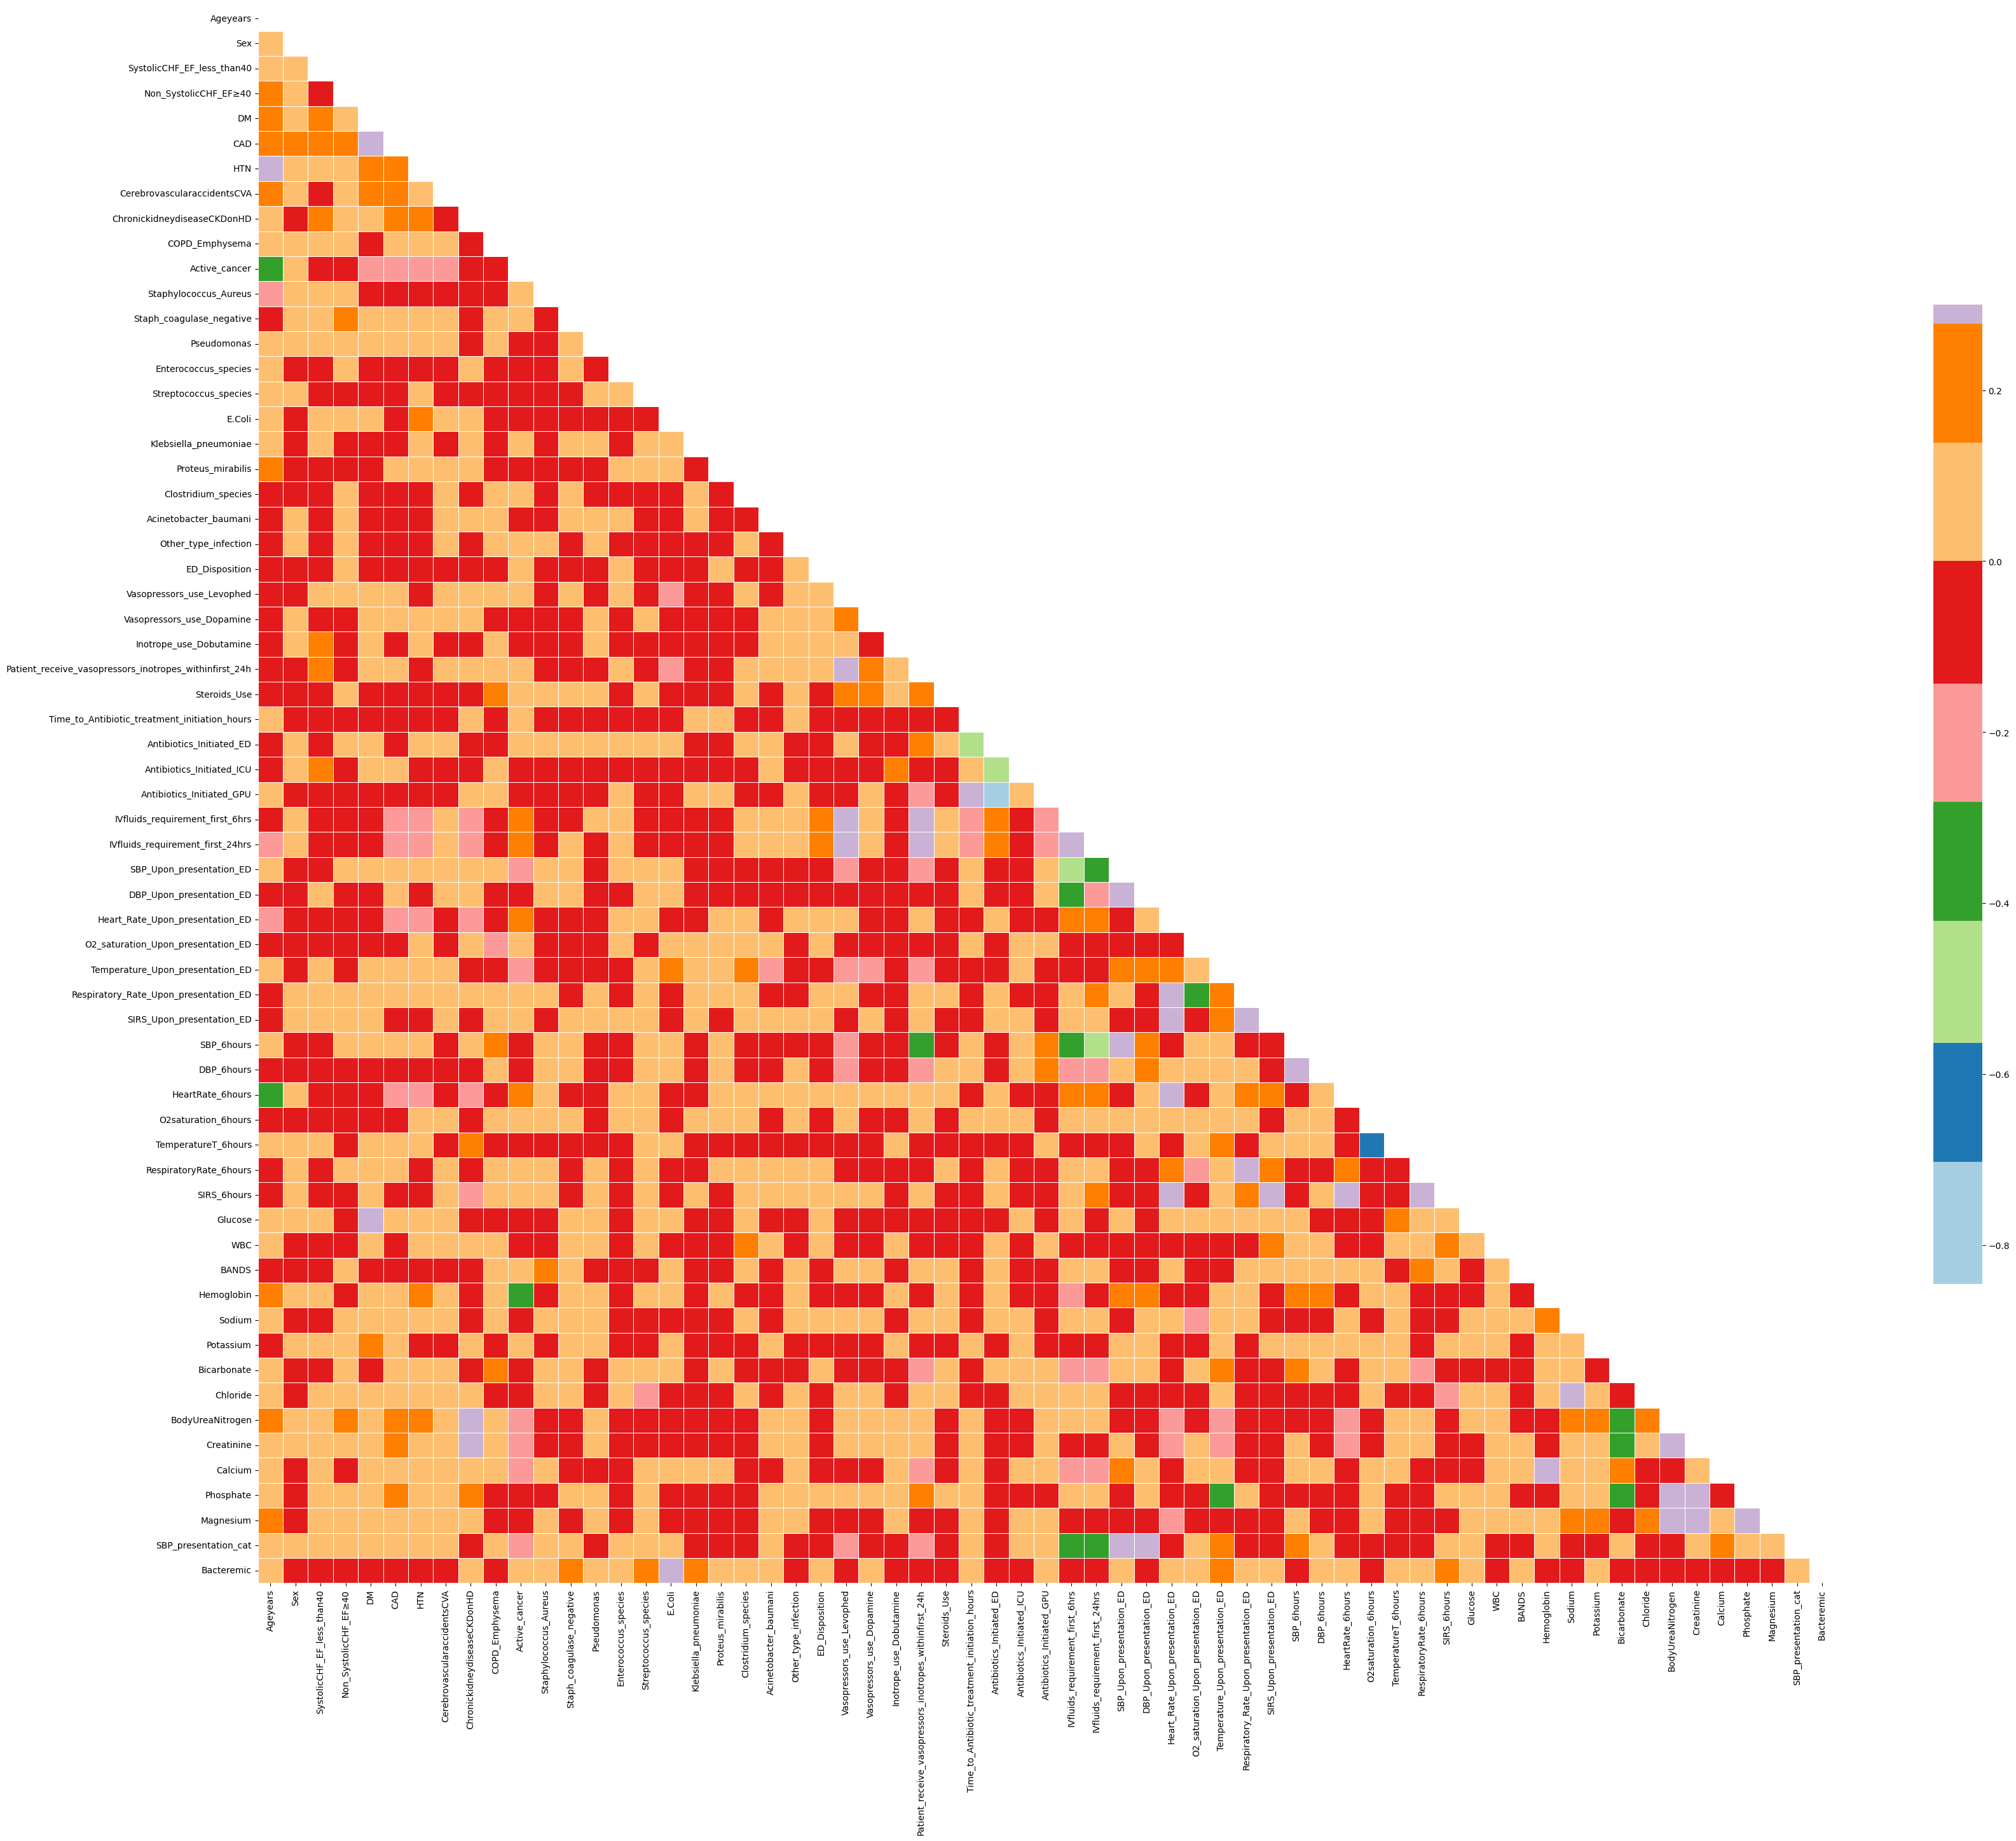

In [10]:
# correlation matrix to check if there is high correlation between the remaining features

corr_matrix(df_train_mod)

## Imputation

In [11]:
df_impute = df_train_mod.copy()
columns_impute = list(df_impute.columns)

In [12]:
# Now let's check the remaining proportion of missing values

null_values = df_impute.isnull().mean()*100
null_values = null_values.sort_values(ascending=False)
null_col = null_values[null_values >= 25].index.tolist()
print(columns_drop)

['gram_neg_bacilli_blood', 'gram_neg_bacilli_urine', 'gram_neg_bacilli_wound', 'streptococcus_other', 'klebsiella_other', 'gram_neg_bacilli_sputum', 'Active_Cancer_type3', 'clostridium_species_urine', 'clostridium_species_wound', 'clostridium_sputum', 'Other_medical_history', 'Cancer_Remission_type2', 'Cortisol_level', 'enterococcus_wound', 'enterococcus_sputum', 'Active_Cancer_type2', 'proteus_mirabilis_wound', 'streptococcus_wound', 'streptococcus_urine', 'Antibiotic4', 'Cancer_Remission_type1', 'BMT', 'Name_other_type_infection', 'Troponin_cat', 'CKMB', 'Antibiotic3', 'Antibiotic1', 'Steroid_type', 'Troponin', 'Antibiotic2', 'Appropriate_antibiotics', 'BilirubinTotal', 'Time_to_vasopressors_inotropes_withinfirst_24hours', 'Vasopressors_inotropes_Treatment_Duration_withinfirst_24hours', 'EF_non_EF_control', 'prevotella', 'Active_Cancer_type1_cat', 'gram_neg_bacilli', 'Streptococcus_species_name', 'Tumors_type', 'propionibacterium', 'Hospital_LOS_days_onlysurvived_multivariate', 'Loca

In [13]:
# dropping all the columns with null values more than 25%, SBP and DBP for redundancy, patient_id

df_impute = df_impute.drop(columns=null_col)
df_impute.columns

Index(['Ageyears', 'Sex', 'SystolicCHF_EF_less_than40',
       'Non_SystolicCHF_EF≥40', 'DM', 'CAD', 'HTN',
       'CerebrovascularaccidentsCVA', 'ChronickidneydiseaseCKDonHD',
       'COPD_Emphysema', 'Active_cancer', 'Staphylococcus_Aureus',
       'Staph_coagulase_negative', 'Pseudomonas', 'Enterococcus_species',
       'Streptococcus_species', 'E.Coli', 'Klebsiella_pneumoniae',
       'Proteus_mirabilis', 'Clostridium_species', 'Acinetobacter_baumani',
       'Other_type_infection', 'ED_Disposition', 'Vasopressors_use_Levophed',
       'Vasopressors_use_Dopamine', 'Inotrope_use_Dobutamine',
       'Patient_receive_vasopressors_inotropes_withinfirst_24h',
       'Steroids_Use', 'Time_to_Antibiotic_treatment_initiation_hours',
       'Antibiotics_Initiated_ED', 'Antibiotics_Initiated_ICU',
       'Antibiotics_Initiated_GPU', 'IVfluids_requirement_first_6hrs',
       'IVfluids_requirement_first_24hrs', 'SBP_Upon_presentation_ED',
       'DBP_Upon_presentation_ED', 'Heart_Rate_Upon_pre

In [14]:
# onehot encoding the gender

one_hot = pd.get_dummies(df_impute['Sex'])
df_impute = df_impute.join(one_hot)
df_impute = df_impute.drop('Sex', axis=1)

In [15]:
df_impute

,Ageyears,SystolicCHF_EF_less_than40,Non_SystolicCHF_EF≥40,DM,CAD,HTN,CerebrovascularaccidentsCVA,ChronickidneydiseaseCKDonHD,COPD_Emphysema,Active_cancer,...,Chloride,BodyUreaNitrogen,Creatinine,Calcium,Phosphate,Magnesium,SBP_presentation_cat,Bacteremic,0,1
0,75.0,1,0,0,1,1,0,0,0,0,...,103,42.0,1.9,8.0,2.8,2.3,1,0,False,True
1,75.0,0,1,1,1,1,0,0,0,0,...,89,44.0,1.6,9.2,2.2,1.4,1,1,False,True
2,55.0,0,0,1,1,0,0,1,0,0,...,99,69.0,12.0,9.4,11.3,2.7,0,0,True,False
3,75.0,0,0,1,0,1,0,0,1,0,...,89,30.0,0.7,9.4,2.2,1.6,1,0,False,True
4,85.0,0,1,0,0,1,0,0,0,0,...,95,50.0,2.1,8.3,3.5,1.9,0,1,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,55.0,0,1,0,0,0,0,0,0,1,...,107,22.0,1.1,8.3,2.9,1.6,1,1,True,False
348,55.0,0,1,0,0,0,0,0,0,1,...,95,38.0,1.8,7.1,3.6,1.2,0,1,False,True
349,65.0,0,1,0,0,0,0,0,0,1,...,105,23.0,1.1,6.0,0.6,1.2,1,1,False,True
350,65.0,0,0,1,0,1,0,0,0,1,...,101,25.0,0.9,6.5,3.2,1.0,0,1,True,False


## Gaussian Transformation and Standard Normalization

In [16]:
# function to draw histogram and QQ plot 

def diagnostic_plots(df, variable):
    fig = plt.figure(figsize=(15,4))
    ax = fig.add_subplot(121)
    df[variable].hist(bins=30)
    ax = fig.add_subplot(122)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.xlabel(variable)
    plt.show()

In [17]:
# function to apply different transformations to make the plot gaussian

def try_gaussian(df, col):
    # 1. Pastikan kita hanya bekerja dengan data yang valid (bukan NaN/Inf)
    # Kita buat copy untuk mencegah masalah SettingWithCopy
    data_valid = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    
    if data_valid.empty:
        print(f"Skipping {col}: Tidak ada data valid.")
        return

    print(f'--- Actual Plot: {col} ---')
    diagnostic_plots(df, col)
    
    # 2. Yeo-Johnson: Gunakan data_valid, bukan df[col]
    # Simpan hasil dalam list/series yang indeksnya sesuai
    transformed_yj, param = stats.yeojohnson(data_valid)
    df_temp = df.copy() # Gunakan df sementara untuk plot
    df_temp.loc[data_valid.index, 'col_yj'] = transformed_yj
    print('yeojohnson plot')
    diagnostic_plots(df_temp, 'col_yj')
    
    # 3. Transformasi lain: Gunakan data_valid agar tidak error
    # Eksponensial (.5 dan 1/1.5)
    df_temp.loc[data_valid.index, 'col_1.5'] = data_valid**(1/1.5)
    print('**1/1.5 plot')
    diagnostic_plots(df_temp, 'col_1.5')

    df_temp.loc[data_valid.index, 'col_sq'] = data_valid**(0.5)
    print('**.5 plot')
    diagnostic_plots(df_temp, 'col_sq')
    
    # Invers (Resiprokal)
    df_temp.loc[data_valid.index, 'col_rec'] = 1 / (data_valid + 0.00001)
    print('reciprocal plot')
    diagnostic_plots(df_temp, 'col_rec')

    # Log: np.log1p (log(x+1)) adalah cara stabil menangani angka kecil
    df_temp.loc[data_valid.index, 'col_log'] = np.log1p(data_valid)
    print('log plot')
    diagnostic_plots(df_temp, 'col_log')

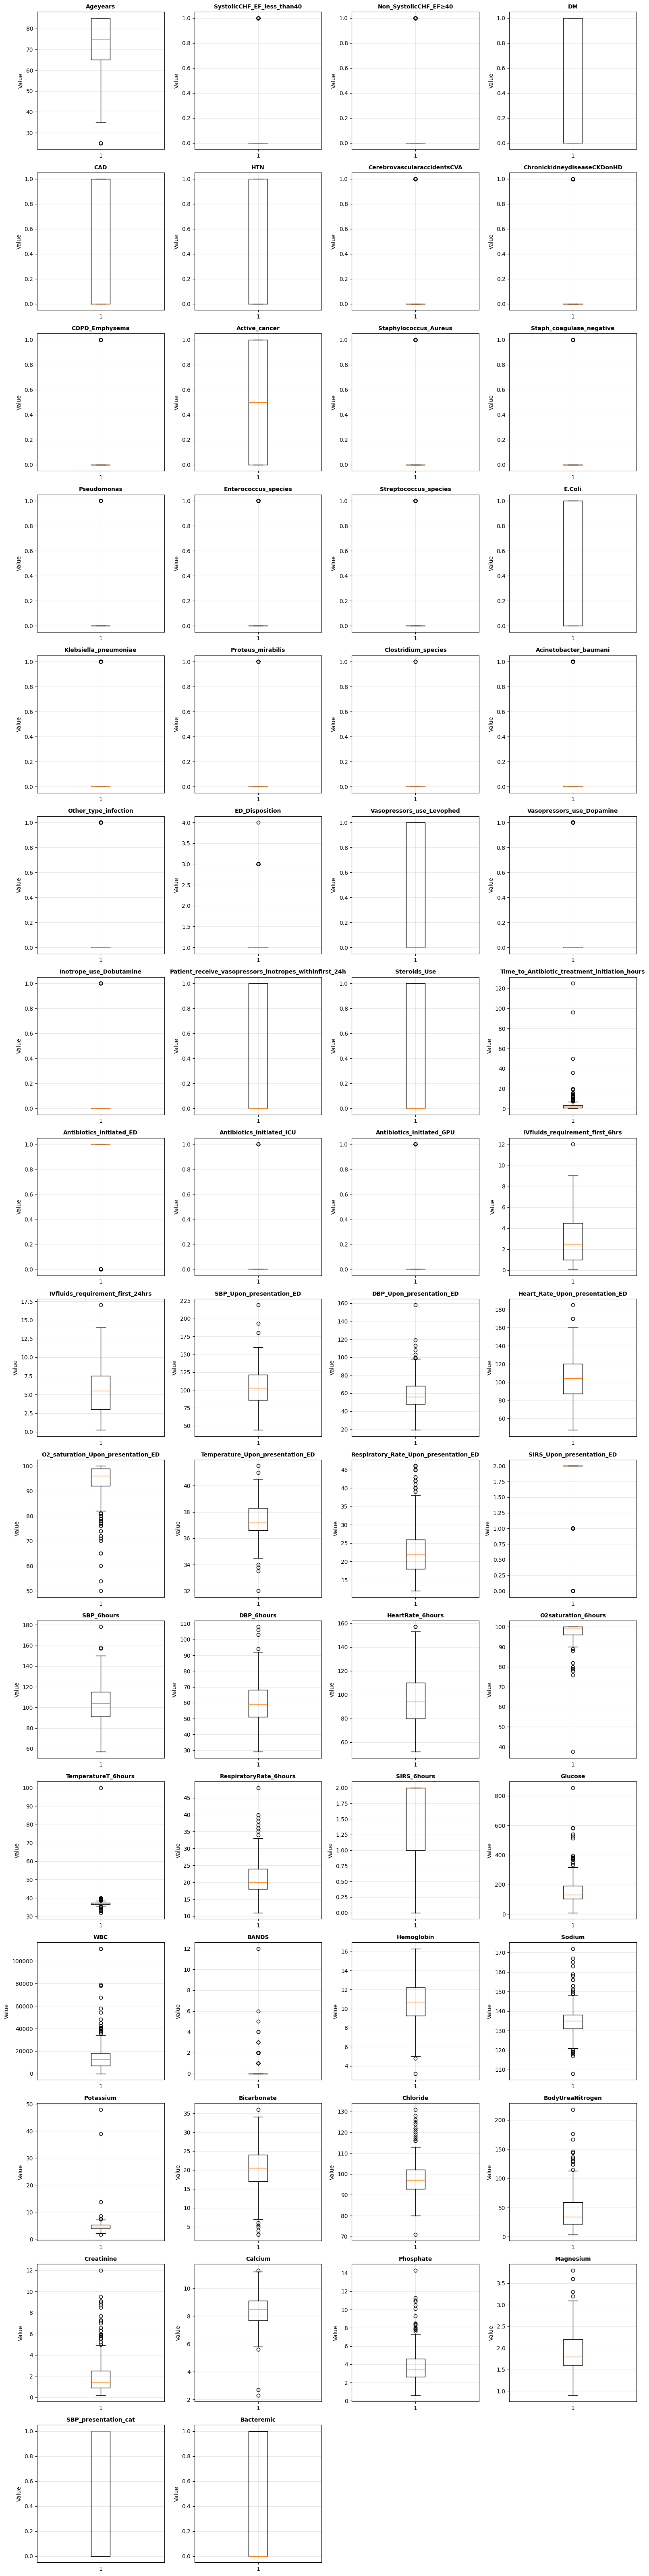

=== STATISTIK DESKRIPTIF df_impute sebelum normalisasi ===

         Ageyears  SystolicCHF_EF_less_than40  Non_SystolicCHF_EF≥40  \
count  333.000000                  352.000000             352.000000   
mean    69.324324                    0.167614               0.241477   
std     14.350703                    0.374055               0.428588   
min     25.000000                    0.000000               0.000000   
25%     65.000000                    0.000000               0.000000   
50%     75.000000                    0.000000               0.000000   
75%     85.000000                    0.000000               0.000000   
max     85.000000                    1.000000               1.000000   

               DM         CAD         HTN  CerebrovascularaccidentsCVA  \
count  352.000000  352.000000  352.000000                   352.000000   
mean     0.372159    0.338068    0.622159                     0.127841   
std      0.484069    0.473725    0.485538                     0.33438

In [18]:
# Cherry Picking Feature for Gaussian by the boxplot results

numeric_cols = df_impute.select_dtypes(include=[np.number]).columns

# Calculate grid size needed
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4  # Ceiling division to get needed rows for 4 columns

fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4*n_rows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    # Box plot untuk deteksi outlier
    axes[idx].boxplot(df_impute[col].dropna(), vert=True)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

# Sembunyikan subplot yang tidak digunakan
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Tampilkan statistik deskriptif untuk identifikasi outlier
print("=== STATISTIK DESKRIPTIF df_impute sebelum normalisasi ===\n")
print(df_impute.describe())

Glucose
--- Actual Plot: Glucose ---


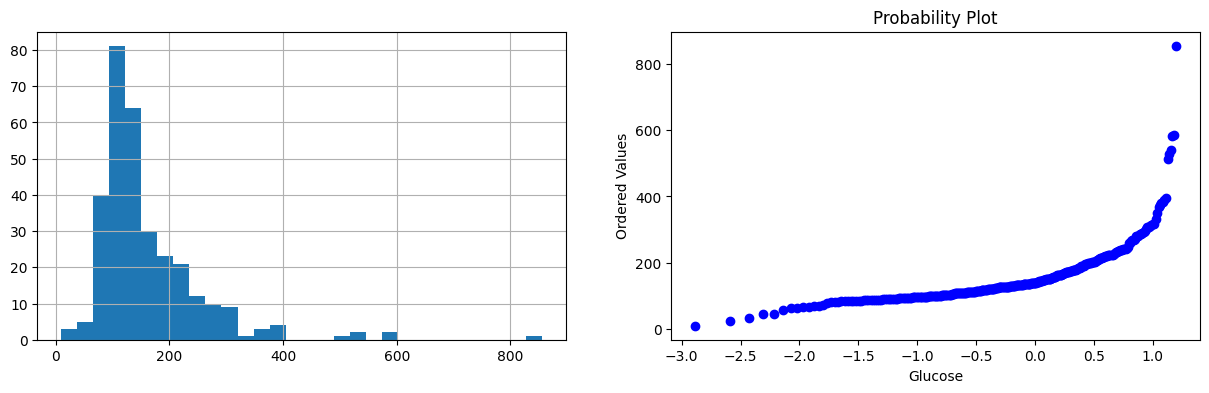

yeojohnson plot


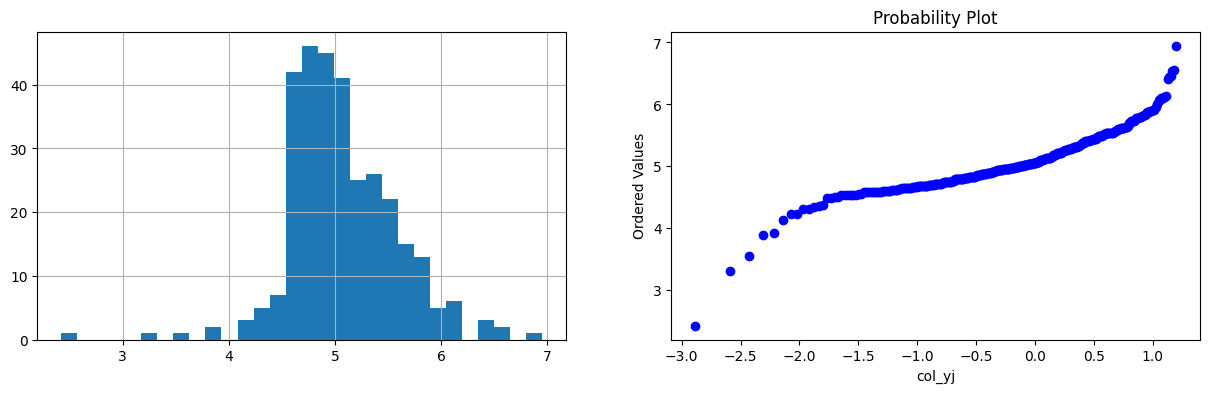

**1/1.5 plot


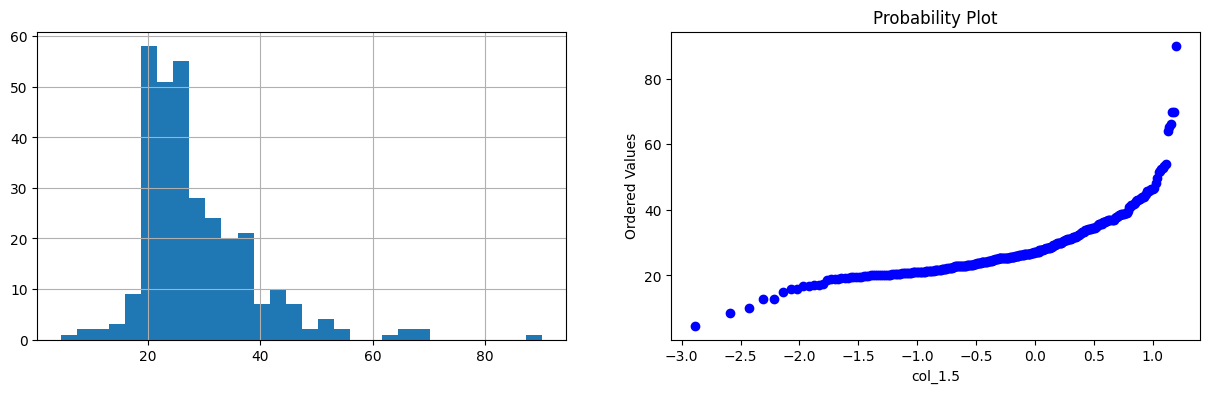

**.5 plot


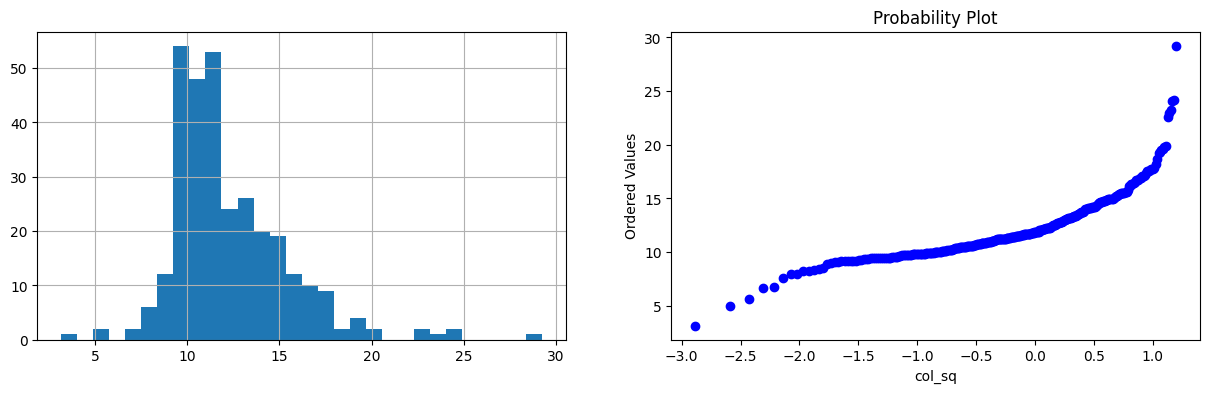

reciprocal plot


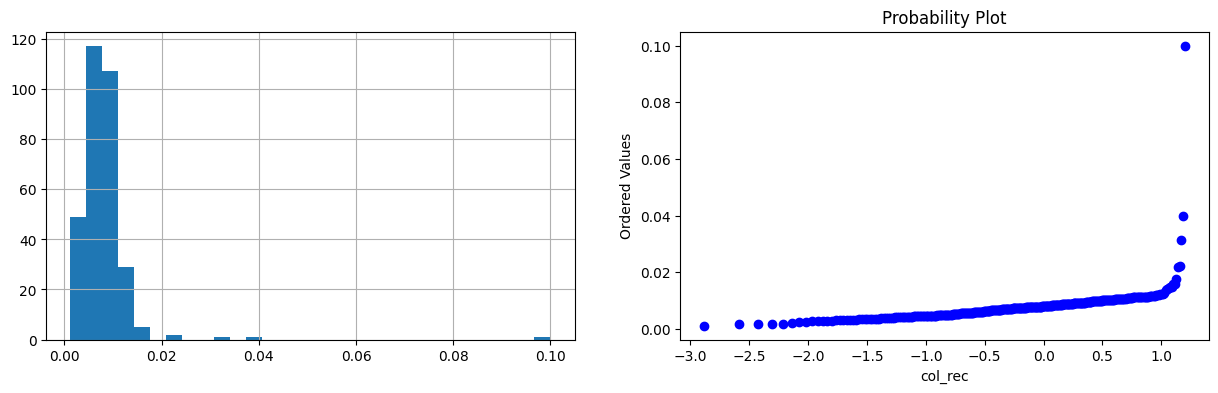

log plot


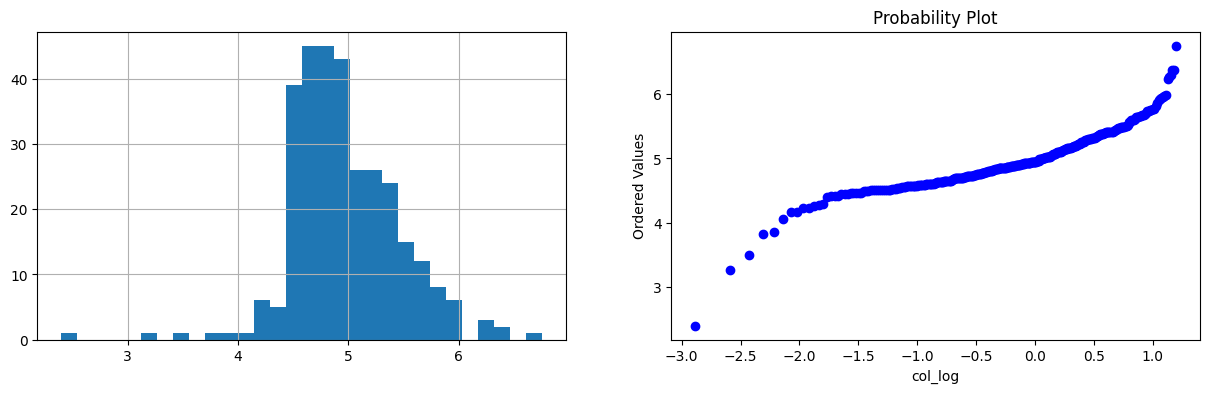

Creatinine
--- Actual Plot: Creatinine ---


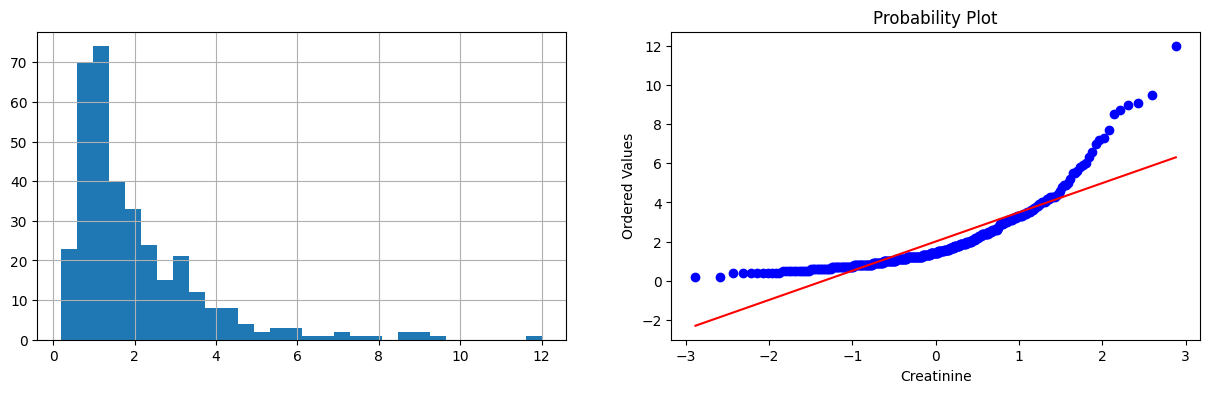

yeojohnson plot


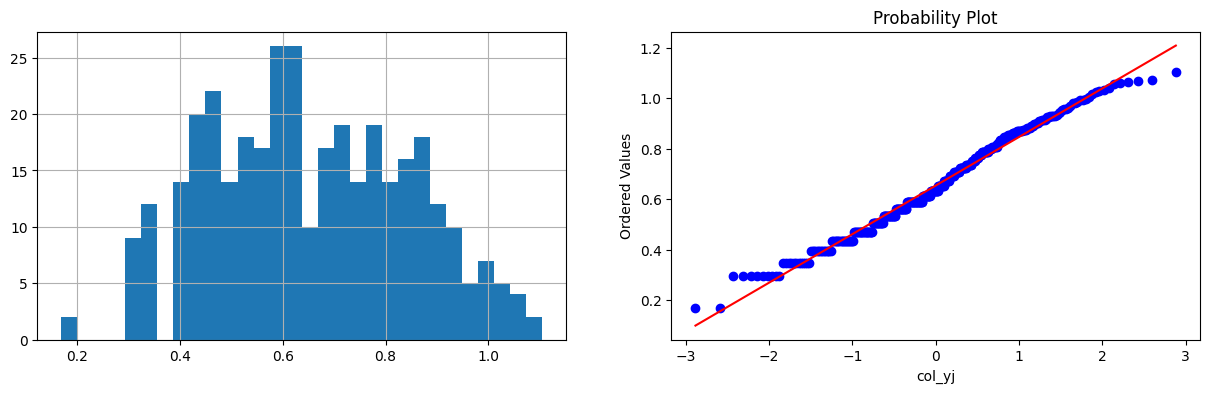

**1/1.5 plot


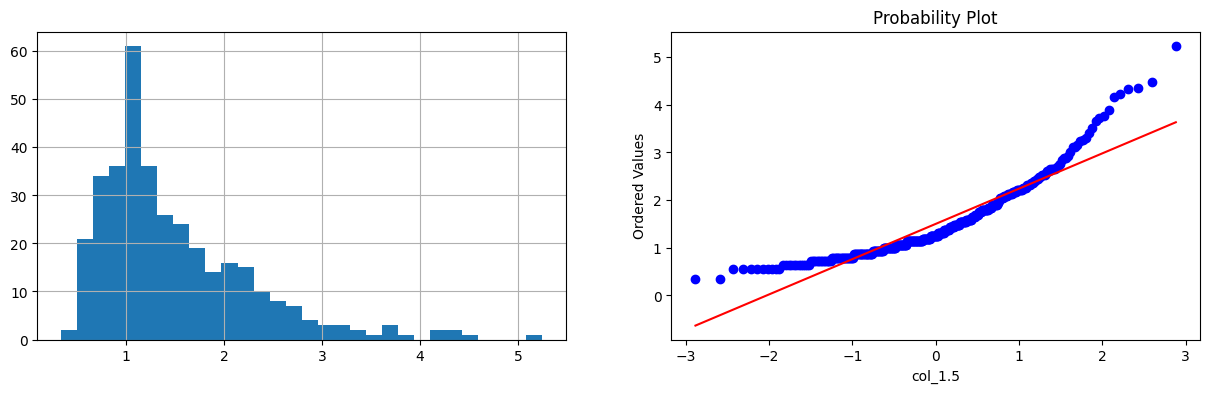

**.5 plot


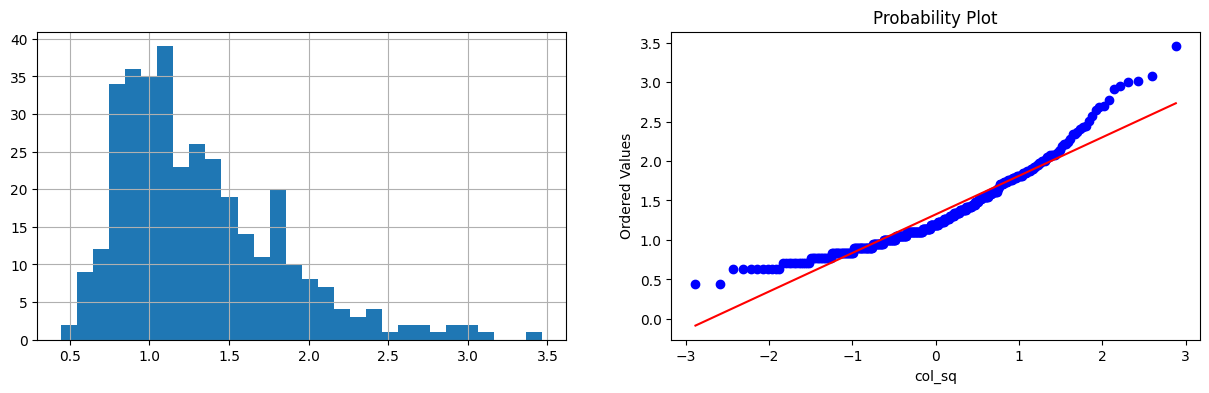

reciprocal plot


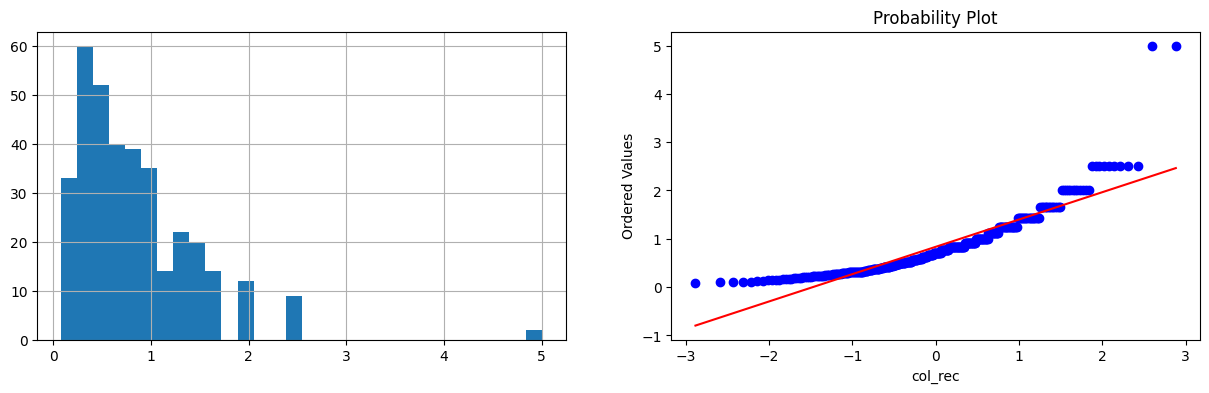

log plot


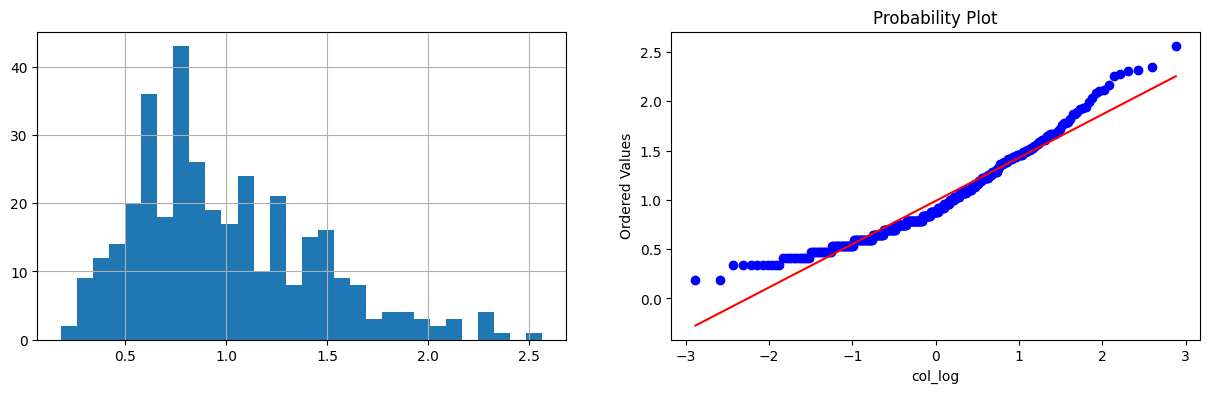

WBC
--- Actual Plot: WBC ---


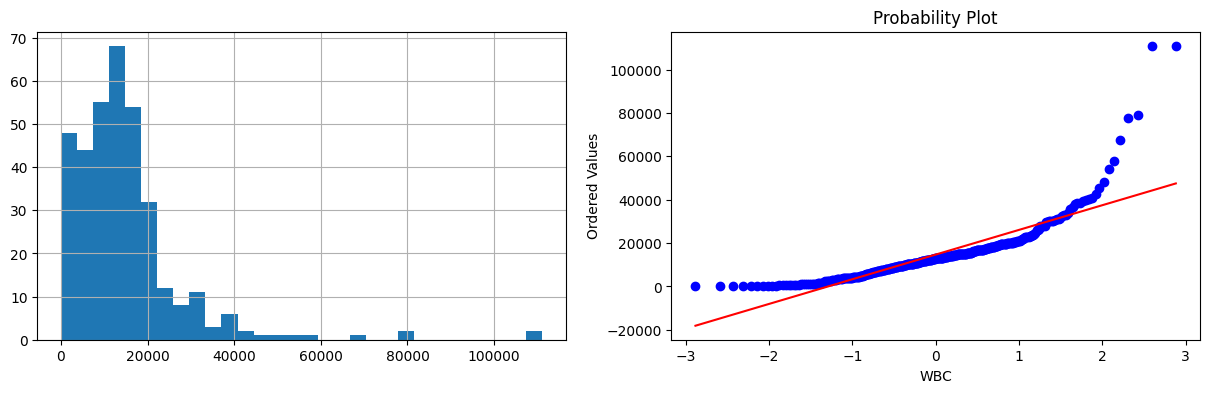

yeojohnson plot


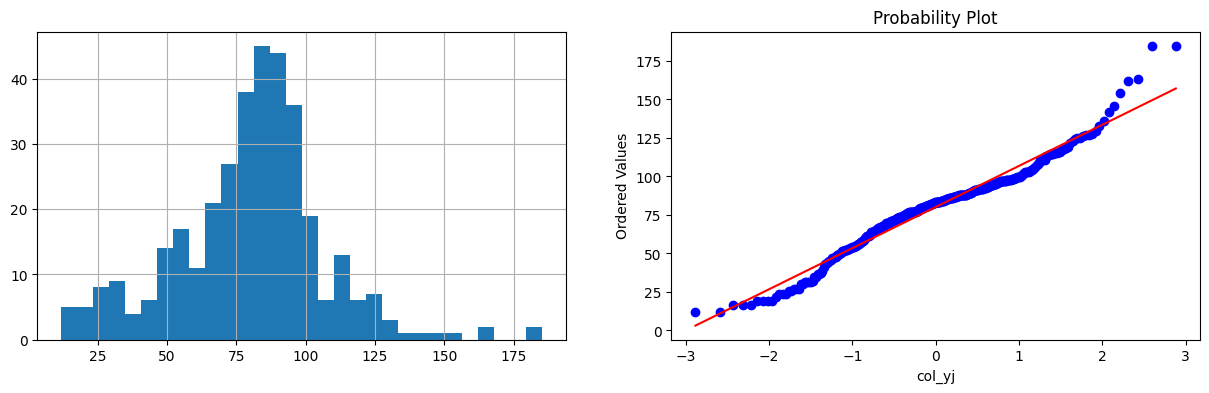

**1/1.5 plot


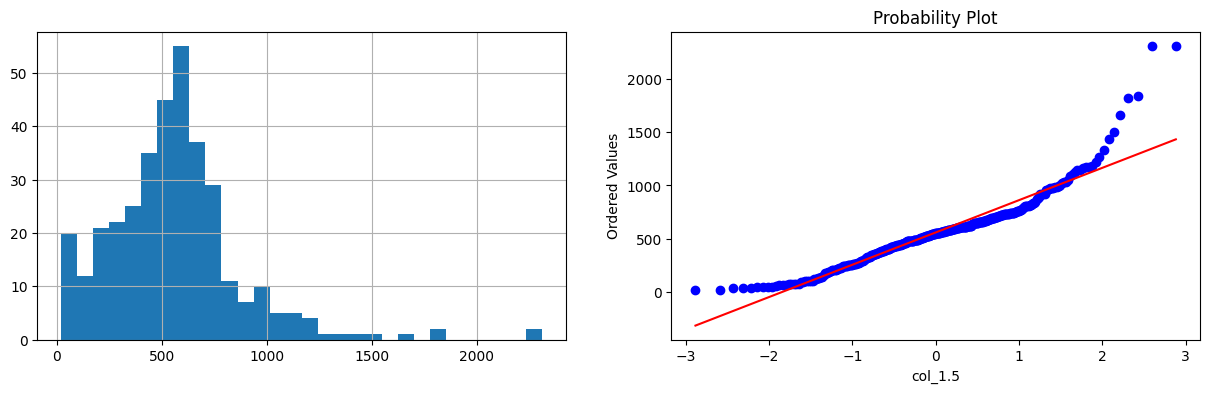

**.5 plot


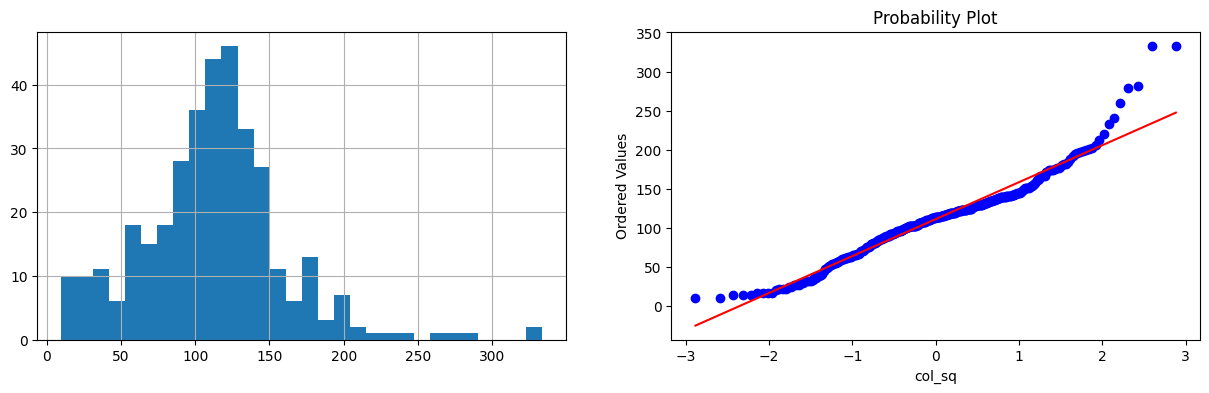

reciprocal plot


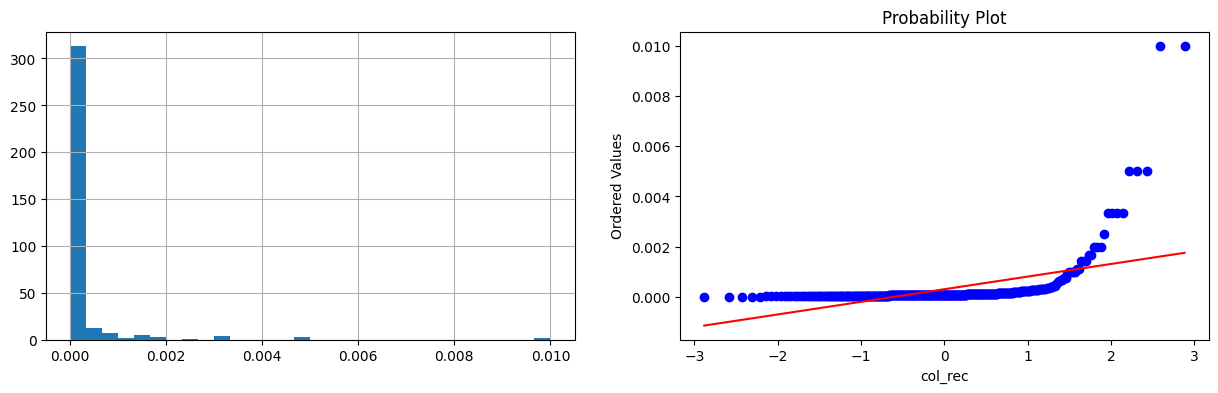

log plot


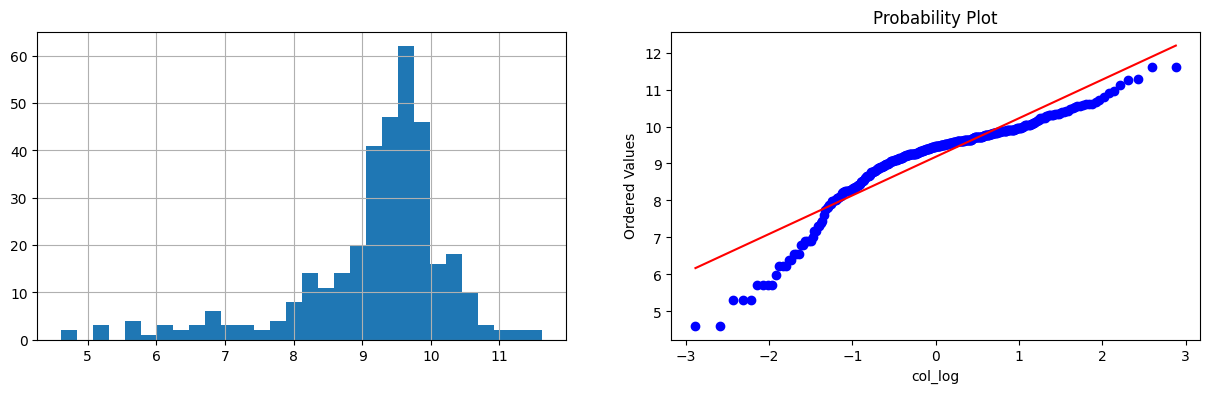

Time_to_Antibiotic_treatment_initiation_hours
--- Actual Plot: Time_to_Antibiotic_treatment_initiation_hours ---


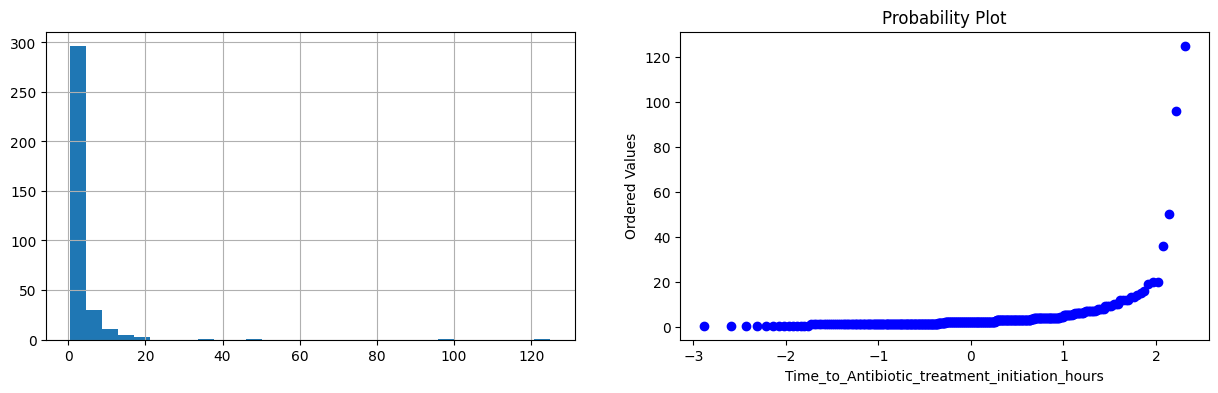

yeojohnson plot


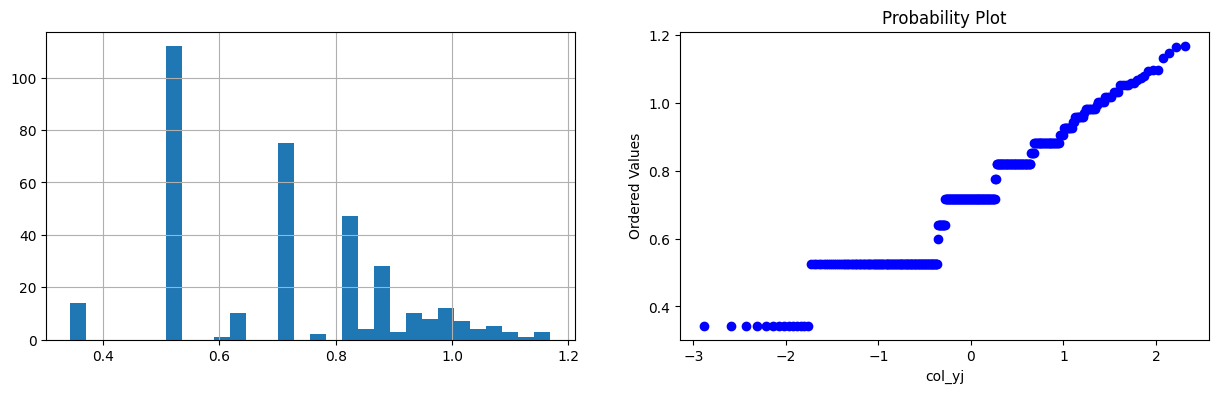

**1/1.5 plot


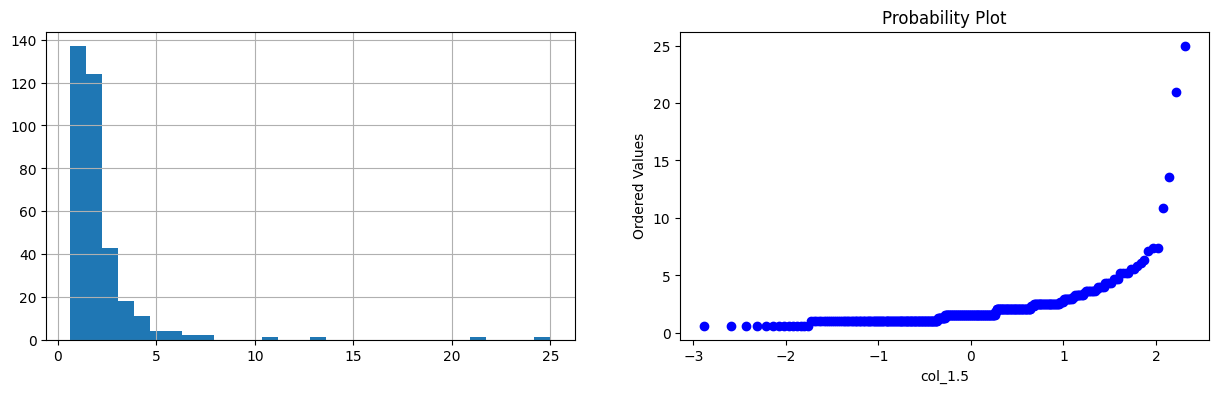

**.5 plot


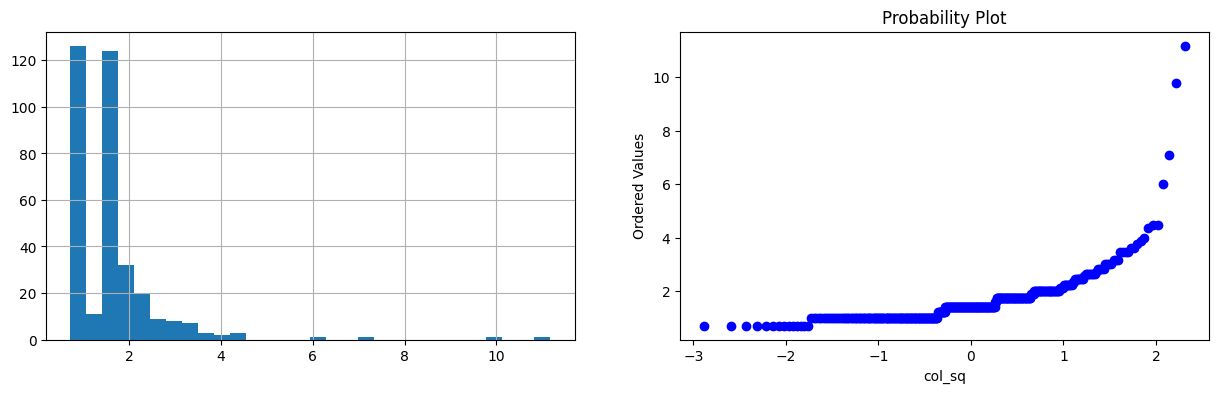

reciprocal plot


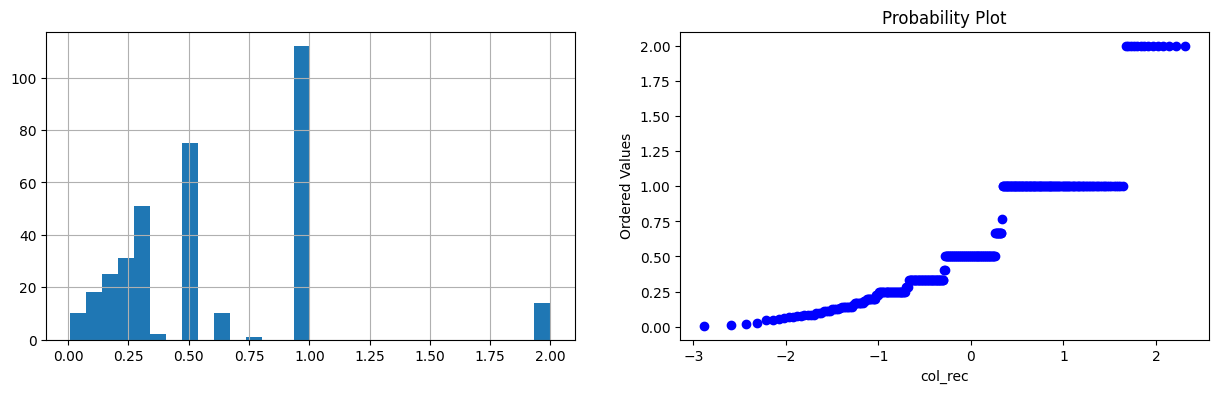

log plot


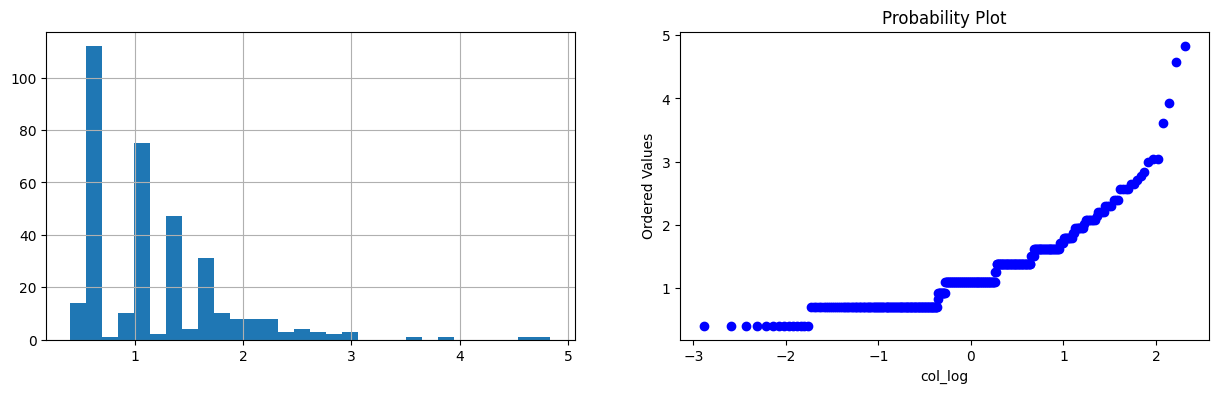

O2_saturation_Upon_presentation_ED
--- Actual Plot: O2_saturation_Upon_presentation_ED ---


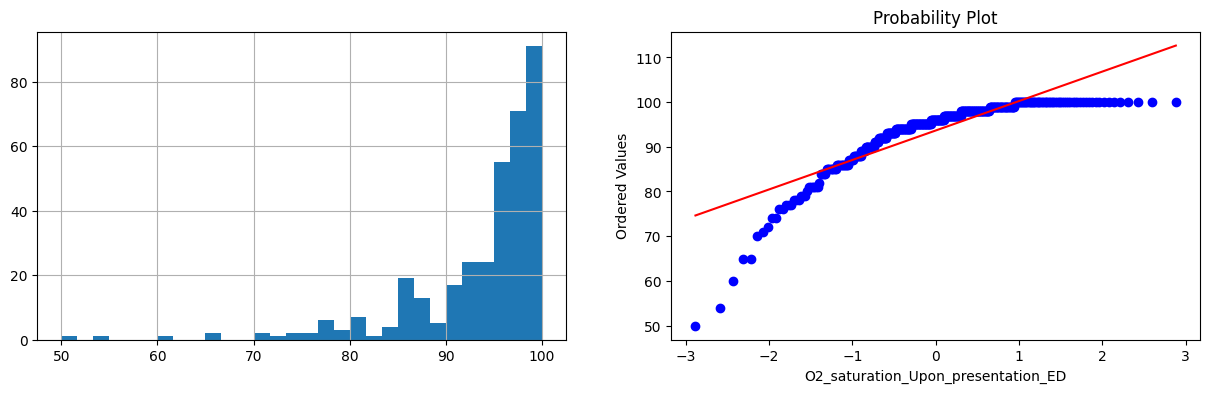

yeojohnson plot


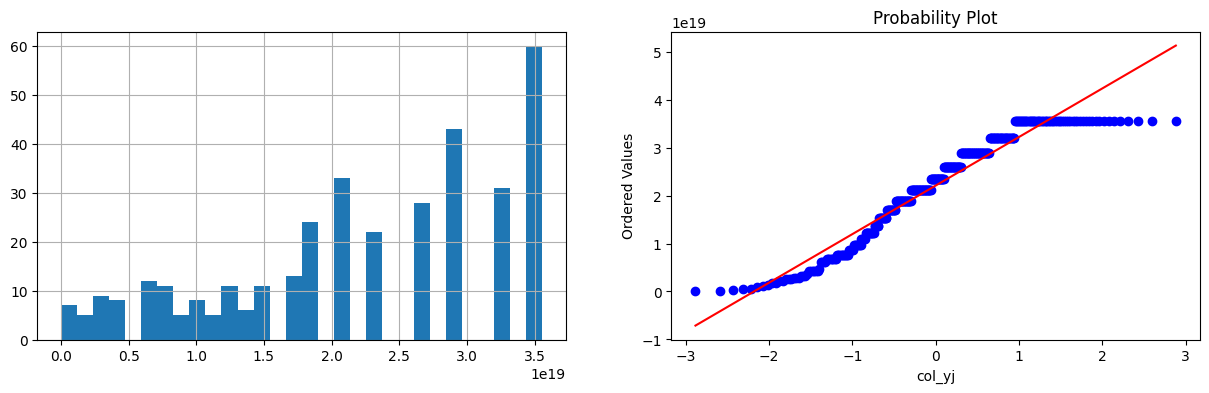

**1/1.5 plot


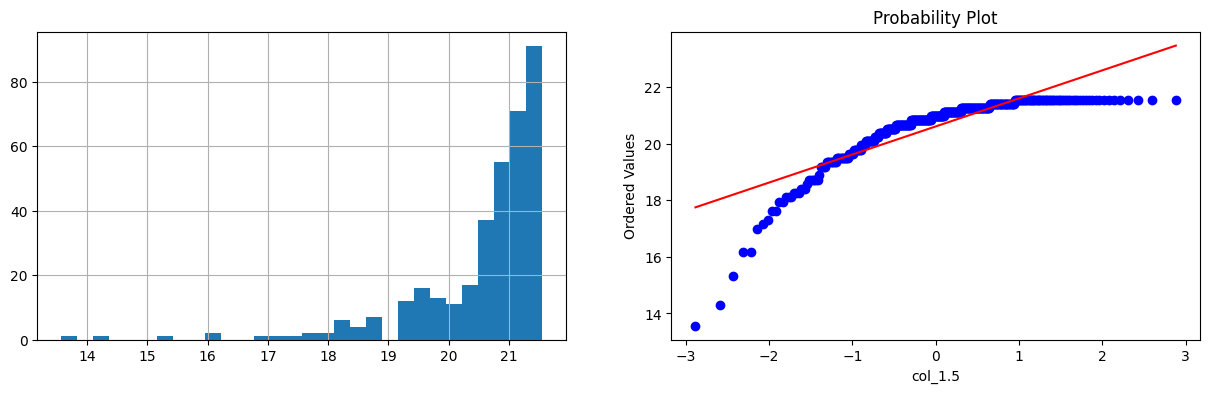

**.5 plot


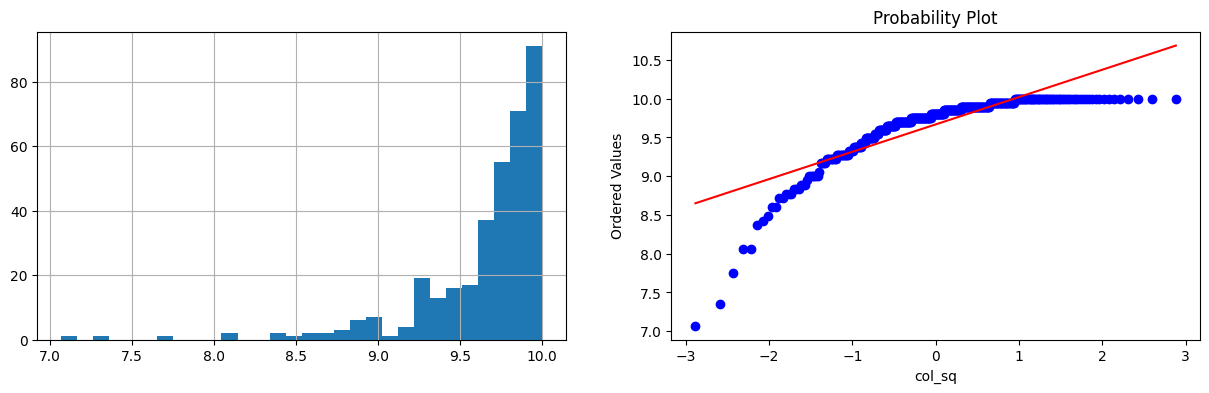

reciprocal plot


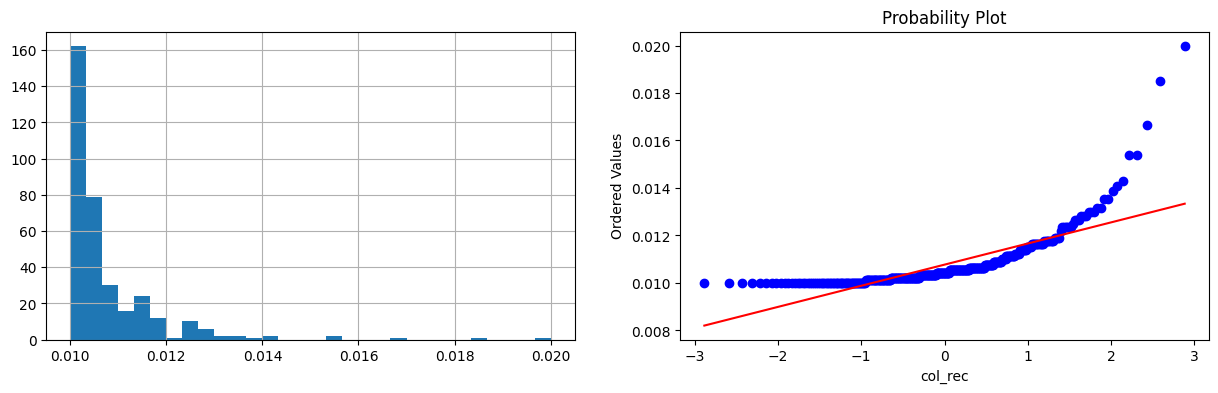

log plot


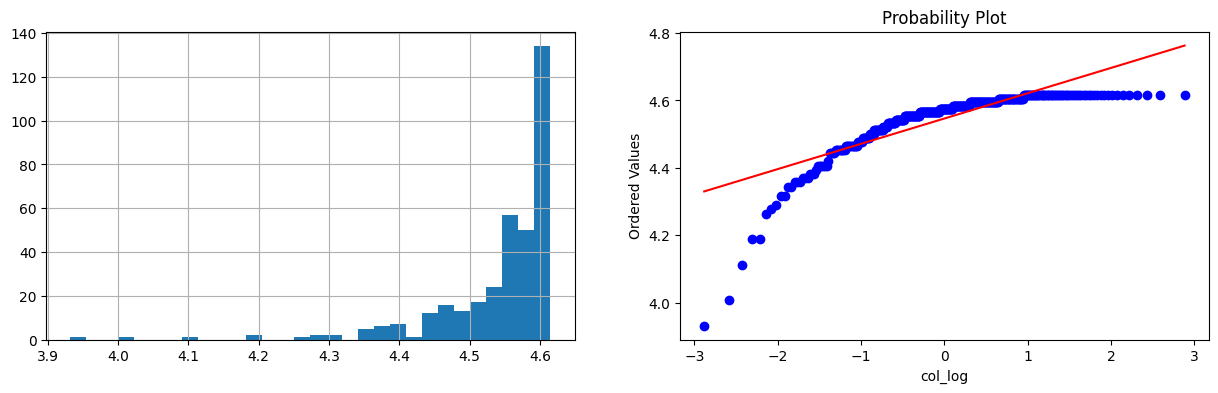

TemperatureT_6hours
--- Actual Plot: TemperatureT_6hours ---


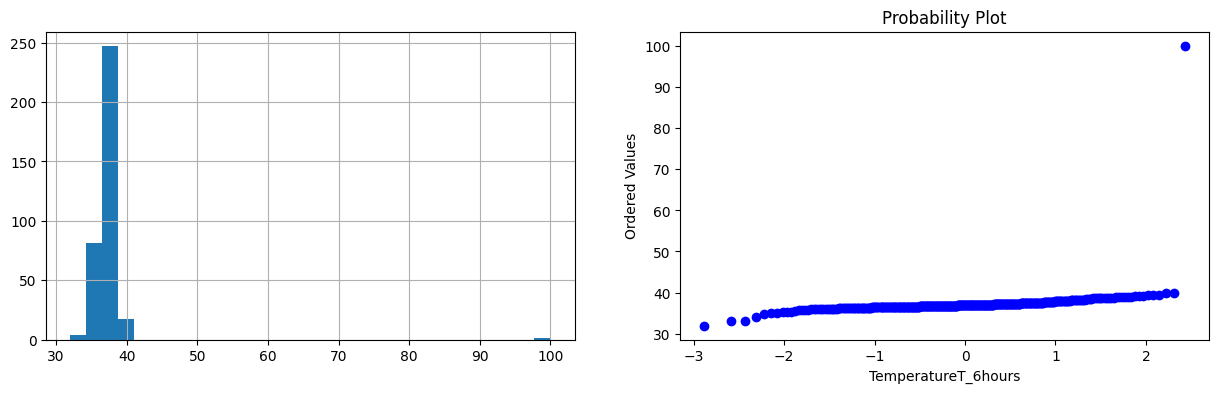

yeojohnson plot


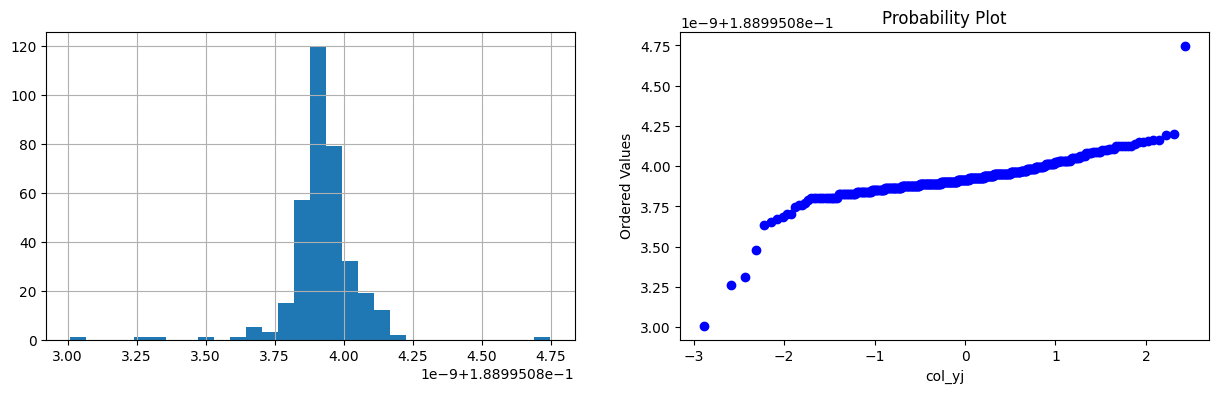

**1/1.5 plot


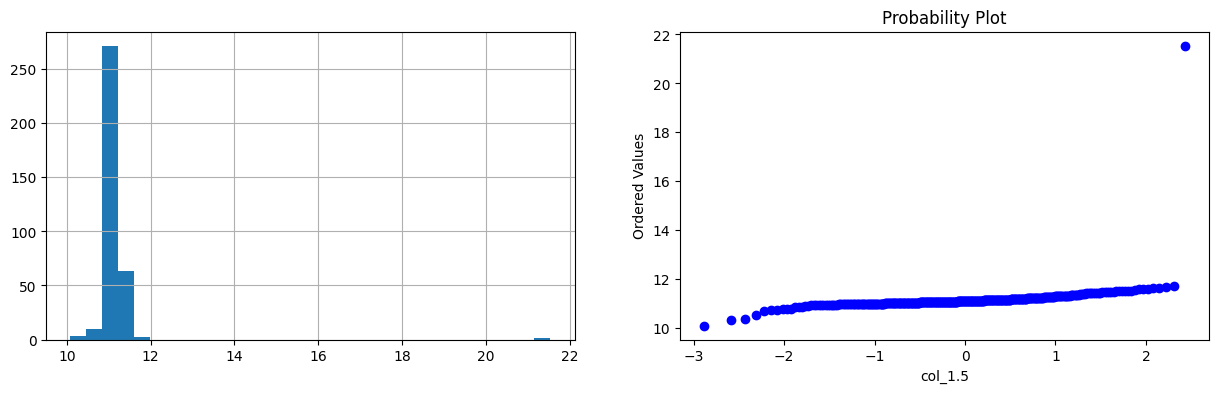

**.5 plot


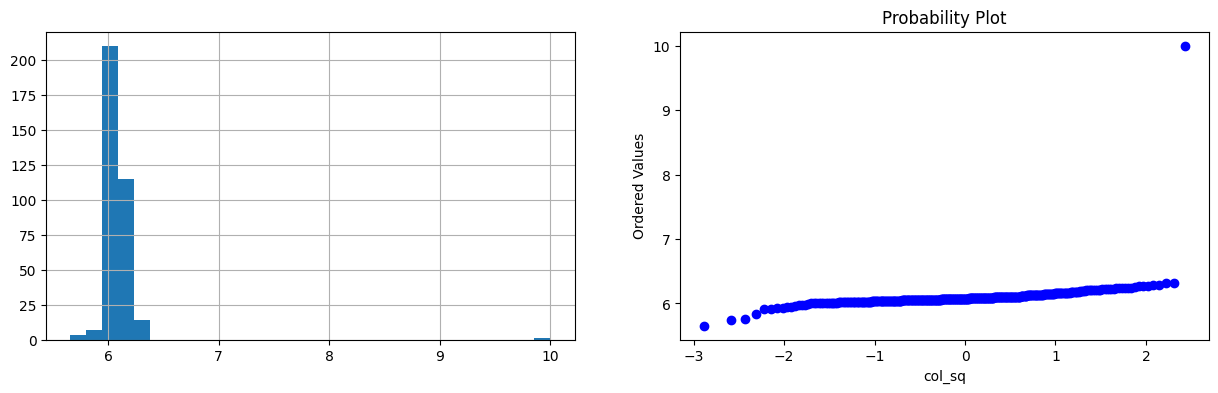

reciprocal plot


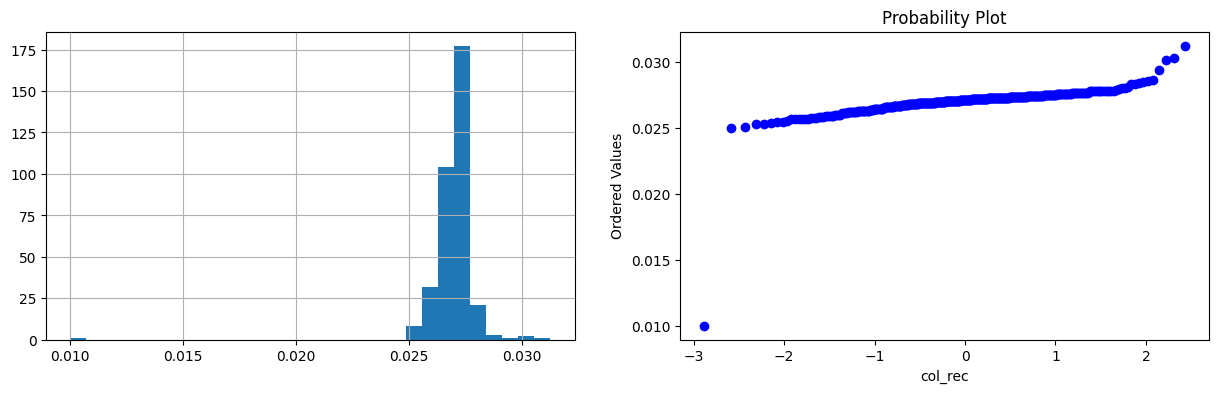

log plot


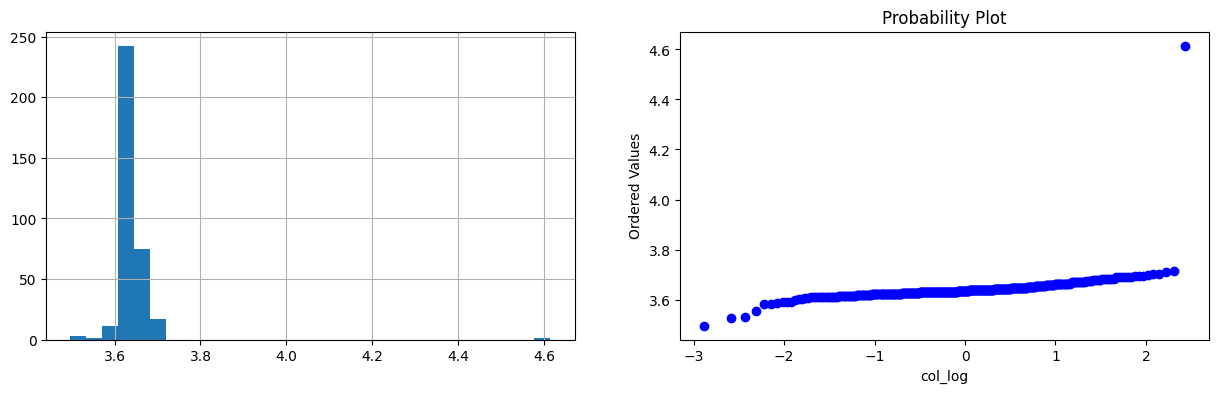

BodyUreaNitrogen
--- Actual Plot: BodyUreaNitrogen ---


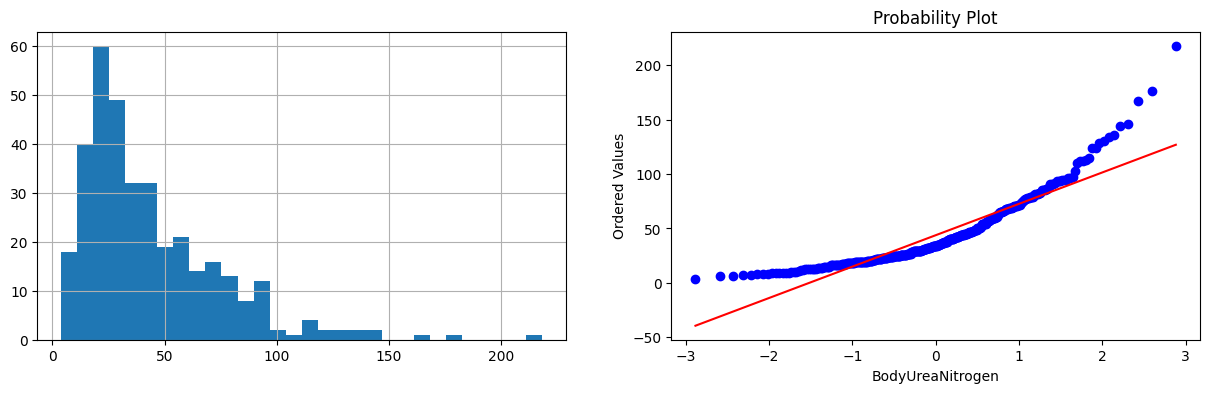

yeojohnson plot


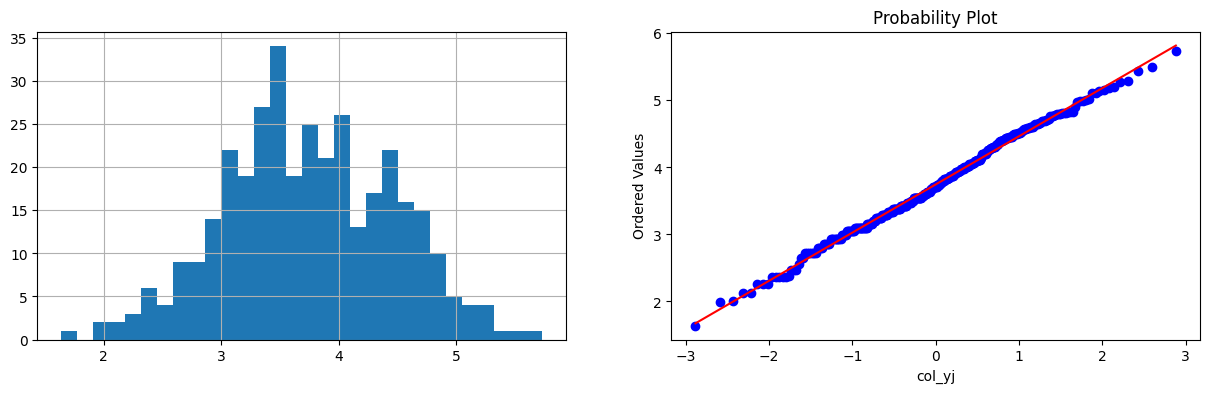

**1/1.5 plot


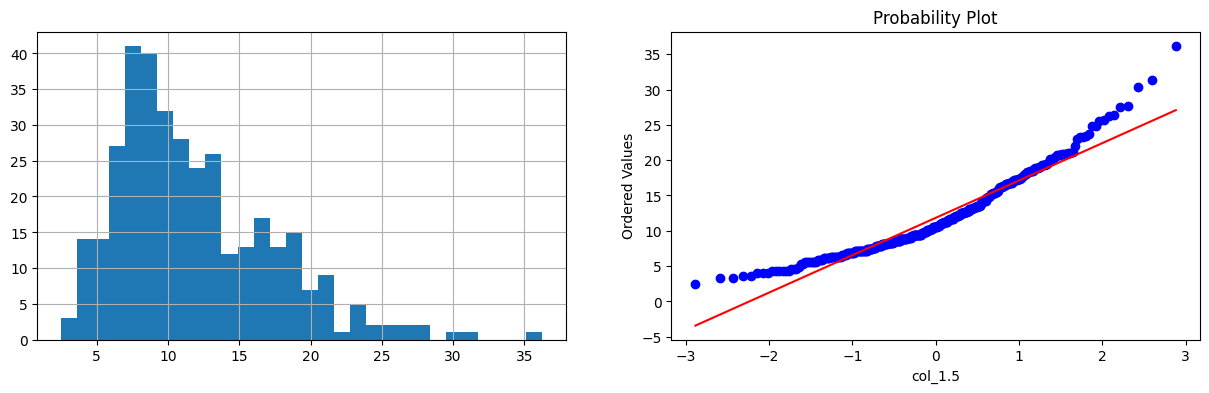

**.5 plot


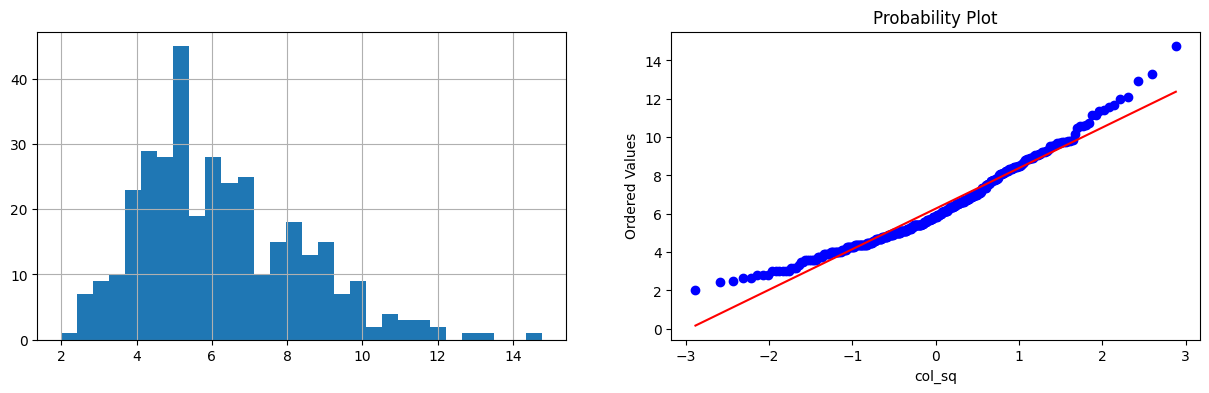

reciprocal plot


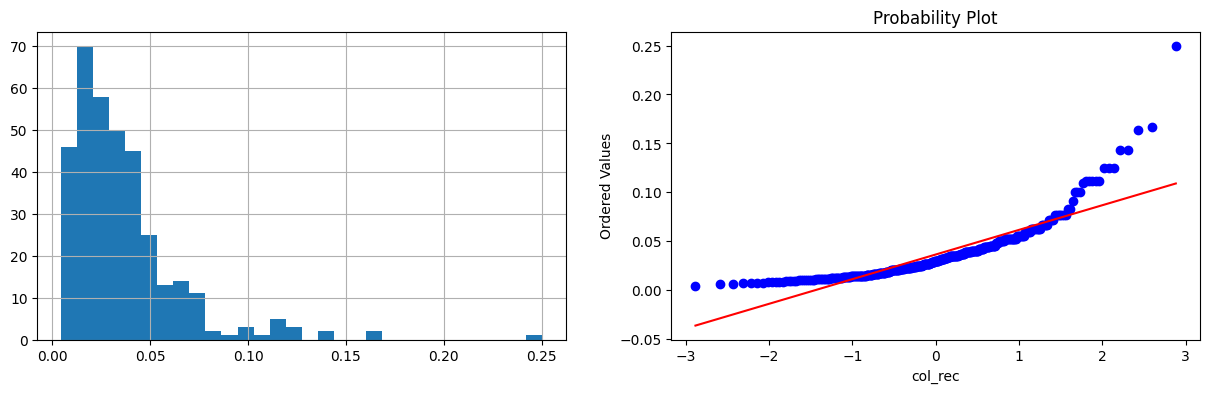

log plot


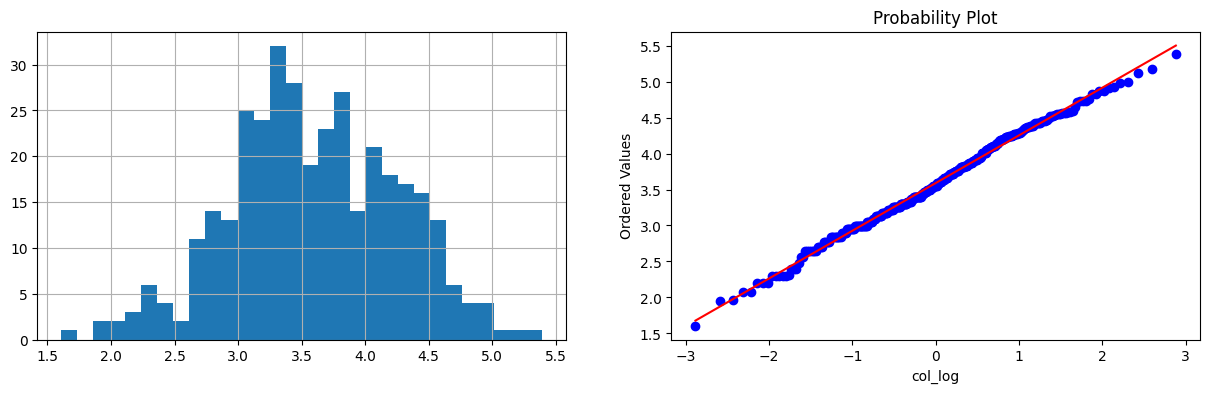

In [19]:
# Now we try to check the distribution of values present in different columns after application of various transformations

lst = ['Glucose', 'Creatinine', 'WBC', 'Time_to_Antibiotic_treatment_initiation_hours', 'O2_saturation_Upon_presentation_ED', 'TemperatureT_6hours', 'BodyUreaNitrogen']
for i in lst:
  print(i)
  try_gaussian(df_impute, i)

In [20]:
df_impute.head()

,Ageyears,SystolicCHF_EF_less_than40,Non_SystolicCHF_EF≥40,DM,CAD,HTN,CerebrovascularaccidentsCVA,ChronickidneydiseaseCKDonHD,COPD_Emphysema,Active_cancer,...,Chloride,BodyUreaNitrogen,Creatinine,Calcium,Phosphate,Magnesium,SBP_presentation_cat,Bacteremic,0,1
0,75.0,1,0,0,1,1,0,0,0,0,...,103,42.0,1.9,8.0,2.8,2.3,1,0,False,True
1,75.0,0,1,1,1,1,0,0,0,0,...,89,44.0,1.6,9.2,2.2,1.4,1,1,False,True
2,55.0,0,0,1,1,0,0,1,0,0,...,99,69.0,12.0,9.4,11.3,2.7,0,0,True,False
3,75.0,0,0,1,0,1,0,0,1,0,...,89,30.0,0.7,9.4,2.2,1.6,1,0,False,True
4,85.0,0,1,0,0,1,0,0,0,0,...,95,50.0,2.1,8.3,3.5,1.9,0,1,False,True


In [21]:
# Robust Scaler normalization

scaler = RobustScaler()
df_impute[['Glucose', 'Creatinine', 'WBC', 'Time_to_Antibiotic_treatment_initiation_hours', 'O2_saturation_Upon_presentation_ED', 'TemperatureT_6hours', 'BodyUreaNitrogen']] = scaler.fit_transform(df_impute[['Glucose', 'Creatinine', 'WBC', 'Time_to_Antibiotic_treatment_initiation_hours', 'O2_saturation_Upon_presentation_ED', 'TemperatureT_6hours', 'BodyUreaNitrogen']])
df_impute.head()

,Ageyears,SystolicCHF_EF_less_than40,Non_SystolicCHF_EF≥40,DM,CAD,HTN,CerebrovascularaccidentsCVA,ChronickidneydiseaseCKDonHD,COPD_Emphysema,Active_cancer,...,Chloride,BodyUreaNitrogen,Creatinine,Calcium,Phosphate,Magnesium,SBP_presentation_cat,Bacteremic,0,1
0,75.0,1,0,0,1,1,0,0,0,0,...,103,0.216216,0.307692,8.0,2.8,2.3,1,0,False,True
1,75.0,0,1,1,1,1,0,0,0,0,...,89,0.270270,0.123077,9.2,2.2,1.4,1,1,False,True
2,55.0,0,0,1,1,0,0,1,0,0,...,99,0.945946,6.523077,9.4,11.3,2.7,0,0,True,False
3,75.0,0,0,1,0,1,0,0,1,0,...,89,-0.108108,-0.430769,9.4,2.2,1.6,1,0,False,True
4,85.0,0,1,0,0,1,0,0,0,0,...,95,0.432432,0.430769,8.3,3.5,1.9,0,1,False,True


In [22]:
df_impute = df_impute.dropna()

In [23]:
null_values = df_impute.isnull().mean()*100
null_values

Ageyears                      0.0
SystolicCHF_EF_less_than40    0.0
Non_SystolicCHF_EF≥40         0.0
DM                            0.0
CAD                           0.0
                             ... 
Magnesium                     0.0
SBP_presentation_cat          0.0
Bacteremic                    0.0
0                             0.0
1                             0.0
Length: 64, dtype: float64

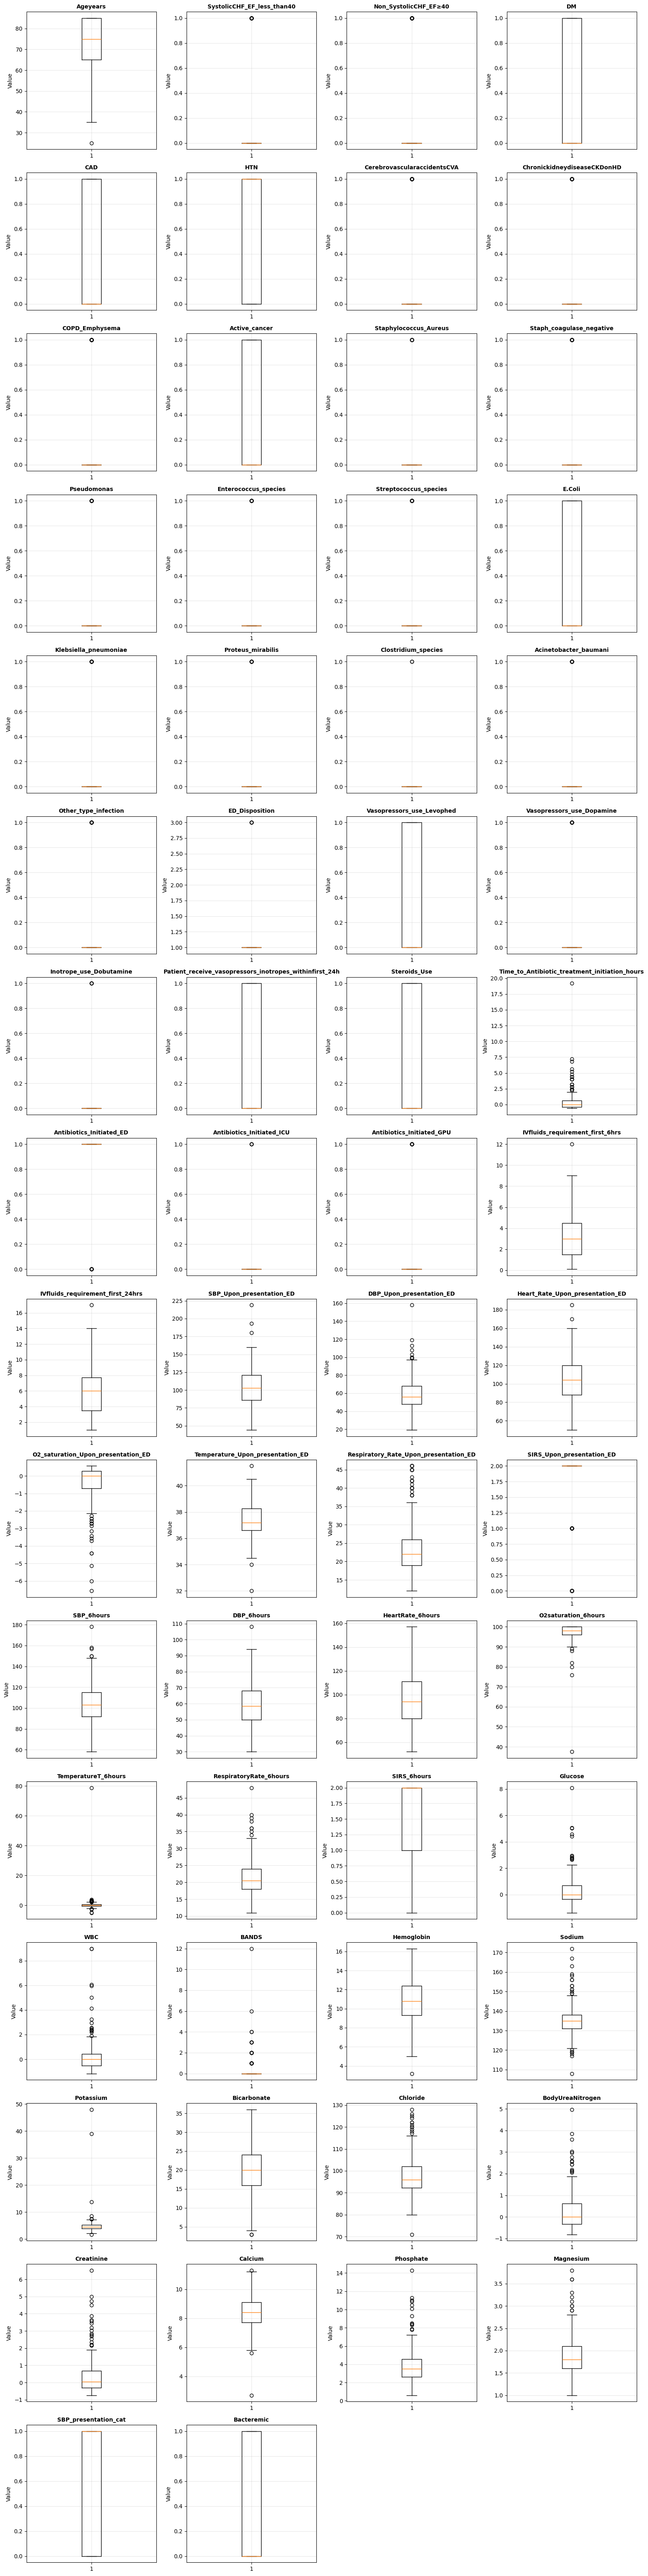

=== STATISTIK DESKRIPTIF df_impute setelah normalisasi ===

         Ageyears  SystolicCHF_EF_less_than40  Non_SystolicCHF_EF≥40  \
count  282.000000                  282.000000             282.000000   
mean    70.319149                    0.163121               0.248227   
std     13.474805                    0.370132               0.432752   
min     25.000000                    0.000000               0.000000   
25%     65.000000                    0.000000               0.000000   
50%     75.000000                    0.000000               0.000000   
75%     85.000000                    0.000000               0.000000   
max     85.000000                    1.000000               1.000000   

              DM         CAD         HTN  CerebrovascularaccidentsCVA  \
count  282.00000  282.000000  282.000000                   282.000000   
mean     0.41844    0.333333    0.641844                     0.134752   
std      0.49418    0.472243    0.480311                     0.342065   

In [24]:
# Ambil kolom numerik (exclude Gender dan SepsisLabel)
numeric_cols = df_impute.select_dtypes(include=[np.number]).columns

# Calculate grid size needed
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4  # Ceiling division to get needed rows for 4 columns

fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4*n_rows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    # Box plot untuk deteksi outlier
    axes[idx].boxplot(df_impute[col].dropna(), vert=True)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

# Sembunyikan subplot yang tidak digunakan
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Tampilkan statistik deskriptif untuk identifikasi outlier
print("=== STATISTIK DESKRIPTIF df_impute setelah normalisasi ===\n")
print(df_impute.describe())

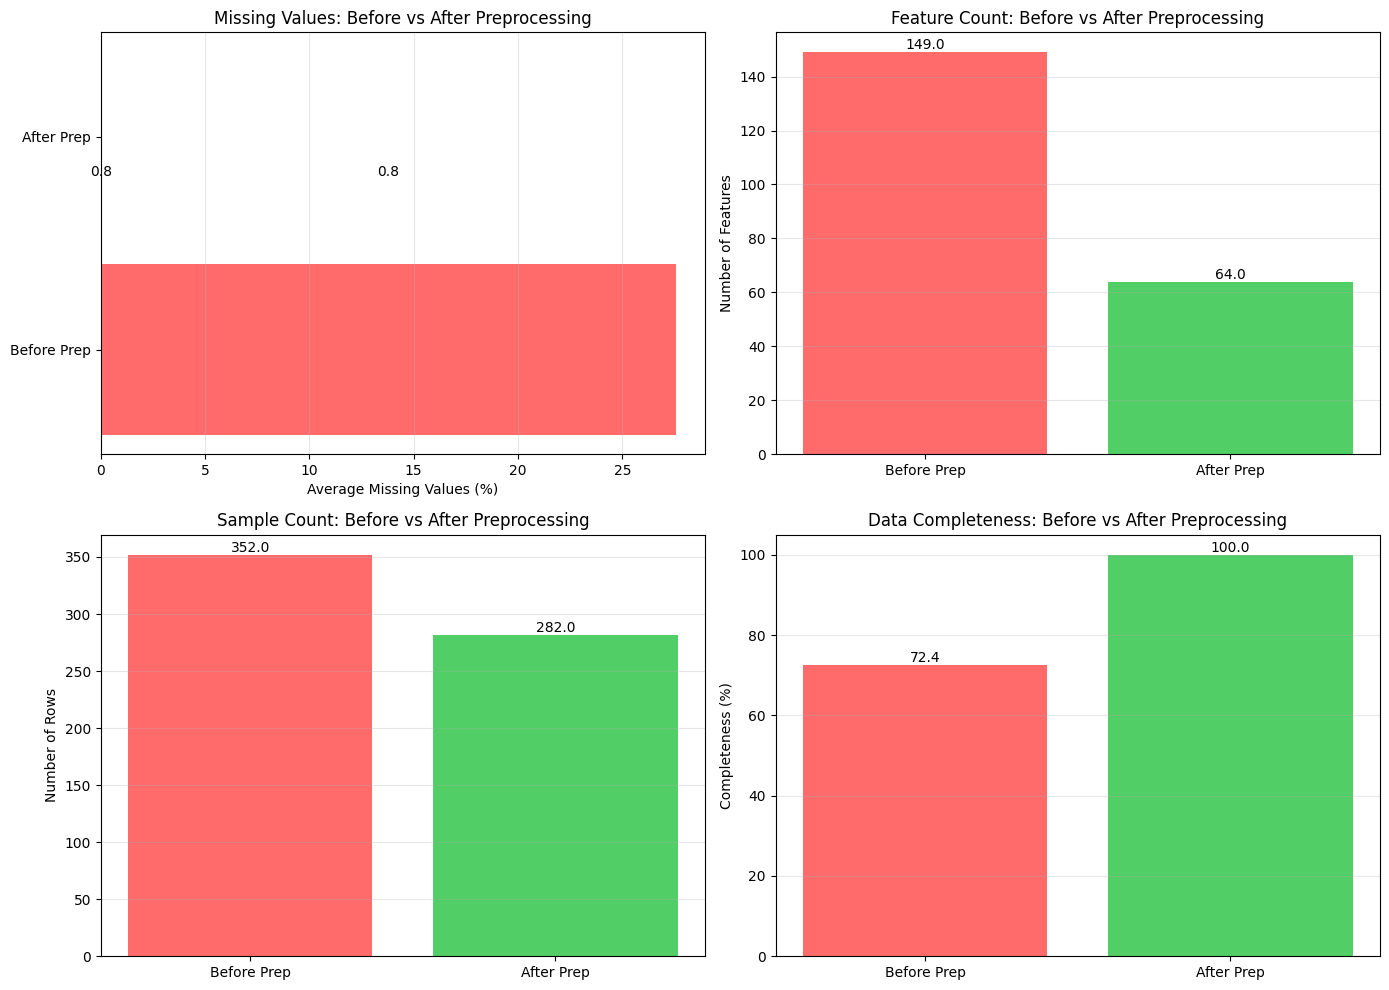


=== DATA PREPROCESSING SUMMARY ===
Features removed: 85
Rows removed: 70
Data completeness improvement: 27.58%


In [25]:
# Comparison visualization: Before and After Data Preprocessing

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Missing Values Comparison
null_before = df.isnull().mean() * 100
null_after = df_impute.isnull().mean() * 100

axes[0, 0].barh(['Before Prep', 'After Prep'], 
                [null_before.mean(), null_after.mean()], 
                color=['#ff6b6b', '#51cf66'])
axes[0, 0].set_xlabel('Average Missing Values (%)')
axes[0, 0].set_title('Missing Values: Before vs After Preprocessing')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Feature Count Comparison
axes[0, 1].bar(['Before Prep', 'After Prep'], 
              [df.shape[1], df_impute.shape[1]], 
              color=['#ff6b6b', '#51cf66'])
axes[0, 1].set_ylabel('Number of Features')
axes[0, 1].set_title('Feature Count: Before vs After Preprocessing')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Row Count Comparison
axes[1, 0].bar(['Before Prep', 'After Prep'], 
              [df.shape[0], df_impute.shape[0]], 
              color=['#ff6b6b', '#51cf66'])
axes[1, 0].set_ylabel('Number of Rows')
axes[1, 0].set_title('Sample Count: Before vs After Preprocessing')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Data Completeness
completeness_before = (1 - null_before.mean()/100) * 100
completeness_after = (1 - null_after.mean()/100) * 100

axes[1, 1].bar(['Before Prep', 'After Prep'], 
              [completeness_before, completeness_after], 
              color=['#ff6b6b', '#51cf66'])
axes[1, 1].set_ylabel('Completeness (%)')
axes[1, 1].set_title('Data Completeness: Before vs After Preprocessing')
axes[1, 1].set_ylim([0, 105])
axes[1, 1].grid(axis='y', alpha=0.3)

for ax in axes.flat:
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height,
                f'{height:.1f}', ha="center", va="bottom")

plt.tight_layout()
plt.show()

print("\n=== DATA PREPROCESSING SUMMARY ===")
print(f"Features removed: {df.shape[1] - df_impute.shape[1]}")
print(f"Rows removed: {df.shape[0] - df_impute.shape[0]}")
print(f"Data completeness improvement: {completeness_after - completeness_before:.2f}%")

# Model Building

In [26]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='f1',  # fokus ke F1 (lebih relevan dari accuracy)
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    valid_mean = valid_scores.mean(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
    plt.plot(train_sizes, valid_mean, marker='o', label='Validation Score')

    plt.title(title)
    plt.xlabel("Jumlah Data Latih")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [27]:
# this fucntion calculates different evaluation parameters of a model

def evaluate_model(y_true,y_pred):
  accuracy = accuracy_score(y_true, y_pred)
  print("Accuracy:", accuracy)
  precision = precision_score(y_true, y_pred)
  print("Precision:", precision)
  recall = recall_score(y_true, y_pred)
  print("Recall:", recall)
  f1 = f1_score(y_true, y_pred)
  print("F1 Score:", f1)
  auc = roc_auc_score(y_true, y_pred)
  print("AUC-ROC:", auc)
  mae = mean_absolute_error(y_true, y_pred)
  print("Mean Absolute Error:", mae)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  print("Root Mean Squared Error:", rmse)
  cm = confusion_matrix(y_true, y_pred)
  sns.heatmap(cm, annot=True, fmt='d')
  plt.show()

In [28]:
# checking the distribution of data points between the two classes

cancer_class = df_impute[df_impute['Active_cancer'] == 0]
non_cancer_class = df_impute[df_impute['Active_cancer'] == 1]
print('number of cancer patient is {}'.format(len(cancer_class)))
print('while number of non-cancer patient is {}'.format(len(non_cancer_class)))

# Print total fitur
total_fitur = df_impute.drop(columns=['Active_cancer']).shape[1]
print(f'total fitur: {total_fitur}')

number of cancer patient is 147
while number of non-cancer patient is 135
total fitur: 63


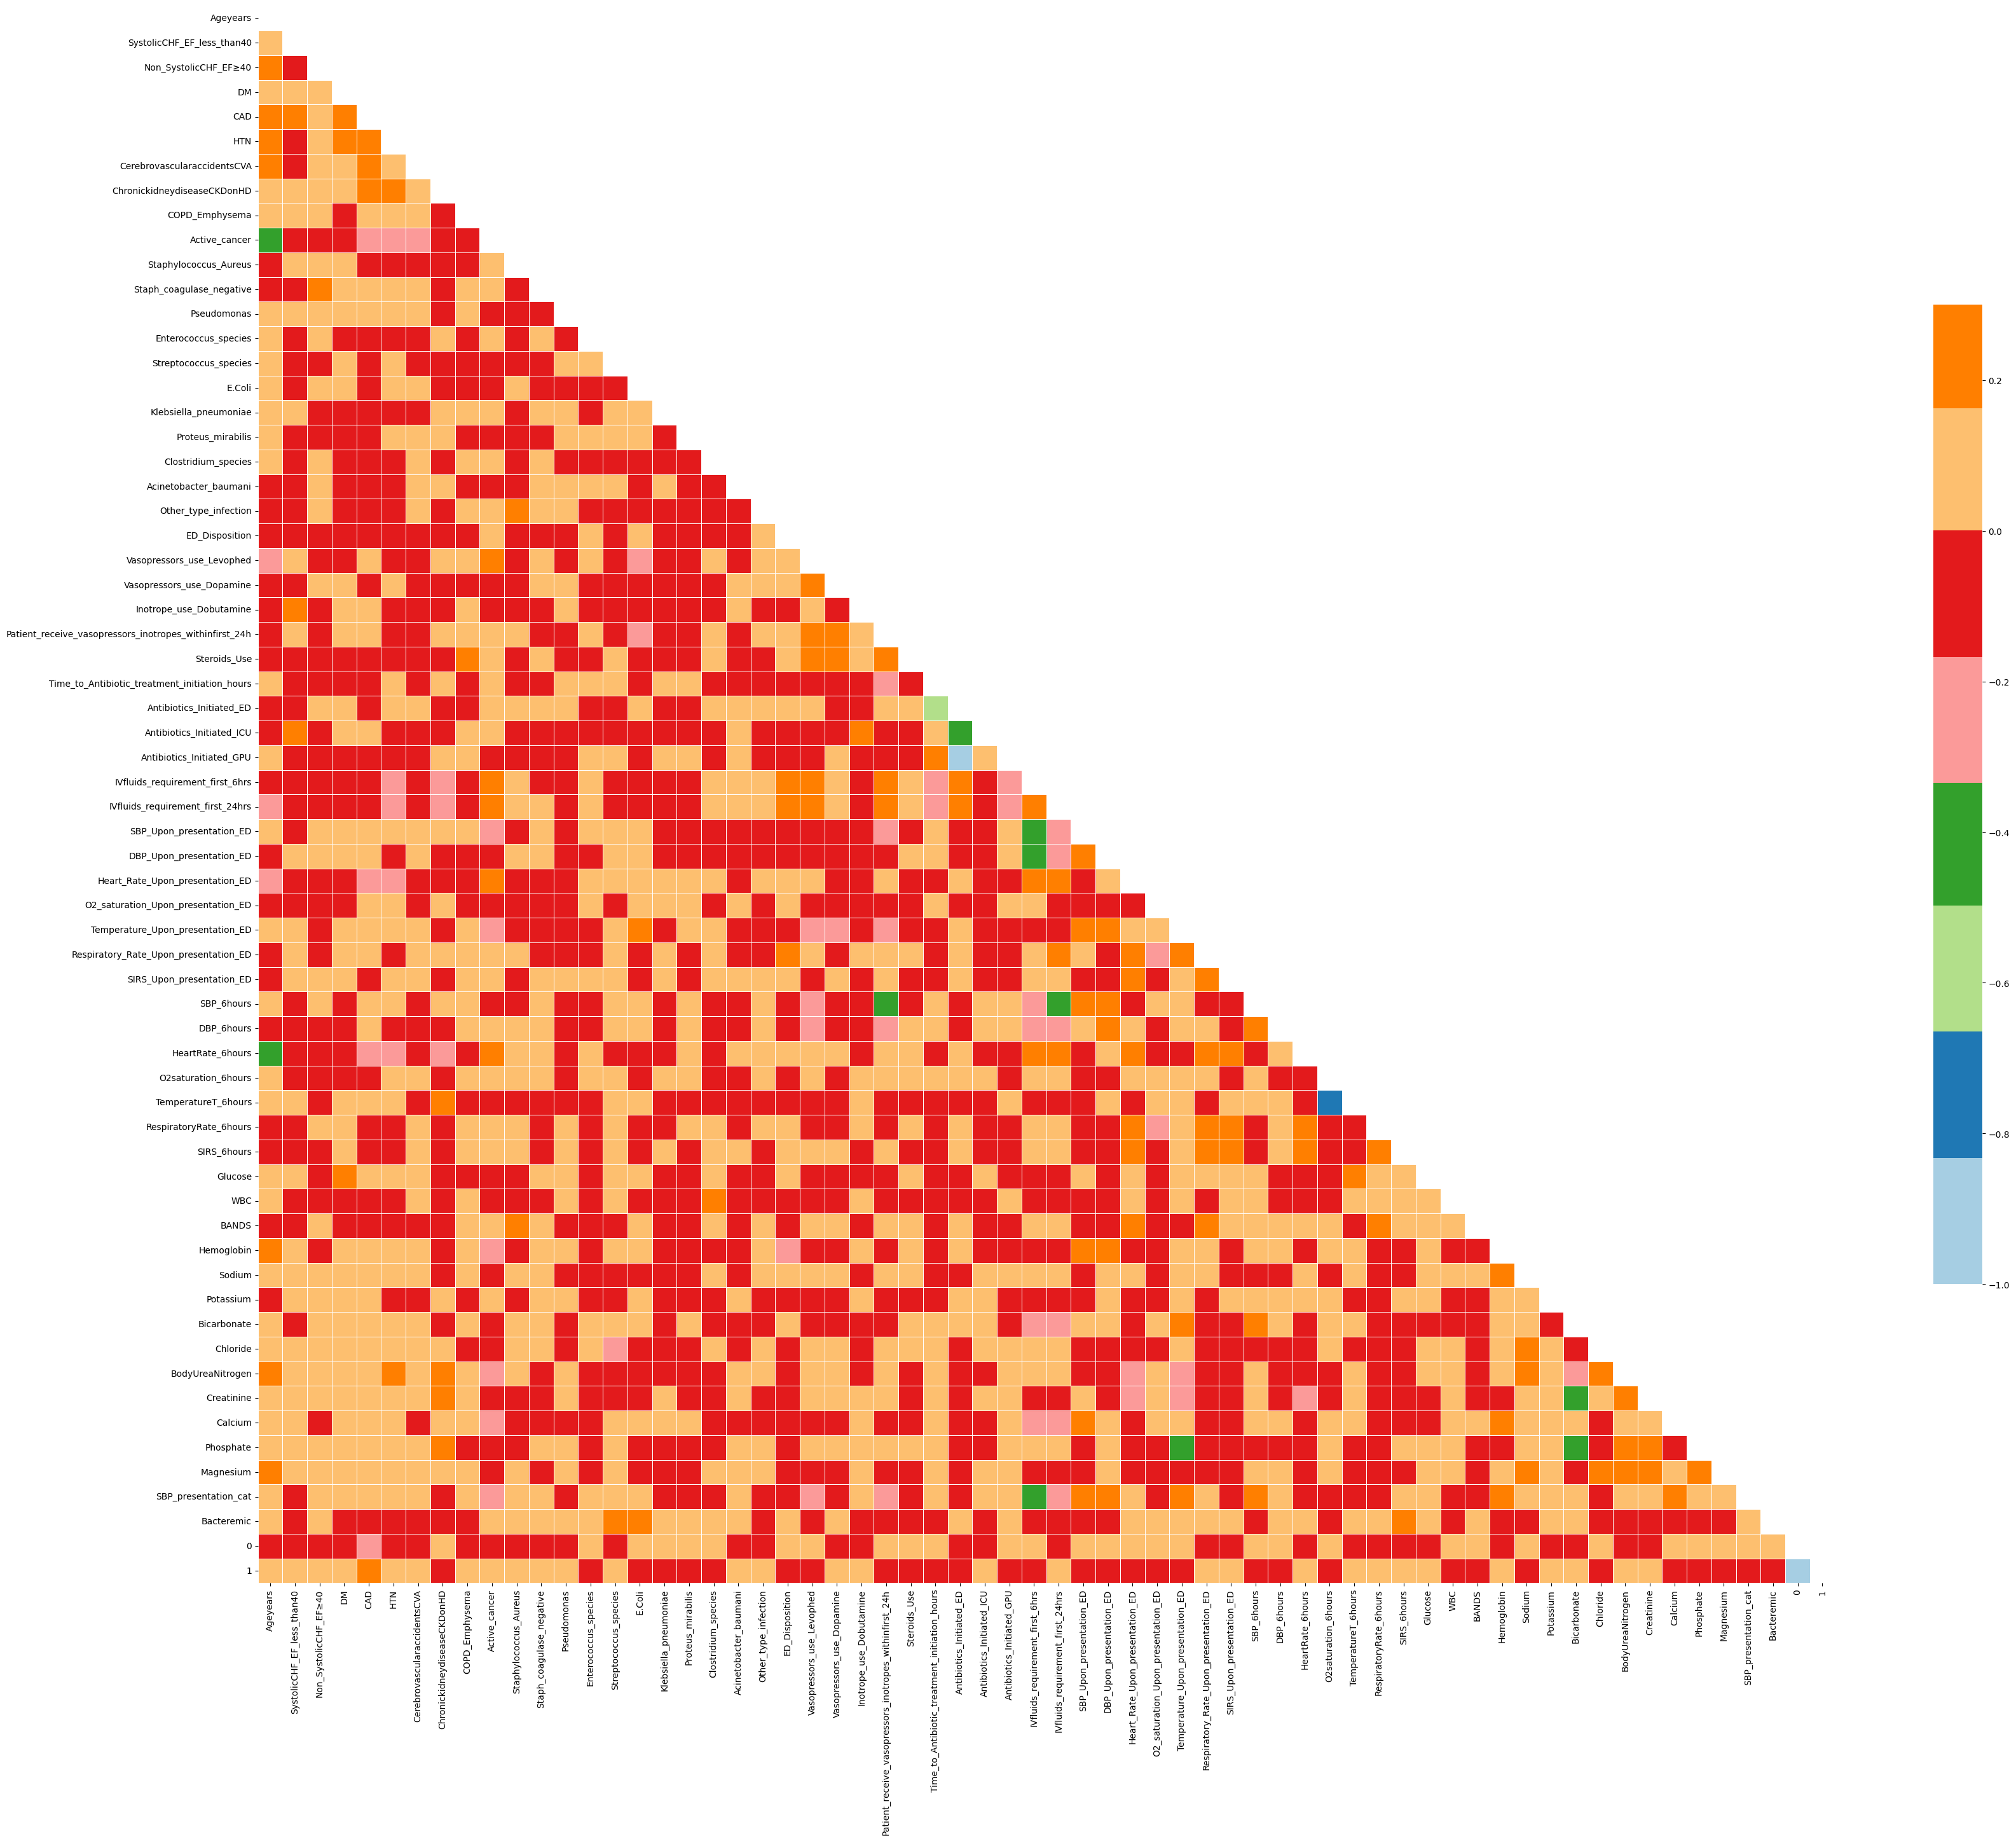

In [29]:
corr_matrix(df_impute)

## XGBoost

In [30]:
cols_drop = [
    "StudyID", "Study_type", "Site_of_infection", "Code",
    "Mortality_28days", "Mortality_72hours", "Mortality_60days",
    "Expired_at_hospital_during_this_admission", "Cancer_in_remission",
    "Diagnosis", "DCHome", "ICU_LOS_days", "GPU_LOS_days",
    "Hospital_LOS_days", "ICU_LOS_hours", "GPU_LOS_hours",
    "Hospital_LOS_hours", "ED_Length_of_Stay_LOS_hours",
    "Admission_to_hospital", "Antibiotics_Used",
    "Undergone_chemotherapy", "Undergone_radiation_therapy",
    "Undergone_surgical_therapy", "ICU_GPU_admission",
    "ICU_Admission", "GPU_Admission"
]

In [31]:
def parse_ageyears(value):
        if isinstance(value, str) and value.strip() == ">90":
            return 90.0
        if pd.isna(value):
            return np.nan
        if isinstance(value, (int, float, np.integer, np.floating)):
            return float(value)
        text = str(value).strip()
        if "-" in text:
            low, high = text.split("-", 1)
            return (float(low) + float(high)) / 2
        return pd.to_numeric(text, errors="coerce")

In [32]:
def clean_data_train(x):
    x = x.copy()

    # Parsing
    if "Ageyears" in x.columns:
        x["Ageyears"] = x["Ageyears"].apply(parse_ageyears)

    # Drop leakage & irrelevant
    x = x.drop(columns=[c for c in cols_drop if c in x.columns], errors="ignore")

    # Drop high null
    null_ratio = x.isnull().mean()
    drop_high_null = null_ratio[null_ratio >= 0.25].index.tolist()
    x = x.drop(columns=drop_high_null, errors="ignore")

    # Encoding
    if "Sex" in x.columns:
        x = pd.get_dummies(x, columns=["Sex"])

    # Correlation filtering
    numeric_cols = x.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) > 1:
        corr = x[numeric_cols].corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        cols_corr_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
        x = x.drop(columns=cols_corr_drop, errors="ignore")
    else:
        cols_corr_drop = []

    # Simpan metadata
    metadata = {
        "drop_high_null": drop_high_null,
        "cols_corr_drop": cols_corr_drop,
        "final_columns": x.columns.tolist()
    }

    return x, metadata

In [33]:
def clean_data_test(x, metadata):
    x = x.copy()

    # Parsing
    if "Ageyears" in x.columns:
        x["Ageyears"] = x["Ageyears"].apply(parse_ageyears)

    # Drop leakage
    x = x.drop(columns=[c for c in cols_drop if c in x.columns], errors="ignore")

    # Gunakan hasil train (JANGAN hitung ulang)
    x = x.drop(columns=metadata["drop_high_null"], errors="ignore")

    # Encoding
    if "Sex" in x.columns:
        x = pd.get_dummies(x, columns=["Sex"])

    # Drop correlated (pakai hasil train)
    x = x.drop(columns=metadata["cols_corr_drop"], errors="ignore")

    # Samakan kolom dengan train
    x = x.reindex(columns=metadata["final_columns"], fill_value=0)

    return x

In [34]:
# train test split for the imputed output

X = df.drop('Active_cancer', axis=1)
y = df['Active_cancer']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

X_train, metadata = clean_data_train(X_train)
X_test = clean_data_test(X_test, metadata)

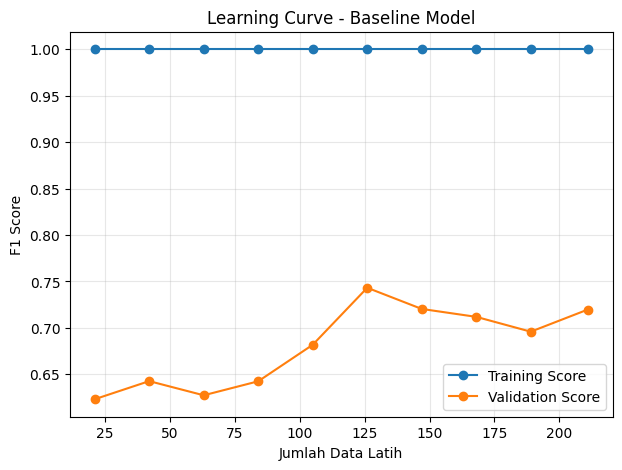

Accuracy: 0.75
Precision: 0.7073170731707317
Recall: 0.7435897435897436
F1 Score: 0.725
AUC-ROC: 0.749345892203035
Mean Absolute Error: 0.25
Root Mean Squared Error: 0.5


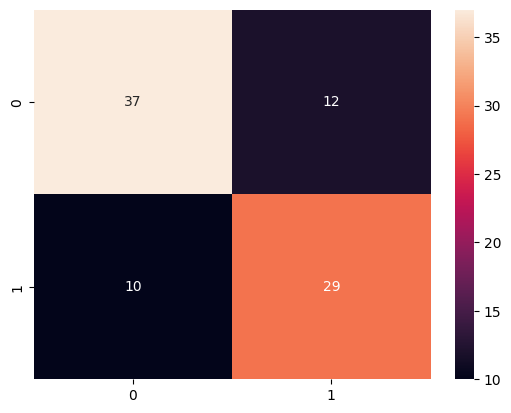

In [35]:
# Baseline model without feature selection
baseline_model = XGBClassifier(objective='binary:logistic', random_state=42)

plot_learning_curve(
    baseline_model,
    X_train,
    y_train,
    title="Learning Curve - Baseline Model"
)

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
evaluate_model(y_test, y_pred_baseline)

### Feature Selection

In [36]:
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# ======================
# 1. Feature ranking (ONLY TRAIN DATA)
# ======================
xgb_temp = XGBClassifier(random_state=42)
xgb_temp.fit(X_train, y_train)

importances = xgb_temp.feature_importances_
feature_importance_df = pd.DataFrame({
    'Fitur': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# ======================
# 2. Evaluasi jumlah fitur (ONLY TRAIN DATA via CV)
# ======================
k_list = range(5, len(X_train.columns)+1)

acc_scores = []
prec_scores = []
f1_scores = []

best_f1 = 0
best_k = 0
best_features = None

for k in k_list:
    selected = feature_importance_df.head(k)['Fitur']
    X_train_k = X_train[selected]

    model = XGBClassifier(random_state=42)

    acc = cross_val_score(model, X_train_k, y_train, cv=5, scoring='accuracy').mean()
    prec = cross_val_score(model, X_train_k, y_train, cv=5, scoring='precision').mean()
    f1 = cross_val_score(model, X_train_k, y_train, cv=5, scoring='f1').mean()

    acc_scores.append(acc)
    prec_scores.append(prec)
    f1_scores.append(f1)

    if f1 > best_f1:
        best_f1 = f1
        best_k = k
        best_features = selected

# ======================
# 3. Final model (TRAIN → TEST)
# ======================
X_train_final = X_train[best_features]
X_test_final = X_test[best_features]

final_model = XGBClassifier(random_state=42)
final_model.fit(X_train_final, y_train)

y_pred = final_model.predict(X_test_final)

# ======================
# 4. Final evaluation (REAL PERFORMANCE)
# ======================
print("=== HASIL OPTIMAL (NO LEAKAGE) ===")
print(f"Best k (jumlah fitur): {best_k}")
print(f"Best CV F1 Score: {best_f1:.4f}")

print("\n=== TEST PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")

print(f"\nSelected Features:\n{list(best_features)}")

=== HASIL OPTIMAL (NO LEAKAGE) ===
Best k (jumlah fitur): 29
Best CV F1 Score: 0.7653

=== TEST PERFORMANCE ===
Accuracy: 0.7500
Precision: 0.6977
F1 Score: 0.7317

Selected Features:
['SystolicCHF_EF_less_than40', 'Ageyears', 'WBC', 'SBP_Upon_presentation_ED', 'Hemoglobin', 'HTN', 'Sex_0', 'CAD', 'CerebrovascularaccidentsCVA', 'Temperature_Upon_presentation_ED', 'IVfluids_requirement_first_24hrs', 'Bacteremic', 'DM', 'HeartRate_6hours', 'Respiratory_Rate_Upon_presentation_ED', 'Creatinine', 'DBP_Upon_presentation_ED', 'TemperatureT_6hours', 'RespiratoryRate_6hours', 'Sodium', 'Glucose', 'SIRS_6hours', 'Phosphate', 'Calcium', 'Heart_Rate_Upon_presentation_ED', 'BodyUreaNitrogen', 'Time_to_Antibiotic_treatment_initiation_hours', 'DBP_6hours', 'O2_saturation_Upon_presentation_ED']


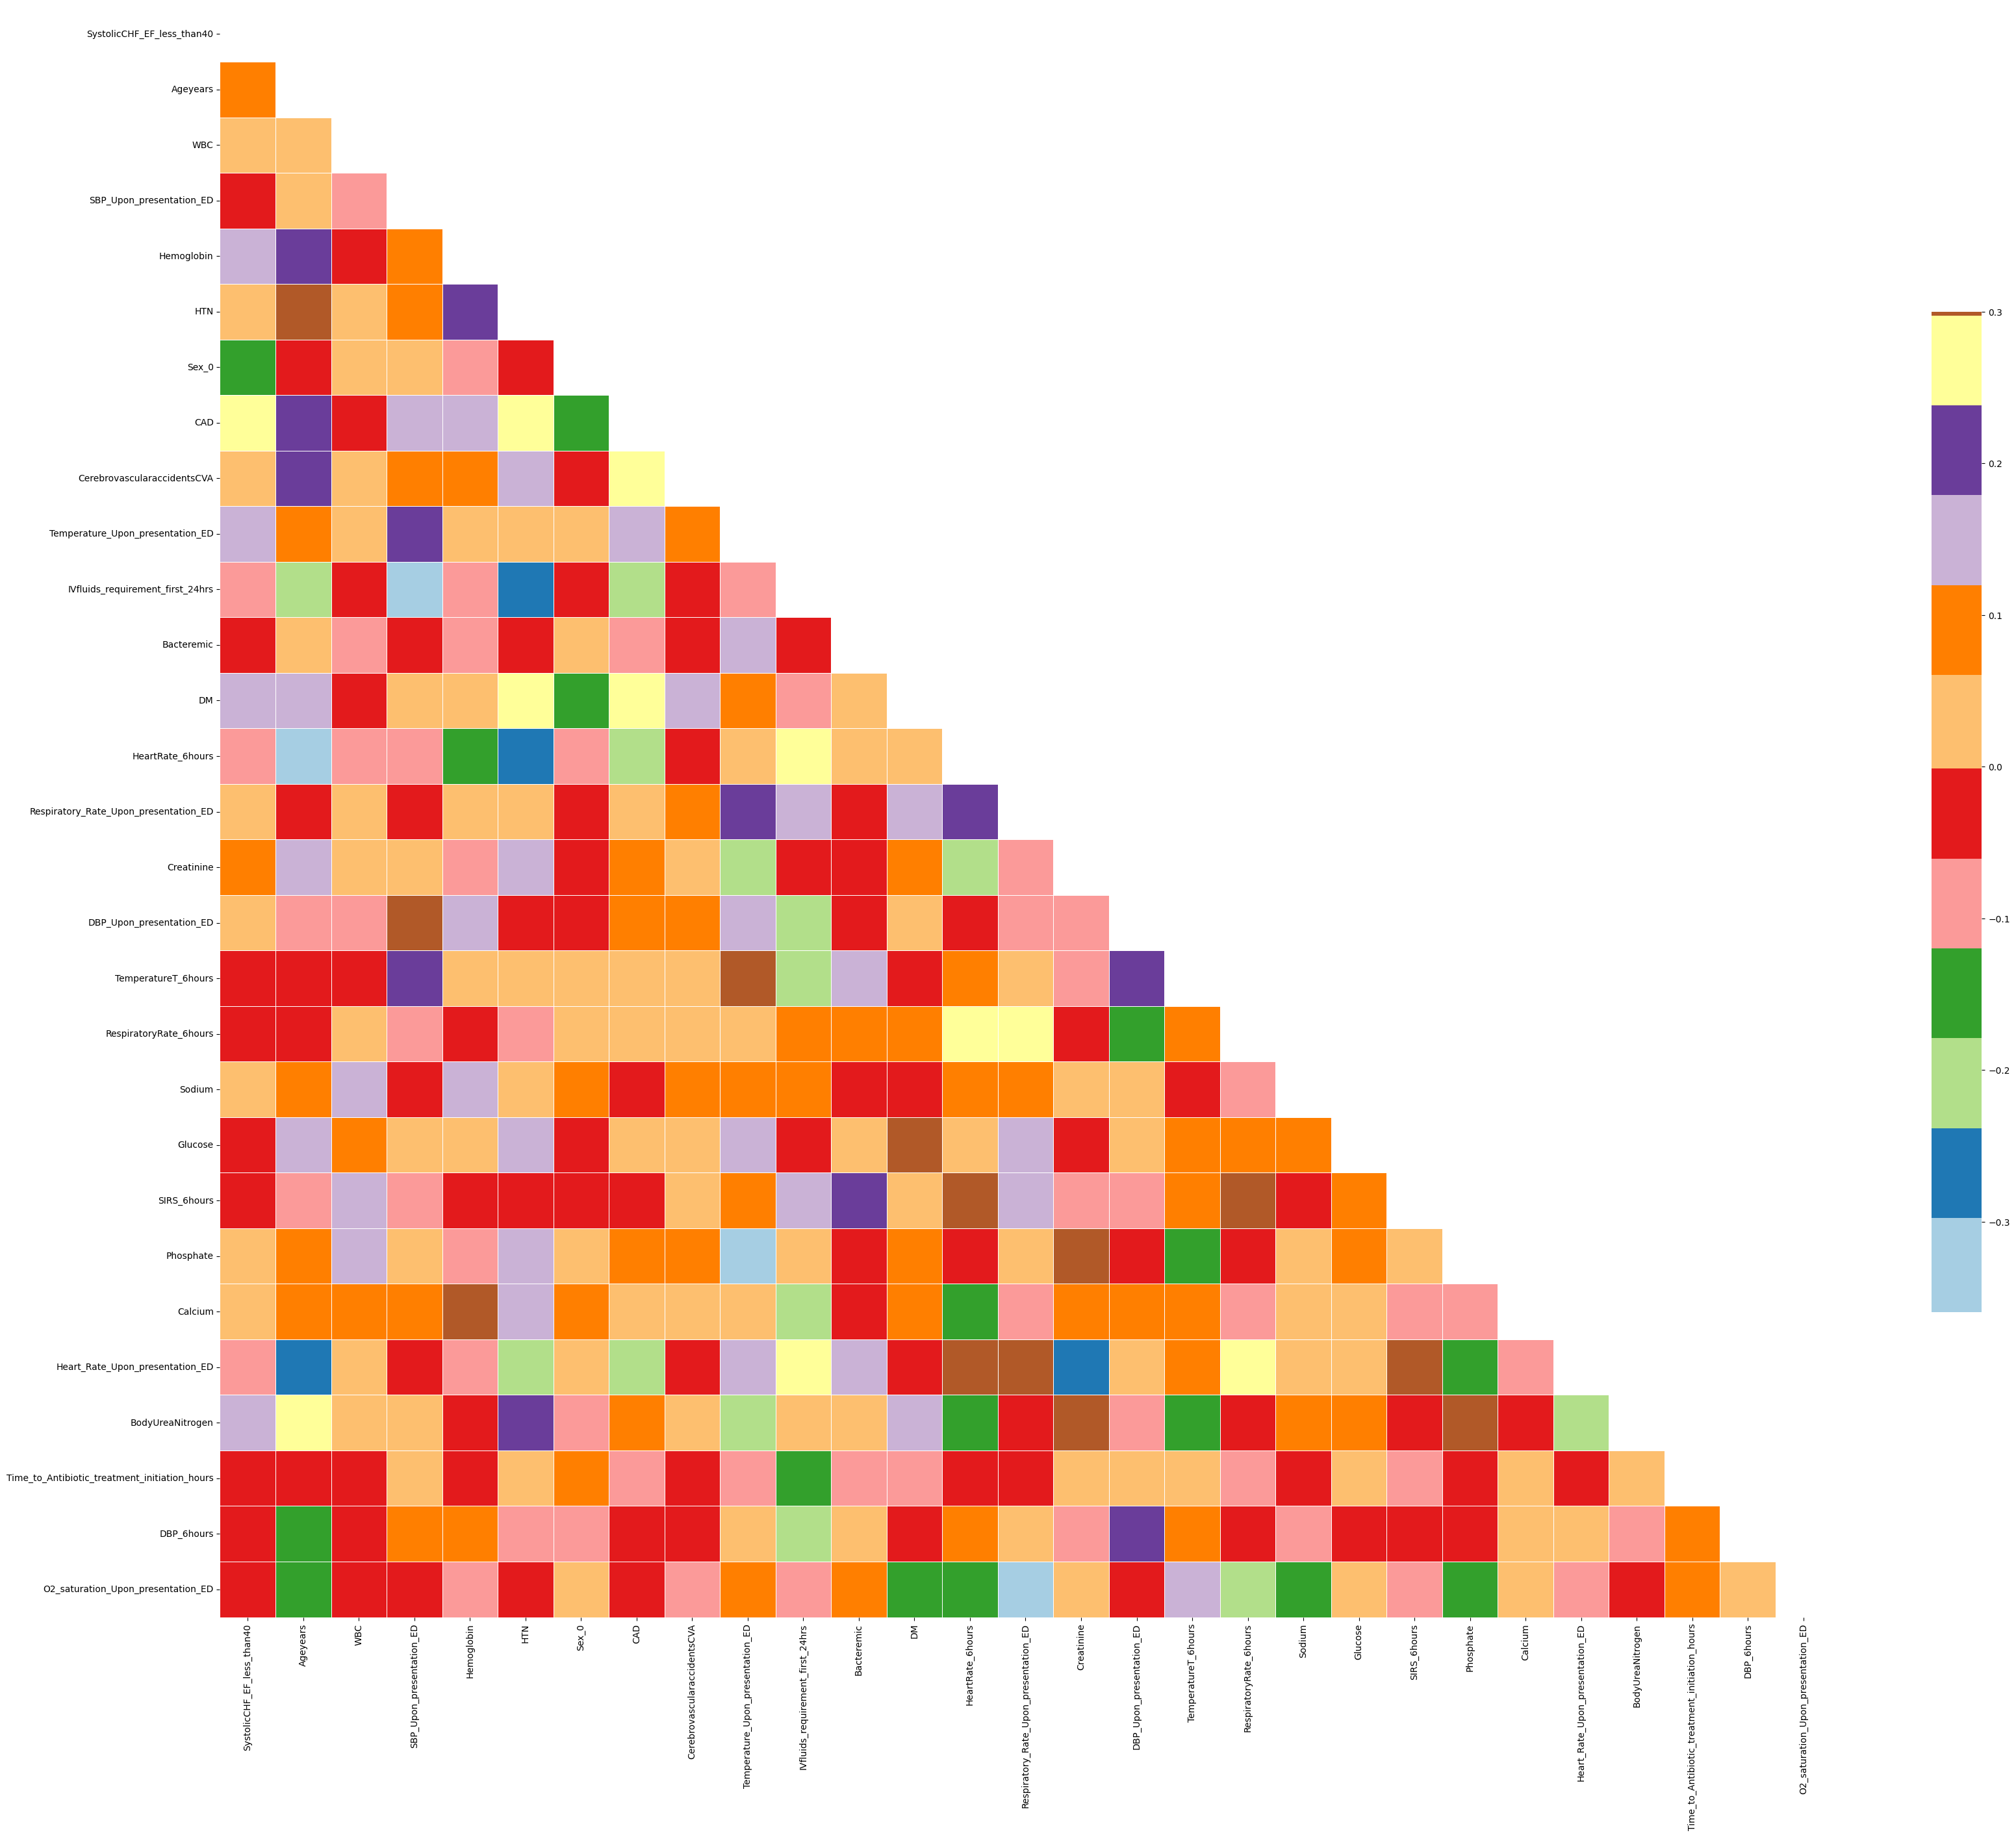

In [37]:
corr_matrix(X_train[best_features])

In [38]:
import json

# Compute correlation matrix (numeric columns only)
corr = df_train_mod.select_dtypes(include=[float, int, 'number']).corr()

cols = corr.columns.tolist()
# matrix as nested lists of floats
matrix = [[None if pd.isna(val) else float(val) for val in row] for row in corr.values]

# pairs for upper triangle (i < j)
pairs = []
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iat[i, j]
        if pd.isna(val):
            continue
        pairs.append({
            "feature_a": cols[i],
            "feature_b": cols[j],
            "correlation": float(val)
        })

structured = {
    "variables": cols,
    "matrix": matrix,
    "pairs": pairs
}

with open("cor_matrix.json", "w") as f:
    json.dump(structured, f, indent=2)

print("Saved correlation matrix to cor_matrix.json")

Saved correlation matrix to cor_matrix.json


In [39]:
X_train_slim = X_train[best_features]
X_test_slim = X_test[best_features]

Accuracy: 0.75
Precision: 0.6976744186046512
Recall: 0.7692307692307693
F1 Score: 0.7317073170731707
AUC-ROC: 0.7519623233908947
Mean Absolute Error: 0.25
Root Mean Squared Error: 0.5


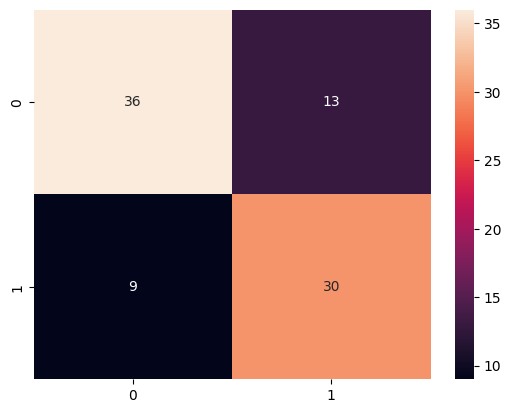

In [40]:
# XGBoost model score after feature selection with top 15 features

model_slim = XGBClassifier(objective='binary:logistic', random_state=42)
model_slim.fit(X_train_slim, y_train)

y_pred_slim = model_slim.predict(X_test_slim)

evaluate_model(y_test, y_pred_slim)

### Param Grid Variables

In [ ]:
param_grid = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01],
    'n_estimators': [100, 200, 300],
    'subsample': [0.5, 1.0],
    'colsample_bytree': [0.5, 1.0],
}

In [42]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, f1_score
from xgboost import XGBClassifier

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scoring dictionary
scoring_dict = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score),
    'f1': make_scorer(f1_score)
}

# Storage
best_models = {}
best_params = {}
best_scores = {}

for metric_name, scorer in scoring_dict.items():
    print(f"\n=== GRID SEARCH UNTUK {metric_name.upper()} ===")

    grid = GridSearchCV(
        estimator=XGBClassifier(objective='binary:logistic', random_state=42),
        param_grid=param_grid,
        scoring=scorer,
        cv=cv,
        verbose=1,
        n_jobs=1
    )

    grid.fit(X_train_slim, y_train)

    # Simpan hasil
    best_models[metric_name] = grid.best_estimator_
    best_params[metric_name] = grid.best_params_
    best_scores[metric_name] = grid.best_score_

# Assign ke variable terpisah (biar mudah dipakai)
accuracy_model = best_models['accuracy']
precision_model = best_models['precision']
f1_model = best_models['f1']

accuracy_model_params = best_params['accuracy']
precision_model_params = best_params['precision']
f1_model_params = best_params['f1']

accuracy_best_score = best_scores['accuracy']
precision_best_score = best_scores['precision']
f1_best_score = best_scores['f1']

# Output ringkas
print("\n=== RINGKASAN HASIL ===")
print("Accuracy Best:", accuracy_best_score)
print("Params:", accuracy_model_params)

print("\nPrecision Best:", precision_best_score)
print("Params:", precision_model_params)

print("\nF1 Best:", f1_best_score)
print("Params:", f1_model_params)


=== GRID SEARCH UNTUK ACCURACY ===
Fitting 5 folds for each of 2160 candidates, totalling 10800 fits



=== GRID SEARCH UNTUK PRECISION ===
Fitting 5 folds for each of 2160 candidates, totalling 10800 fits

=== GRID SEARCH UNTUK F1 ===
Fitting 5 folds for each of 2160 candidates, totalling 10800 fits

=== RINGKASAN HASIL ===
Accuracy Best: 0.7461538461538462
Params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': 2, 'subsample': 0.8}

Precision Best: 0.7687590187590188
Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 0.7}

F1 Best: 0.7732151865455019
Params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'scale_pos_weight': 3, 'subsample': 1.0}


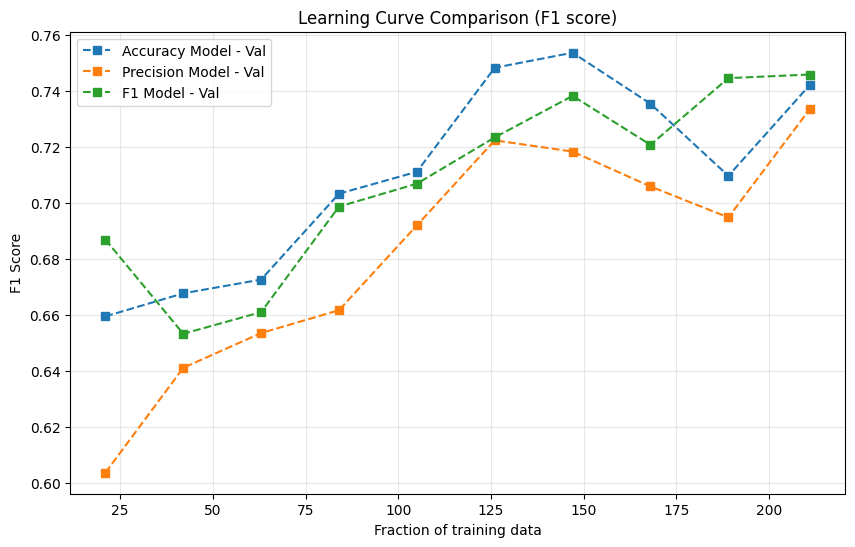

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

models = {
    "Accuracy Model": accuracy_model,
    "Precision Model": precision_model,
    "F1 Model": f1_model
}

train_sizes = np.linspace(0.1, 1.0, 10)

# Membuat 1 baris dengan 3 kolom grafik berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, (name, model) in enumerate(models.items()):
    ax = axes[idx]
    
    ts, train_scores, val_scores = learning_curve(
        model,
        X_train_slim,
        y_train,
        cv=5,
        scoring='f1', # Evaluasi semua model tetap menggunakan metric F1 untuk konsistensi
        train_sizes=train_sizes,
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    
    # Garis Train (Biru)
    ax.plot(ts, train_scores.mean(axis=1), marker='o', linestyle='-', 
            color='dodgerblue', linewidth=2, label='Train Score')
    
    # Garis Validasi (Oranye)
    ax.plot(ts, val_scores.mean(axis=1), marker='s', linestyle='-', 
            color='darkorange', linewidth=2, label='Val Score (CV)')
    
    # Menghitung rata-rata gap di akhir titik data
    final_gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
    
    ax.set_title(f"{name}\n(Final Gap: {final_gap:.4f})", fontsize=12)
    ax.set_xlabel("Jumlah Data Latih", fontsize=10)
    if idx == 0:
        ax.set_ylabel("F1-Score", fontsize=11)
    
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle("Perbandingan Learning Curve Hasil Hyperparameter Tuning (Evaluasi F1-Score)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Model best Accuracy

Threshold Terbaik: 0.7500000000000002 

Accuracy: 0.8068181818181818
Precision: 0.8666666666666667
Recall: 0.6666666666666666
F1 Score: 0.7536231884057971
AUC-ROC: 0.7925170068027211
Mean Absolute Error: 0.19318181818181818
Root Mean Squared Error: 0.4395245364957663


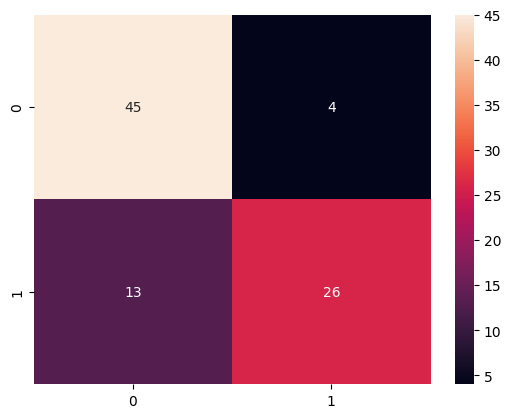

In [44]:
y_prob = accuracy_model.predict_proba(X_test_slim)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)

best_acc = 0
best_thresh = 0

for thresh in thresholds:
    y_pred_custom = (y_prob >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_custom)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

final_prediction = (y_prob >= best_thresh).astype(int)
print(f"Threshold Terbaik: {best_thresh} \n")
evaluate_model(y_test, final_prediction)

### Model best Precision

Threshold Terbaik: 0.8500000000000002 

Accuracy: 0.75
Precision: 0.8695652173913043
Recall: 0.5128205128205128
F1 Score: 0.6451612903225806
AUC-ROC: 0.7257980115122973
Mean Absolute Error: 0.25
Root Mean Squared Error: 0.5


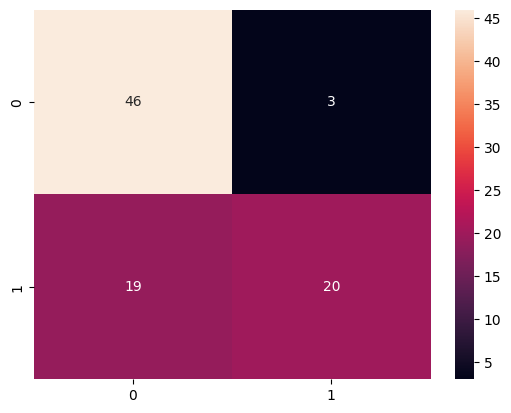

In [45]:
y_prob = precision_model.predict_proba(X_test_slim)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)

best_prec = 0
best_thresh = 0

for thresh in thresholds:
    y_pred_custom = (y_prob >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_custom)
    if prec > best_prec:
        best_prec = prec
        best_thresh = thresh

final_prediction = (y_prob >= best_thresh).astype(int)
print(f"Threshold Terbaik: {best_thresh} \n")
evaluate_model(y_test, final_prediction)

### Model best F1

Threshold Terbaik: 0.3500000000000001 

Accuracy: 0.7840909090909091
Precision: 0.6923076923076923
Recall: 0.9230769230769231
F1 Score: 0.7912087912087912
AUC-ROC: 0.7982731554160126
Mean Absolute Error: 0.2159090909090909
Root Mean Squared Error: 0.4646601886422926


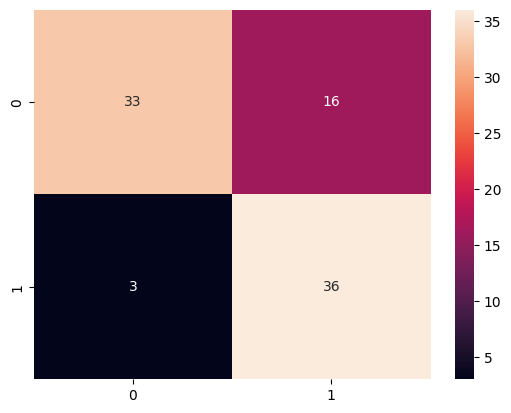

In [46]:
y_prob = f1_model.predict_proba(X_test_slim)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)

best_f1 = 0
best_thresh = 0

for thresh in thresholds:
    y_pred_custom = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_custom)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

final_prediction = (y_prob >= best_thresh).astype(int)
print(f"Threshold Terbaik: {best_thresh} \n")
evaluate_model(y_test, final_prediction)

# XAI + LLM Explanation

In [47]:
# Added Library

import os
from datasets import Dataset
import warnings
import math
import time
import json

warnings.filterwarnings("ignore", category=DeprecationWarning)

from ragas import evaluate
from ragas.metrics import faithfulness
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig

import shap
from langchain_ollama import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

In [48]:
model = f1_model

## SHAP

True Positives: 32
True Negatives: 36
False Positives: 13
False Negatives: 7

=== SHAP Summary Plot (Bee Swarm) ===


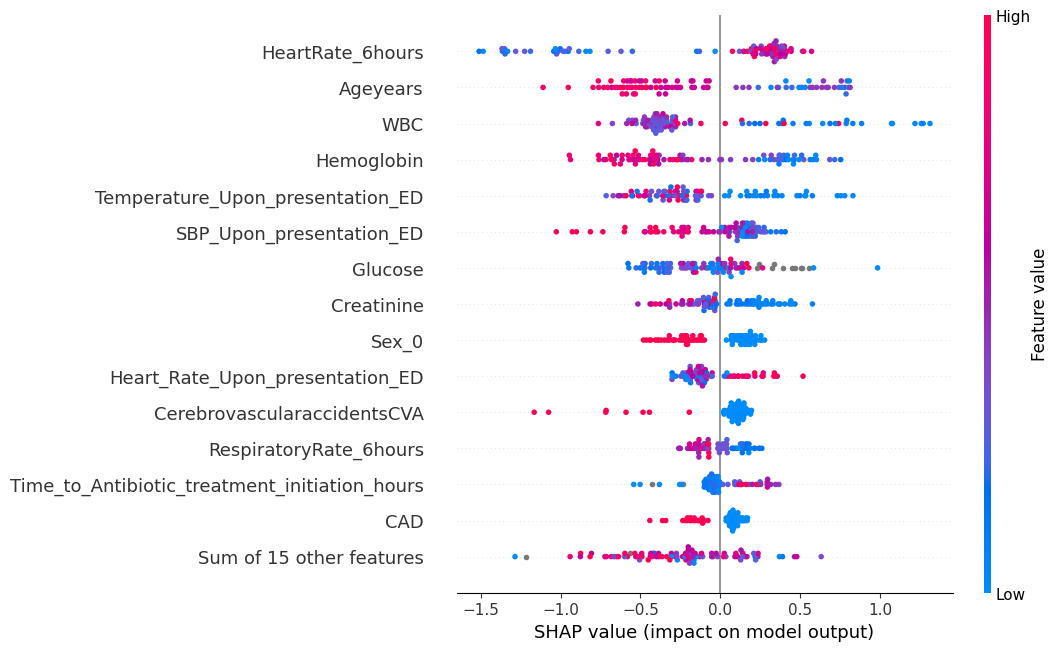

=== SHAP Global Feature Importance (Bar Plot) ===


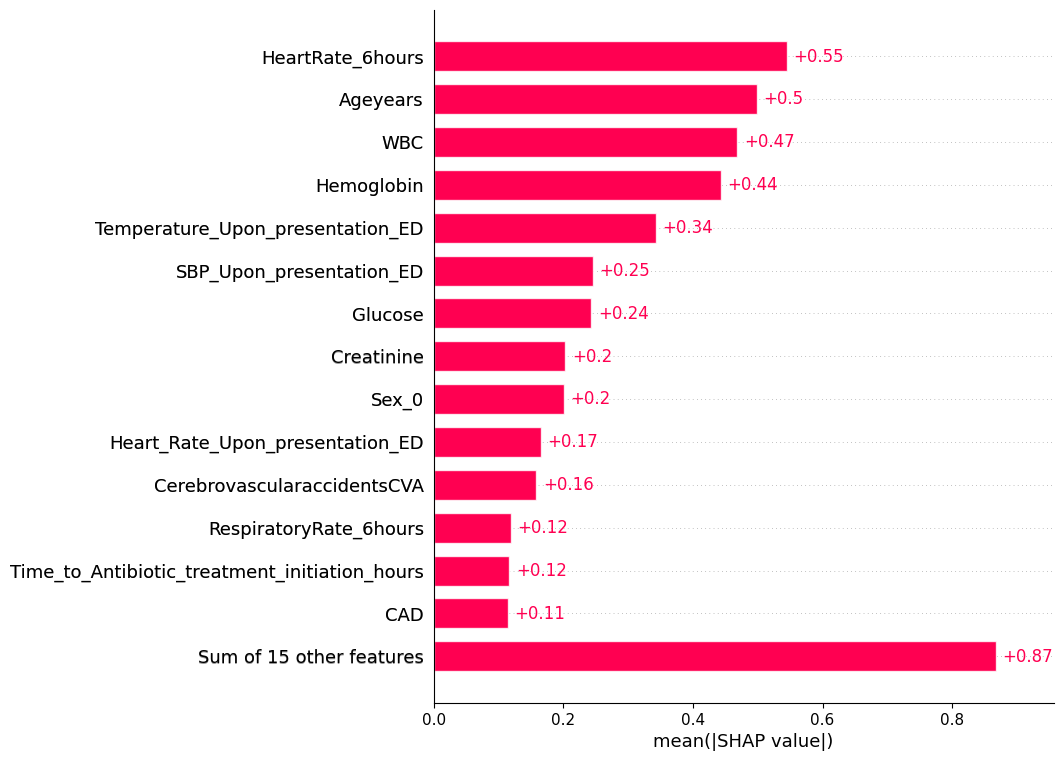

In [49]:
explainer = shap.TreeExplainer(model)
shap_values_raw = explainer(X_test_slim)

final_prediction = model.predict(X_test_slim)
proba_prediction = model.predict_proba(X_test_slim)[:, 1]

tp_condition = (y_test == 1) & (final_prediction == 1)  # True Positive
tn_condition = (y_test == 0) & (final_prediction == 0)  # True Negative
fp_condition = (y_test == 0) & (final_prediction == 1)  # False Positive
fn_condition = (y_test == 1) & (final_prediction == 0)  # False Negative

print(f"True Positives: {tp_condition.sum()}")
print(f"True Negatives: {tn_condition.sum()}")
print(f"False Positives: {fp_condition.sum()}")
print(f"False Negatives: {fn_condition.sum()}\n")

# 1. SHAP Bee Swarm Plot (Menunjukkan arah pengaruh fitur)
print("=== SHAP Summary Plot (Bee Swarm) ===")
# Plot ini menunjukkan bagaimana nilai fitur (tinggi/rendah) mempengaruhi prediksi
shap.plots.beeswarm(shap_values_raw, max_display=15)

# 2. SHAP Bar Plot (Menunjukkan tingkat kepentingan fitur secara rata-rata)
print("=== SHAP Global Feature Importance (Bar Plot) ===")
# Plot ini menunjukkan nilai rata-rata absolut SHAP, mirip dengan Feature Importance
shap.plots.bar(shap_values_raw, max_display=15)


True Positive: 32 cases
Selected Index : 3
Actual Label   : 1
Predicted Label: 1
Probability    : 0.8143


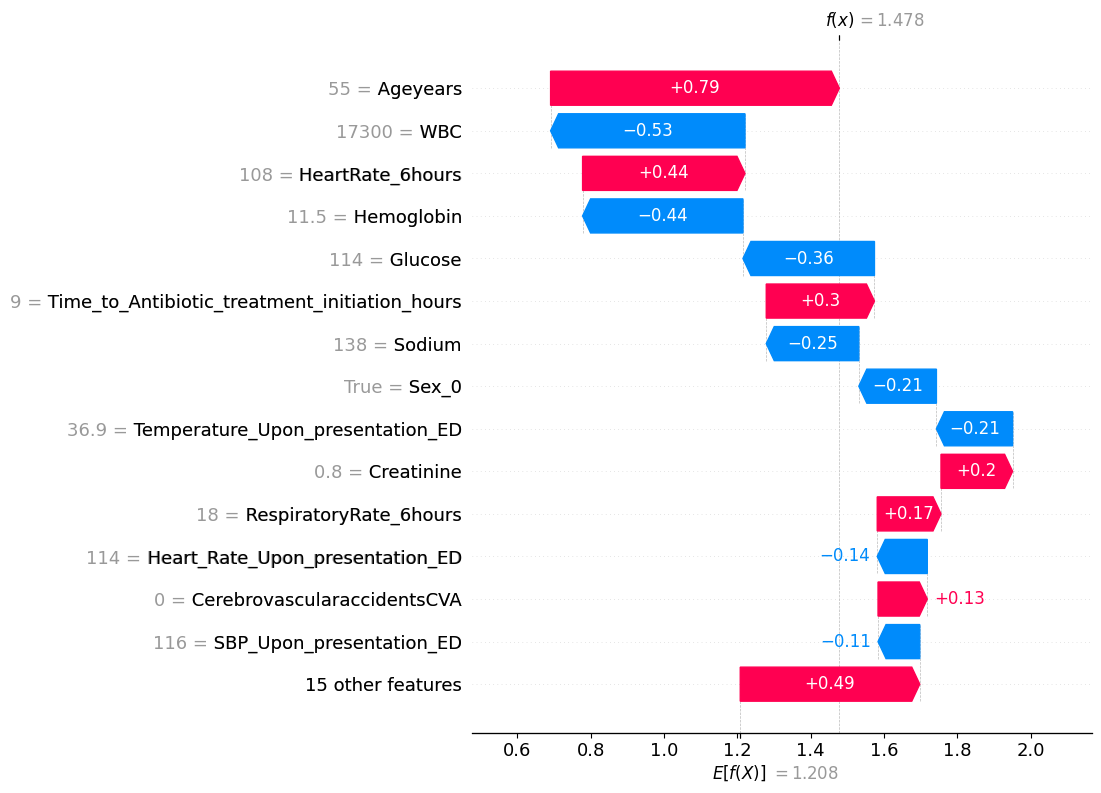

<Figure size 640x480 with 0 Axes>


True Negative: 36 cases
Selected Index : 2
Actual Label   : 0
Predicted Label: 0
Probability    : 0.1356


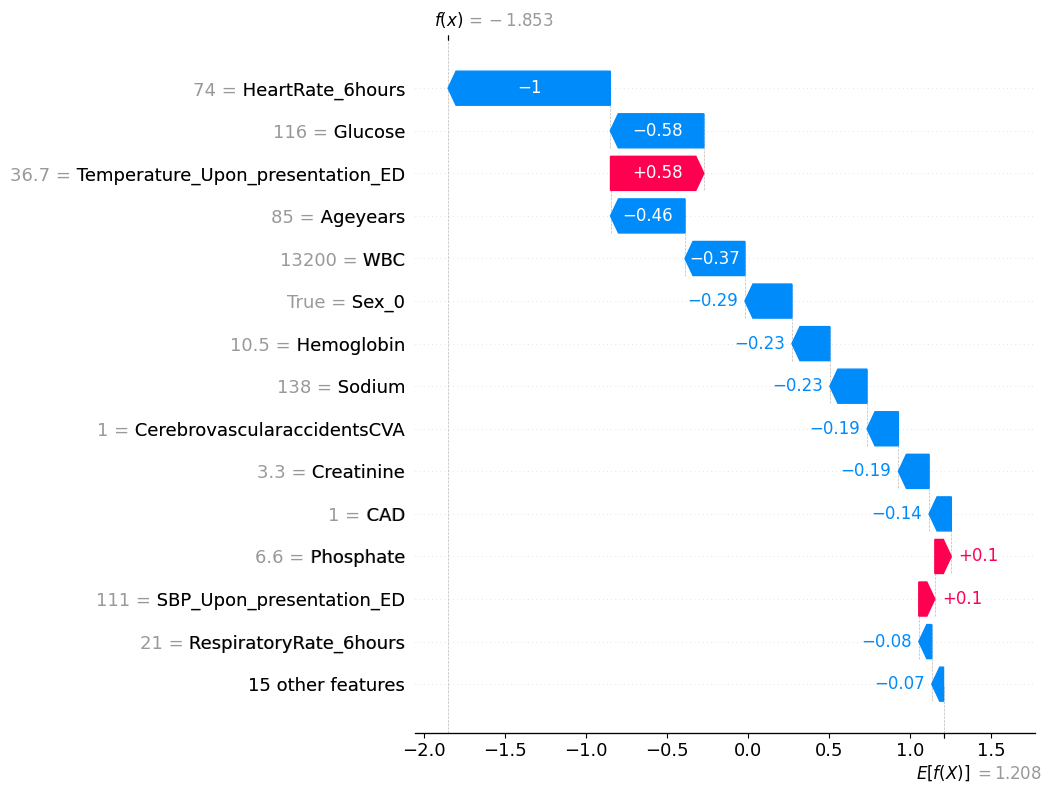

<Figure size 640x480 with 0 Axes>


False Positive: 13 cases
Selected Index : 1
Actual Label   : 0
Predicted Label: 1
Probability    : 0.7848


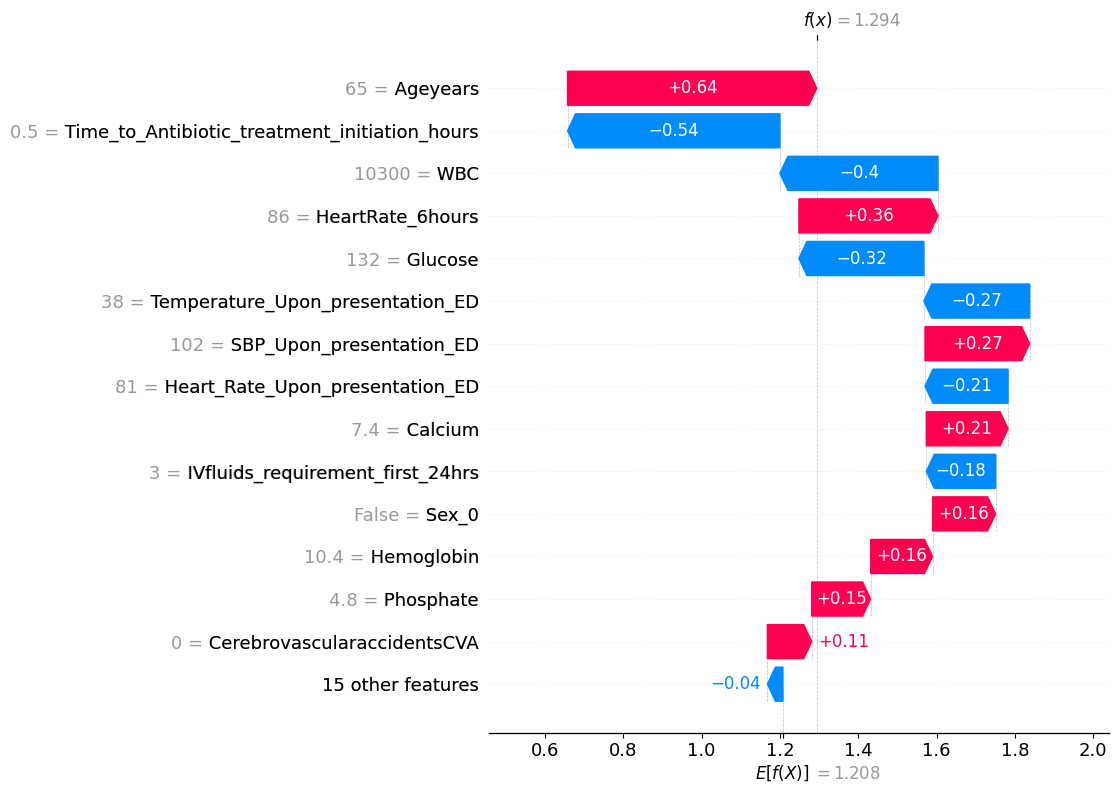

<Figure size 640x480 with 0 Axes>


False Negative: 7 cases
Selected Index : 56
Actual Label   : 1
Predicted Label: 0
Probability    : 0.4131


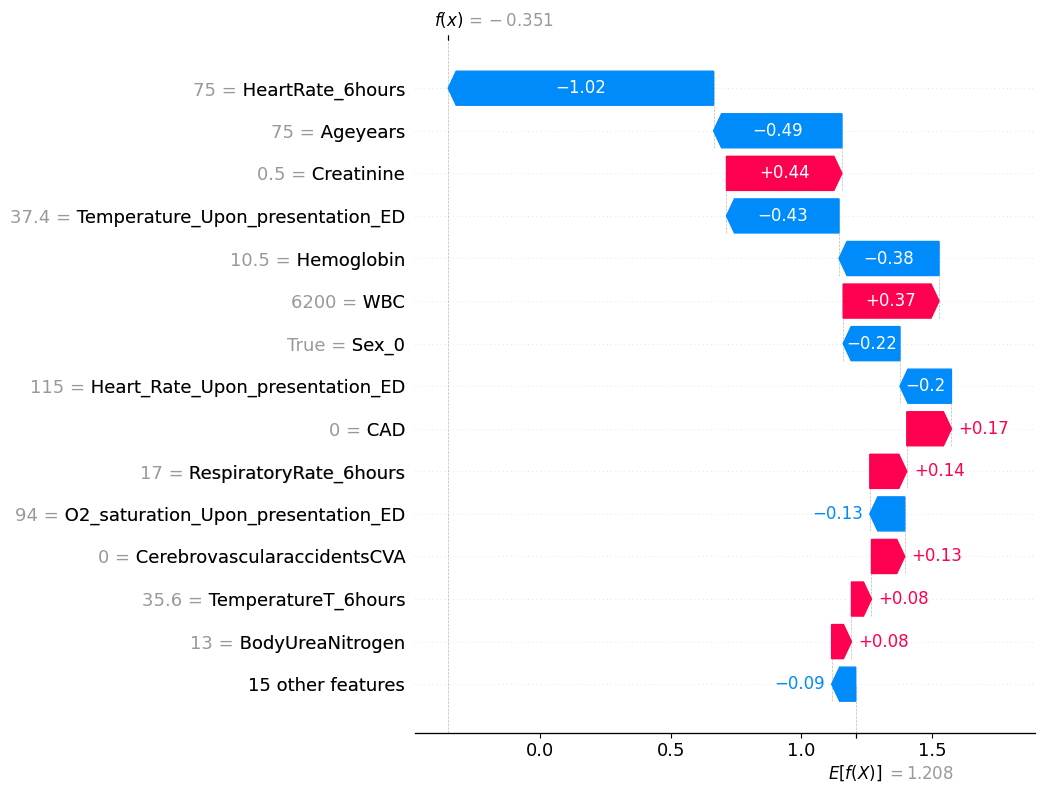

<Figure size 640x480 with 0 Axes>

In [50]:
# ==========================================
# SHAP explanation for ONE sample per class
# (TP, TN, FP, FN) WITHOUT NaN values
# ==========================================

conditions = {
    "True Positive": tp_condition,
    "True Negative": tn_condition,
    "False Positive": fp_condition,
    "False Negative": fn_condition
}

# Function to find first valid row (no NaN / inf)
def get_first_valid_index(indices, X_ref):
    for idx in indices:
        row = X_ref.iloc[idx]

        # check no NaN and finite
        if not pd.isna(row).any() and np.isfinite(row.astype(float)).all():
            return idx

    return None

# ==========================================
# Loop each confusion matrix condition
# ==========================================

for label, condition in conditions.items():

    # get indexes from condition
    indices = np.where(condition)[0]

    print(f"\n{'='*50}")
    print(f"{label}: {len(indices)} cases")
    print(f"{'='*50}")

    # find first valid sample
    valid_idx = get_first_valid_index(indices, X_test_slim)

    if valid_idx is None:
        print("No valid sample without NaN found.")
        continue

    # print prediction info
    print(f"Selected Index : {valid_idx}")
    print(f"Actual Label   : {int(y_test.iloc[valid_idx])}")
    print(f"Predicted Label: {int(final_prediction[valid_idx])}")
    print(f"Probability    : {proba_prediction[valid_idx]:.4f}")

    # ==========================================
    # Waterfall plot
    # ==========================================
    shap.plots.waterfall(
        shap_values_raw[valid_idx],
        max_display=15
    )

    plt.tight_layout()
    plt.show()

    # ==========================================
    # Force plot (fallback to bar plot)
    # ==========================================
    try:
        shap.initjs()

        display(
            shap.plots.force(
                shap_values_raw[valid_idx],
                matplotlib=False
            )
        )

    except Exception:

        shap.plots.bar(
            shap_values_raw[valid_idx],
            max_display=15
        )

        plt.show()

In [51]:
# Ambil indeks pasien yang masuk kategori False Negative
fn_indices = np.where(fn_condition)[0]

In [52]:
def extract_structured_shap(idx, top_n=5):

    row_shap = shap_values_raw[idx].values
    row_data = X_test_slim.iloc[idx]

    df = pd.DataFrame({
        "feature": X_test_slim.columns,
        "value": row_data.values,
        "shap": row_shap
    })

    df["abs_shap"] = df["shap"].abs()

    df = df.sort_values(
        by="abs_shap",
        ascending=False
    )

    positive = (
        df[df["shap"] > 0]
        .head(top_n)
        .copy()
    )

    negative = (
        df[df["shap"] < 0]
        .head(top_n)
        .copy()
    )

    positive["direction"] = "increase_risk"
    negative["direction"] = "decrease_risk"

    positive["rank"] = range(
        1,
        len(positive)+1
    )

    negative["rank"] = range(
        1,
        len(negative)+1
    )

    result = {

        "patient_data":
            row_data.to_dict(),

        "prediction": {
            "predicted_label":
                int(final_prediction[idx]),

            "actual_label":
                int(y_test.iloc[idx]),

            "probability_cancer":
                round(
                    float(
                        proba_prediction[idx]
                    ),
                    4
                )
        },

        "shap_explanation": {

            "top_positive":
                positive[
                    [
                        "rank",
                        "feature",
                        "value",
                        "shap",
                        "direction"
                    ]
                ].to_dict(
                    orient="records"
                ),

            "top_negative":
                negative[
                    [
                        "rank",
                        "feature",
                        "value",
                        "shap",
                        "direction"
                    ]
                ].to_dict(
                    orient="records"
                )
        }
    }

    return result

for i, idx in enumerate(fn_indices[:3]):
    structured = extract_structured_shap(idx)
    print(structured)

{'patient_data': {'SystolicCHF_EF_less_than40': 0, 'Ageyears': 85.0, 'WBC': 13500, 'SBP_Upon_presentation_ED': 139, 'Hemoglobin': 9.3, 'HTN': 0, 'Sex_0': True, 'CAD': 0, 'CerebrovascularaccidentsCVA': 0, 'Temperature_Upon_presentation_ED': 36.9, 'IVfluids_requirement_first_24hrs': 2.5, 'Bacteremic': 1, 'DM': 0, 'HeartRate_6hours': 61.0, 'Respiratory_Rate_Upon_presentation_ED': 24.0, 'Creatinine': 3.2, 'DBP_Upon_presentation_ED': 80, 'TemperatureT_6hours': 36.9, 'RespiratoryRate_6hours': 20.0, 'Sodium': 123, 'Glucose': nan, 'SIRS_6hours': 1.0, 'Phosphate': 5.3, 'Calcium': 9.1, 'Heart_Rate_Upon_presentation_ED': 60, 'BodyUreaNitrogen': 96.0, 'Time_to_Antibiotic_treatment_initiation_hours': 125.0, 'DBP_6hours': 60.0, 'O2_saturation_Upon_presentation_ED': 98}, 'prediction': {'predicted_label': 0, 'actual_label': 1, 'probability_cancer': 0.3523}, 'shap_explanation': {'top_positive': [{'rank': 1, 'feature': 'Glucose', 'value': nan, 'shap': 0.506281852722168, 'direction': 'increase_risk'}, {'

## LLM

### MedGemma

In [86]:
llm = OllamaLLM(
    model="MedAIBase/MedGemma1.5:4b",
    temperature=0,
)

In [87]:
def generate_xai_translation(structured_data):

    prompt = f"""
Anda adalah penerjemah output Explainable AI (XAI).

Tugas:
Ubah JSON berikut menjadi ringkasan deskriptif yang netral.

DATA:
{json.dumps(structured_data, indent=2)}

ATURAN:

1. Gunakan Bahasa Indonesia formal.
2. Sebutkan probabilitas prediksi model.
3. Sebutkan fitur positif sebagai faktor yang meningkatkan skor prediksi model.
4. Sebutkan fitur negatif sebagai faktor yang menurunkan skor prediksi model.
5. Gunakan HANYA informasi yang tersedia pada JSON.
6. Jangan menambahkan interpretasi klinis.
7. Jangan membuat diagnosis.
8. Jangan membuat hipotesis medis.
9. Jangan menjelaskan hubungan sebab-akibat.
10. Jangan menyebutkan informasi di luar fitur yang tersedia.
11. Jangan menggunakan kata:
   - "menyebabkan"
   - "mengindikasikan"
   - "berisiko karena"
   - "kemungkinan pasien mengalami"
12. Maksimal 100 kata.

FORMAT WAJIB:

Probabilitas Prediksi:
<isi>

Fitur Pendorong (Positif):
- <fitur>: nilai=<value>, kontribusi SHAP=<shap>

Fitur Penurun (Negatif):
- <fitur>: nilai=<value>, kontribusi SHAP=<shap>

Jangan menambahkan bagian lain.
"""

    response = llm.invoke(prompt)
    return response

In [88]:
def generate_clinical_reasoning(xai_text):

    prompt = f"""
Anda adalah AI spesialis Informatika Medis.

Berikut adalah hasil translasi Explainable AI (XAI):

{xai_text}

TUGAS:

Analisis kemungkinan alasan model machine learning menghasilkan prediksi berdasarkan pola fitur yang diberikan.

ATURAN:

1. Gunakan bahasa medis formal.
2. Fokus pada pola fitur yang muncul pada penjelasan SHAP.
3. Jelaskan bagaimana kombinasi fitur dominan dapat memengaruhi keputusan model.
4. Gunakan hanya informasi yang tersedia.
5. Jangan membuat diagnosis baru.
6. Jangan mengasumsikan informasi klinis yang tidak diberikan.
7. Jangan menyebut biomarker, respons imun, atau kondisi fisiologis yang tidak tersedia pada data.
8. Gunakan kata:
   - "dapat"
   - "mungkin"
   - "berpotensi"

9. Hindari kata:
   - "menyebabkan"
   - "membuktikan"
   - "dipastikan"

10. Maksimal 150 kata.

FORMAT:

Analisis Pola Model:
<isi>

Interpretasi Klinis:
<isi>

Disclaimer:
Analisis ini merupakan interpretasi berbasis model AI dan tidak dapat digunakan sebagai diagnosis klinis.
"""

    return llm.invoke(prompt)

In [89]:
results = []

print("Memproses kasus False Negative dengan Sequential Prompting...\n")

for idx in fn_indices:
    print(f"Memproses Index: {idx}...")
    
    # 1. Ekstraksi data SHAP ke format JSON (Structured Data)
    structured = extract_structured_shap(idx)
    
    # 2. Langkah 1: Terjemahan Kaku XAI (Untuk RAGAS)
    xai_translation = generate_xai_translation(structured)
    
    # 3. Langkah 2: Penalaran Klinis (Untuk Gemini Judge)
    clinical_reasoning = generate_clinical_reasoning(xai_translation)
    
    # 4. Simpan ke dalam list dengan kolom yang terpisah
    results.append({
        "index": int(idx),
        "structured_data": json.dumps(structured),
        "xai_strict_translation": xai_translation.strip(),
        "clinical_reasoning": clinical_reasoning.strip()
    })

# Konversi ke DataFrame
df_result = pd.DataFrame(results)

# Simpan ke CSV dengan nama file yang konsisten
csv_filename = "medgemma_false_negative_explanations.csv"
df_result.to_csv(csv_filename, index=False)

print(f"\nSaved: {csv_filename}")

Memproses kasus False Negative dengan Sequential Prompting...

Memproses Index: 43...
Memproses Index: 56...
Memproses Index: 58...
Memproses Index: 64...
Memproses Index: 67...
Memproses Index: 81...
Memproses Index: 84...

Saved: medgemma_false_negative_explanations.csv


### Mistral

In [90]:
llm = OllamaLLM(
    model="mistral:7b",
    temperature=0,
)

In [ ]:
results = []

print("Memproses kasus False Negative dengan Sequential Prompting...\n")

for idx in fn_indices:
    print(f"Memproses Index: {idx}...")
    
    # 1. Ekstraksi data SHAP ke format JSON (Structured Data)
    structured = extract_structured_shap(idx)
    
    # 2. Langkah 1: Terjemahan Kaku XAI (Untuk RAGAS)
    xai_translation = generate_xai_translation(structured)
    
    # 3. Langkah 2: Penalaran Klinis
    clinical_reasoning = generate_clinical_reasoning(xai_translation)
    
    # 4. Simpan ke dalam list dengan kolom yang terpisah
    results.append({
        "index": int(idx),
        "structured_data": json.dumps(structured),
        "xai_strict_translation": xai_translation.strip(),
        "clinical_reasoning": clinical_reasoning.strip()
    })

# Konversi ke DataFrame
df_result = pd.DataFrame(results)

# Simpan ke CSV dengan nama file yang konsisten
csv_filename = "mistral_false_negative_explanations.csv"
df_result.to_csv(csv_filename, index=False)

print(f"\nSaved: {csv_filename}")

Memproses kasus False Negative dengan Sequential Prompting...

Memproses Index: 43...
Memproses Index: 56...
Memproses Index: 58...
Memproses Index: 64...
Memproses Index: 67...
Memproses Index: 81...
Memproses Index: 84...

Saved: mistral_false_negative_explanations.csv


### Qwen3

In [92]:
llm = OllamaLLM(
    model="qwen3:4b",
    temperature=0,
)

In [93]:
results = []

print("Memproses kasus False Negative dengan Sequential Prompting...\n")

for idx in fn_indices:
    print(f"Memproses Index: {idx}...")
    
    # 1. Ekstraksi data SHAP ke format JSON (Structured Data)
    structured = extract_structured_shap(idx)
    
    # 2. Langkah 1: Terjemahan Kaku XAI (Untuk RAGAS)
    xai_translation = generate_xai_translation(structured)
    
    # 3. Langkah 2: Penalaran Klinis (Untuk Gemini Judge)
    clinical_reasoning = generate_clinical_reasoning(xai_translation)
    
    # 4. Simpan ke dalam list dengan kolom yang terpisah
    results.append({
        "index": int(idx),
        "structured_data": json.dumps(structured),
        "xai_strict_translation": xai_translation.strip(),
        "clinical_reasoning": clinical_reasoning.strip()
    })

# Konversi ke DataFrame
df_result = pd.DataFrame(results)

# Simpan ke CSV dengan nama file yang konsisten
csv_filename = "qwen3_false_negative_explanations.csv"
df_result.to_csv(csv_filename, index=False)

print(f"\nSaved: {csv_filename}")

Memproses kasus False Negative dengan Sequential Prompting...

Memproses Index: 43...
Memproses Index: 56...
Memproses Index: 58...
Memproses Index: 64...
Memproses Index: 67...
Memproses Index: 81...
Memproses Index: 84...

Saved: qwen3_false_negative_explanations.csv


# LLM-as-Judge Evaluation (Local Ollama)

In [94]:
# ==========================================================
# LLM-as-Judge Evaluation (Local Ollama)
# Evaluates generated XAI + Clinical outputs
# ==========================================================

import json
import re
import time
import pandas as pd
import numpy as np
from langchain_ollama import OllamaLLM

# ----------------------------------------------------------
# Judge Model
# ----------------------------------------------------------
judge_llm = OllamaLLM(
    model="qwen2.5:7b",
    temperature=0
)

# ----------------------------------------------------------
# Safe JSON Parser
# ----------------------------------------------------------
def safe_json_parse(text, default_dict):
    try:
        return json.loads(text)
    except:
        pass

    try:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            return json.loads(match.group())
    except:
        pass

    return default_dict.copy()

# ----------------------------------------------------------
# Prompt: Judge SHAP Interpretation
# ----------------------------------------------------------
def judge_shap_output(structured_shap, llm_text):

    prompt = f"""
Anda adalah evaluator objektif untuk output Explainable AI.

GROUND TRUTH SHAP:

{json.dumps(structured_shap, indent=2)}

GENERATED OUTPUT:

{llm_text}

TUGAS:

Evaluasi output hanya berdasarkan kesesuaian terhadap data SHAP.

ATURAN PENILAIAN:

1. Feature Accuracy (0-2)

0:Fitur penting tidak disebut.
1: Sebagian fitur penting disebut.
2: Semua fitur utama disebut dengan benar.


2. Direction Correctness (0-2)

0: Arah kontribusi salah.
1: Sebagian arah benar.
2: Semua arah kontribusi benar.


3. Completeness (0-2)

0: Banyak informasi penting hilang.
1: Sebagian informasi tersedia.
2: Mayoritas informasi penting tersedia.


4. Hallucination Count

Hitung jumlah informasi yang:

- tidak ada pada SHAP
- membuat diagnosis
- menambahkan fakta baru
- menambahkan hubungan sebab-akibat


Hitung:

raw_score =
feature_accuracy +
direction_correctness +
completeness

final_score =
(raw_score/6)*10

Output JSON ONLY:

{{
    "feature_accuracy":0,
    "direction_correctness":0,
    "completeness":0,
    "hallucination_count":0,
    "final_score":0,
    "reason":""
}}
"""

    raw = judge_llm.invoke(prompt)

    default = {
        "feature_accuracy":0,
        "direction_correctness":0,
        "completeness":0,
        "hallucination_count":0,
        "final_score":0,
        "reason":""
    }

    return safe_json_parse(
        raw,
        default
    )

# ----------------------------------------------------------
# Prompt: Judge Clinical Reasoning
# ----------------------------------------------------------
def judge_clinical_output(structured_shap, clinical_text):

    prompt = f"""
Anda evaluator objektif untuk clinical reasoning AI.

DATA KASUS:

{json.dumps(structured_shap, indent=2)}

GENERATED CLINICAL REASONING:

{clinical_text}

TUGAS:

Evaluasi reasoning berdasarkan data yang tersedia saja.

Jangan menggunakan pengetahuan tambahan yang tidak berasal dari input.

ATURAN PENILAIAN:

1. SHAP Consistency (0-2)

0: Reasoning tidak sesuai dengan fitur SHAP.
1: Sebagian fitur SHAP digunakan.
2: Reasoning konsisten dengan fitur dominan SHAP.


2. Clinical Plausibility (0-2)

0: Penalaran tidak logis.
1: Sebagian logis.
2: Penalaran secara umum masuk akal.


3. Relevance (0-2)

0: Banyak informasi tidak relevan.
1: Sebagian relevan.
2: Mayoritas isi relevan.


4. Safety (0-2)

0: Ada klaim diagnosis kuat atau saran berbahaya.
1: Ada klaim yang perlu hati-hati.
2: Bahasa aman dan berhati-hati.


5. Hallucination Count

Hitung jumlah informasi yang:

- tidak berasal dari input
- menambah biomarker baru
- menambah kondisi klinis baru
- menambah fakta baru
- membuat hubungan sebab-akibat tanpa bukti


Hitung:

raw_score =
shap_consistency +
clinical_plausibility +
relevance +
safety

final_score =
(raw_score/8)*10

Output JSON ONLY:

{{
    "shap_consistency":0,
    "clinical_plausibility":0,
    "relevance":0,
    "safety":0,
    "hallucination_count":0,
    "final_score":0,
    "reason":""
}}
"""

    raw = judge_llm.invoke(prompt)

    default = {
        "shap_consistency":0,
        "clinical_plausibility":0,
        "relevance":0,
        "safety":0,
        "hallucination_count":0,
        "final_score":0,
        "reason":""
    }

    return safe_json_parse(raw, default)

In [95]:
# ----------------------------------------------------------
# Evaluate CSV Result
# ----------------------------------------------------------
df_eval = pd.read_csv("medgemma_false_negative_explanations.csv")

rows = []

for i, row in df_eval.iterrows():
    print(f"Evaluating Case {i+1}/{len(df_eval)}")

    structured = json.loads(row["structured_data"])
    xai_text = row["xai_strict_translation"]
    clinical_text = row["clinical_reasoning"]

    shap_score = judge_shap_output(structured, xai_text)
    clinical_score = judge_clinical_output(structured, clinical_text)

    rows.append({
        "index": row["index"],

        # ===== SHAP =====
        "feature_accuracy":
            shap_score.get("feature_accuracy",0),

        "direction_correctness":
            shap_score.get("direction_correctness",0),

        "shap_hallucination_count":
            shap_score.get("hallucination_count",0),

        "shap_completeness":
            shap_score.get("completeness",0),

        "shap_final_score":
            shap_score.get("final_score",0),

        "shap_reason":
            shap_score.get("reason",""),


        # ===== Clinical =====
        "shap_consistency":
            clinical_score.get("shap_consistency",0),

        "clinical_plausibility":
            clinical_score.get("clinical_plausibility",0),

        "clinical_relevance":
            clinical_score.get("relevance",0),

        "clinical_safety":
            clinical_score.get("safety",0),

        "clinical_hallucination_count":
            clinical_score.get("hallucination_count",0),

        "clinical_final_score":
            clinical_score.get("final_score",0),

        "clinical_reason":
            clinical_score.get("reason","")
    })

    time.sleep(0.5)

# ----------------------------------------------------------
# DataFrame Results
# ----------------------------------------------------------
judge_results = pd.DataFrame(rows)

# Save
judge_results.to_csv("llm_judge_results_medgemma.csv", index=False)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------
print("\n==============================")
print("AVERAGE SCORES")
print("==============================")

print("\nSHAP Evaluation")
print(judge_results[
    [
        "feature_accuracy",
        "direction_correctness",
        "shap_hallucination_count",
        "shap_completeness",
        "shap_final_score"
    ]
].mean())

print("\nClinical Evaluation")
print(judge_results[
    [
        "shap_consistency",
        "clinical_plausibility",
        "clinical_relevance",
        "clinical_safety",
        "clinical_hallucination_count",
        "clinical_final_score"
    ]
].mean())

print("\nSaved: llm_judge_results_medgemma.csv")
judge_results.head()

Evaluating Case 1/7
Evaluating Case 2/7
Evaluating Case 3/7
Evaluating Case 4/7
Evaluating Case 5/7
Evaluating Case 6/7
Evaluating Case 7/7

AVERAGE SCORES

SHAP Evaluation
feature_accuracy            2.000000
direction_correctness       2.000000
shap_hallucination_count    0.142857
shap_completeness           2.000000
shap_final_score            7.621429
dtype: float64

Clinical Evaluation
shap_consistency                2.000000
clinical_plausibility           1.285714
clinical_relevance              2.000000
clinical_safety                 2.000000
clinical_hallucination_count    0.000000
clinical_final_score            6.428571
dtype: float64

Saved: llm_judge_results_medgemma.csv


,index,feature_accuracy,direction_correctness,shap_hallucination_count,shap_completeness,shap_final_score,shap_reason,shap_consistency,clinical_plausibility,clinical_relevance,clinical_safety,clinical_hallucination_count,clinical_final_score,clinical_reason
0,43,2,2,1,2,6.67,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,Reasoning is consistent with the top positive ...
1,56,2,2,0,2,10.00,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,"Reasoning is consistent with the SHAP values, ..."
2,58,2,2,0,2,10.00,"Output mencakup semua fitur utama dari SHAP, a...",2,1,2,2,0,5.0,"Reasoning is consistent with the SHAP values, ..."
3,64,2,2,0,2,6.67,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,Reasoning is consistent with the top positive ...
4,67,2,2,0,2,6.67,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,Reasoning is consistent with the top positive ...


In [96]:
df_eval = pd.read_csv("mistral_false_negative_explanations.csv")

rows = []

for i, row in df_eval.iterrows():
    print(f"Evaluating Case {i+1}/{len(df_eval)}")

    structured = json.loads(row["structured_data"])
    xai_text = row["xai_strict_translation"]
    clinical_text = row["clinical_reasoning"]

    shap_score = judge_shap_output(structured, xai_text)
    clinical_score = judge_clinical_output(structured, clinical_text)

    rows.append({
        "index": row["index"],

        # ===== SHAP =====
        "feature_accuracy":
            shap_score.get("feature_accuracy",0),

        "direction_correctness":
            shap_score.get("direction_correctness",0),

        "shap_hallucination_count":
            shap_score.get("hallucination_count",0),

        "shap_completeness":
            shap_score.get("completeness",0),

        "shap_final_score":
            shap_score.get("final_score",0),

        "shap_reason":
            shap_score.get("reason",""),


        # ===== Clinical =====
        "shap_consistency":
            clinical_score.get("shap_consistency",0),

        "clinical_plausibility":
            clinical_score.get("clinical_plausibility",0),

        "clinical_relevance":
            clinical_score.get("relevance",0),

        "clinical_safety":
            clinical_score.get("safety",0),

        "clinical_hallucination_count":
            clinical_score.get("hallucination_count",0),

        "clinical_final_score":
            clinical_score.get("final_score",0),

        "clinical_reason":
            clinical_score.get("reason","")
    })

    time.sleep(0.5)

# ----------------------------------------------------------
# DataFrame Results
# ----------------------------------------------------------
judge_results = pd.DataFrame(rows)

# Save
judge_results.to_csv("llm_judge_results_mistral.csv", index=False)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------
print("\n==============================")
print("AVERAGE SCORES")
print("==============================")

print("\nSHAP Evaluation")
print(judge_results[
    [
        "feature_accuracy",
        "direction_correctness",
        "shap_hallucination_count",
        "shap_completeness",
        "shap_final_score"
    ]
].mean())

print("\nClinical Evaluation")
print(judge_results[
    [
        "shap_consistency",
        "clinical_plausibility",
        "clinical_relevance",
        "clinical_safety",
        "clinical_hallucination_count",
        "clinical_final_score"
    ]
].mean())

print("\nSaved: llm_judge_results_mistral.csv")
judge_results.head()

Evaluating Case 1/7
Evaluating Case 2/7
Evaluating Case 3/7
Evaluating Case 4/7
Evaluating Case 5/7
Evaluating Case 6/7
Evaluating Case 7/7

AVERAGE SCORES

SHAP Evaluation
feature_accuracy            2.000000
direction_correctness       2.000000
shap_hallucination_count    0.000000
shap_completeness           2.000000
shap_final_score            7.857143
dtype: float64

Clinical Evaluation
shap_consistency                2.0
clinical_plausibility           1.0
clinical_relevance              2.0
clinical_safety                 2.0
clinical_hallucination_count    0.0
clinical_final_score            5.0
dtype: float64

Saved: llm_judge_results_mistral.csv


,index,feature_accuracy,direction_correctness,shap_hallucination_count,shap_completeness,shap_final_score,shap_reason,shap_consistency,clinical_plausibility,clinical_relevance,clinical_safety,clinical_hallucination_count,clinical_final_score,clinical_reason
0,43,2,2,0,2,8.33,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,Reasoning is generally consistent with the SHA...
1,56,2,2,0,2,10.00,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,SHAP consistency is high as the reasoning alig...
2,58,2,2,0,2,6.67,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,"Reasoning is consistent with the SHAP values, ..."
3,64,2,2,0,2,8.33,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,SHAP values are well integrated into the reaso...
4,67,2,2,0,2,6.67,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,"Reasoning is consistent with the SHAP values, ..."


In [97]:
df_eval = pd.read_csv("qwen3_false_negative_explanations.csv")

rows = []

for i, row in df_eval.iterrows():
    print(f"Evaluating Case {i+1}/{len(df_eval)}")

    structured = json.loads(row["structured_data"])
    xai_text = row["xai_strict_translation"]
    clinical_text = row["clinical_reasoning"]

    shap_score = judge_shap_output(structured, xai_text)
    clinical_score = judge_clinical_output(structured, clinical_text)

    rows.append({
        "index": row["index"],

        # ===== SHAP =====
        "feature_accuracy":
            shap_score.get("feature_accuracy",0),

        "direction_correctness":
            shap_score.get("direction_correctness",0),

        "shap_hallucination_count":
            shap_score.get("hallucination_count",0),

        "shap_completeness":
            shap_score.get("completeness",0),

        "shap_final_score":
            shap_score.get("final_score",0),

        "shap_reason":
            shap_score.get("reason",""),


        # ===== Clinical =====
        "shap_consistency":
            clinical_score.get("shap_consistency",0),

        "clinical_plausibility":
            clinical_score.get("clinical_plausibility",0),

        "clinical_relevance":
            clinical_score.get("relevance",0),

        "clinical_safety":
            clinical_score.get("safety",0),

        "clinical_hallucination_count":
            clinical_score.get("hallucination_count",0),

        "clinical_final_score":
            clinical_score.get("final_score",0),

        "clinical_reason":
            clinical_score.get("reason","")
    })

    time.sleep(0.5)

# ----------------------------------------------------------
# DataFrame Results
# ----------------------------------------------------------
judge_results = pd.DataFrame(rows)

# Save
judge_results.to_csv("llm_judge_results_qwen3.csv", index=False)

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------
print("\n==============================")
print("AVERAGE SCORES")
print("==============================")

print("\nSHAP Evaluation")
print(judge_results[
    [
        "feature_accuracy",
        "direction_correctness",
        "shap_hallucination_count",
        "shap_completeness",
        "shap_final_score"
    ]
].mean())

print("\nClinical Evaluation")
print(judge_results[
    [
        "shap_consistency",
        "clinical_plausibility",
        "clinical_relevance",
        "clinical_safety",
        "clinical_hallucination_count",
        "clinical_final_score"
    ]
].mean())

print("\nSaved: llm_judge_results_qwen3.csv")
judge_results.head()

Evaluating Case 1/7
Evaluating Case 2/7
Evaluating Case 3/7
Evaluating Case 4/7
Evaluating Case 5/7
Evaluating Case 6/7
Evaluating Case 7/7

AVERAGE SCORES

SHAP Evaluation
feature_accuracy            2.000000
direction_correctness       2.000000
shap_hallucination_count    0.000000
shap_completeness           1.714286
shap_final_score            7.810000
dtype: float64

Clinical Evaluation
shap_consistency                1.714286
clinical_plausibility           0.857143
clinical_relevance              1.714286
clinical_safety                 1.714286
clinical_hallucination_count    0.000000
clinical_final_score            4.285714
dtype: float64

Saved: llm_judge_results_qwen3.csv


,index,feature_accuracy,direction_correctness,shap_hallucination_count,shap_completeness,shap_final_score,shap_reason,shap_consistency,clinical_plausibility,clinical_relevance,clinical_safety,clinical_hallucination_count,clinical_final_score,clinical_reason
0,43,2,2,0,1,6.67,"Fitur utama disebut dengan benar, arah kontrib...",2,1,2,2,0,5.0,"Reasoning is consistent with the SHAP values, ..."
1,56,2,2,0,2,10.00,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,Reasoning is consistent with the top SHAP feat...
2,58,2,2,0,1,8.00,Output mencantumkan semua fitur utama dari SHA...,2,1,2,2,0,5.0,"Reasoning is consistent with the SHAP values, ..."
3,64,2,2,0,2,8.33,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,"Reasoning is consistent with the SHAP values, ..."
4,67,2,2,0,2,6.67,"Output mencakup semua fitur penting dari SHAP,...",2,1,2,2,0,5.0,"Reasoning is consistent with the SHAP values, ..."


C:\Users\gamin\AppData\Local\Temp\ipykernel_45888\825046208.py:77: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=plot_df, x="metric", y="mean_score", hue="model", ci=None)


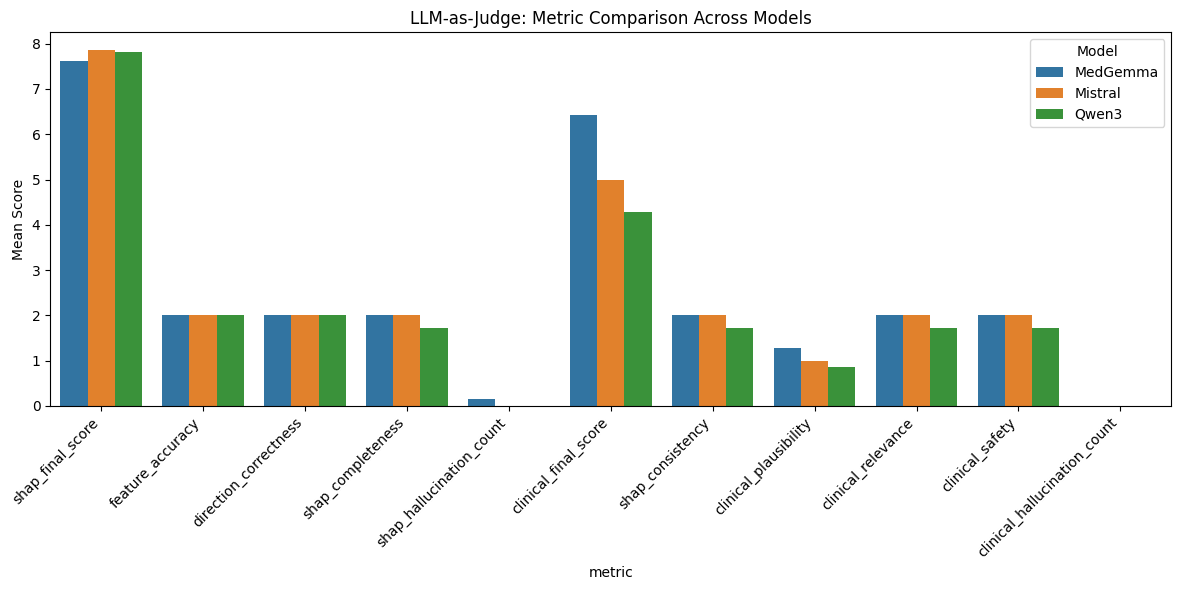

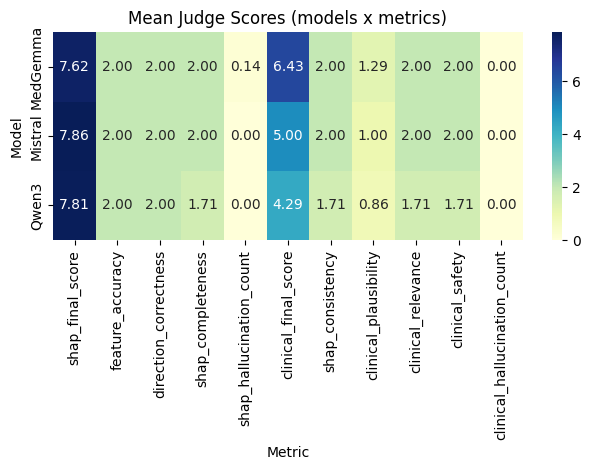

In [98]:
# Compare LLM-as-Judge results across models (MedGemma, Mistral, Qwen3)
files = {
    "MedGemma": "llm_judge_results_medgemma.csv",
    "Mistral": "llm_judge_results_mistral.csv",
    "Qwen3": "llm_judge_results_qwen3.csv"
}

metrics = ["shap_final_score", "clinical_final_score"]

rows = []
for name, path in files.items():
    try:
        df_j = pd.read_csv(path)
    except FileNotFoundError:
        print(f"File not found: {path}")
        continue
    means = df_j[metrics].mean()
    row = {"model": name}
    for m in metrics:
        row[m] = means.get(m, np.nan)
    rows.append(row)

comp = pd.DataFrame(rows)
if comp.empty:
    raise FileNotFoundError("No judge")
# Compare LLM-as-Judge results across models and plot metrics
files = {
    "MedGemma": "llm_judge_results_medgemma.csv",
    "Mistral": "llm_judge_results_mistral.csv",
    "Qwen3": "llm_judge_results_qwen3.csv"
}

# Read files and compute mean per metric
model_means = {}
for name, fname in files.items():
    try:
        dfj = pd.read_csv(fname)
        # keep only numeric columns
        numeric = dfj.select_dtypes(include=[np.number])
        model_means[name] = numeric.mean()
    except FileNotFoundError:
        print(f"File not found: {fname}")
    except Exception as e:
        print(f"Error reading {fname}: {e}")

if not model_means:
    raise RuntimeError("No judge result files loaded.")

# Build comparison DataFrame (metrics x models)
comp_df = pd.DataFrame(model_means).T  # rows = models, cols = metrics
comp_df.index.name = "model"

# Select a sensible subset/order of metrics if present
preferred_metrics = [
    "shap_final_score",
    "feature_accuracy",
    "direction_correctness",
    "shap_completeness",
    "shap_hallucination_count",

    "clinical_final_score",
    "shap_consistency",
    "clinical_plausibility",
    "clinical_relevance",
    "clinical_safety",
    "clinical_hallucination_count"
]
metrics = [m for m in preferred_metrics if m in comp_df.columns]
if not metrics:
    metrics = comp_df.columns.tolist()

# Melt for seaborn
plot_df = comp_df[metrics].reset_index().melt(id_vars="model", var_name="metric", value_name="mean_score")

# Plot grouped barplot
plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x="metric", y="mean_score", hue="model", ci=None)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Score")
plt.title("LLM-as-Judge: Metric Comparison Across Models")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# Optional: heatmap of mean scores (models x metrics)
plt.figure(figsize=(max(6, len(metrics)*0.6), 3 + 0.6*len(model_means)))
sns.heatmap(comp_df[metrics], annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Mean Judge Scores (models x metrics)")
plt.ylabel("Model")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

# Demo

Threshold Terbaik: 0.3500000000000001 

Accuracy: 0.7840909090909091
Precision: 0.6923076923076923
Recall: 0.9230769230769231
F1 Score: 0.7912087912087912
AUC-ROC: 0.7982731554160126
Mean Absolute Error: 0.2159090909090909
Root Mean Squared Error: 0.4646601886422926


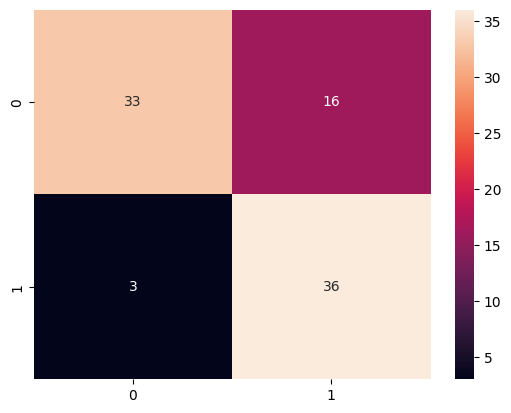

Model saved to: f1_model.pkl
Threshold saved to: best_threshold.json
Optimal Threshold: 0.3500000000000001
Best F1 Score: 0.7912087912087912


In [99]:
import joblib

y_prob = f1_model.predict_proba(X_test_slim)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)

best_f1 = 0
best_thresh = 0

for thresh in thresholds:
    y_pred_custom = (y_prob >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred_custom)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

final_prediction = (y_prob >= best_thresh).astype(int)
print(f"Threshold Terbaik: {best_thresh} \n")
evaluate_model(y_test, final_prediction)

# Save the model and optimal threshold

# Save the F1 model
model_filename = "f1_model.pkl"
joblib.dump(f1_model, model_filename)

# Save the optimal threshold
threshold_data = {
    "best_threshold": float(best_thresh),
    "best_f1_score": float(best_f1)
}

with open("best_threshold.json", "w") as f:
    json.dump(threshold_data, f)

print(f"Model saved to: {model_filename}")
print(f"Threshold saved to: best_threshold.json")
print(f"Optimal Threshold: {best_thresh}")
print(f"Best F1 Score: {best_f1}")


=== True Positive ===
Original test index : 228
Actual label        : 1
Predicted label     : 1
Probability cancer  : 0.9241

Top positive contributors:
   feature value     shap
       WBC  3600 0.720251
Hemoglobin   9.1 0.716440
  Ageyears  65.0 0.561751
   Glucose   NaN 0.448523
   Calcium   7.4 0.121973

Top negative contributors:
                         feature value      shap
                HeartRate_6hours  75.0 -0.550313
        DBP_Upon_presentation_ED    98 -0.453909
        SBP_Upon_presentation_ED   132 -0.261223
 Heart_Rate_Upon_presentation_ED    80 -0.187287
Temperature_Upon_presentation_ED  37.3 -0.155308


C:\Users\gamin\AppData\Local\Temp\ipykernel_45888\490482676.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="shap", y="feature", palette="viridis")


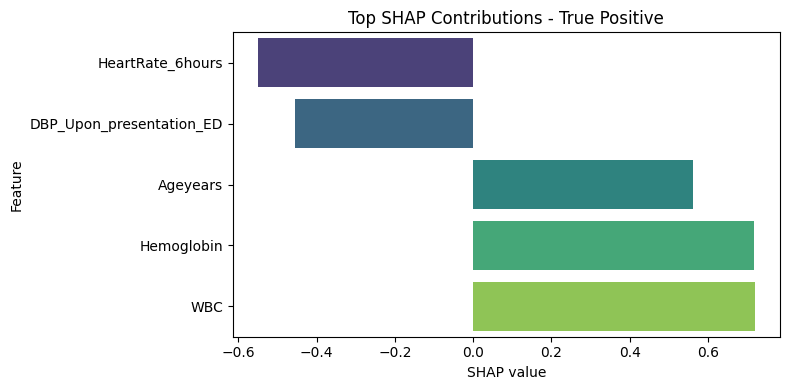


=== True Negative ===
Original test index : 55
Actual label        : 0
Predicted label     : 0
Probability cancer  : 0.1356

Top positive contributors:
                         feature value     shap
Temperature_Upon_presentation_ED  36.7 0.576619
                       Phosphate   6.6 0.101654
        SBP_Upon_presentation_ED   111 0.099170
 Heart_Rate_Upon_presentation_ED    60 0.041508
        DBP_Upon_presentation_ED    69 0.041135

Top negative contributors:
         feature  value      shap
HeartRate_6hours   74.0 -1.002081
         Glucose  116.0 -0.577871
        Ageyears   85.0 -0.460289
             WBC  13200 -0.370073
           Sex_0   True -0.290393


C:\Users\gamin\AppData\Local\Temp\ipykernel_45888\490482676.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="shap", y="feature", palette="viridis")


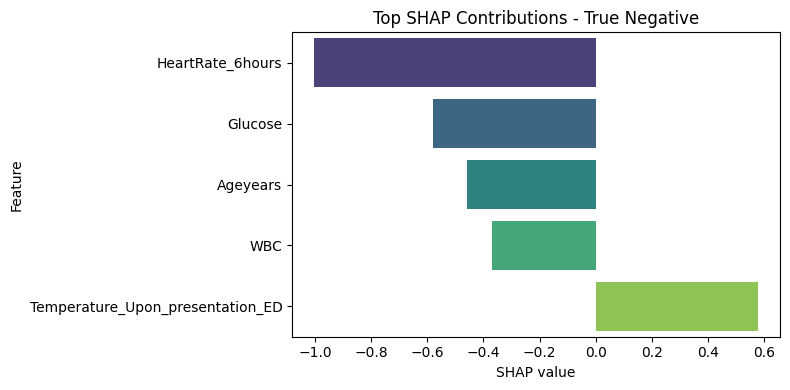


=== False Positive ===
Original test index : 116
Actual label        : 0
Predicted label     : 1
Probability cancer  : 0.7848

Top positive contributors:
                 feature value     shap
                Ageyears  65.0 0.636379
        HeartRate_6hours  86.0 0.355223
SBP_Upon_presentation_ED   102 0.267168
                 Calcium   7.4 0.208841
                   Sex_0 False 0.161158

Top negative contributors:
                                      feature  value      shap
Time_to_Antibiotic_treatment_initiation_hours    0.5 -0.542254
                                          WBC  10300 -0.403766
                                      Glucose  132.0 -0.319143
             Temperature_Upon_presentation_ED   38.0 -0.270079
              Heart_Rate_Upon_presentation_ED     81 -0.212175


C:\Users\gamin\AppData\Local\Temp\ipykernel_45888\490482676.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="shap", y="feature", palette="viridis")


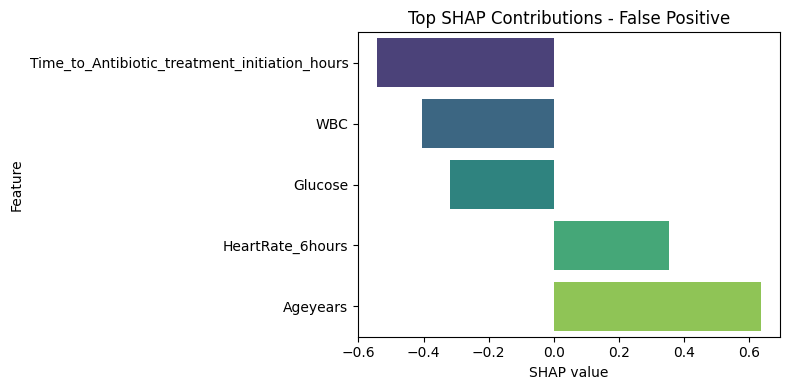


=== False Negative ===
Original test index : 137
Actual label        : 1
Predicted label     : 1
Probability cancer  : 0.3523

Top positive contributors:
                                      feature  value     shap
                                      Glucose    NaN 0.506282
                                   Hemoglobin    9.3 0.358324
Time_to_Antibiotic_treatment_initiation_hours  125.0 0.160661
                                          CAD      0 0.073789
                                           DM      0 0.068935

Top negative contributors:
                         feature value      shap
        SBP_Upon_presentation_ED   139 -0.735087
                        Ageyears  85.0 -0.604649
                             WBC 13500 -0.385571
Temperature_Upon_presentation_ED  36.9 -0.345982
 Heart_Rate_Upon_presentation_ED    60 -0.206668


C:\Users\gamin\AppData\Local\Temp\ipykernel_45888\490482676.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="shap", y="feature", palette="viridis")


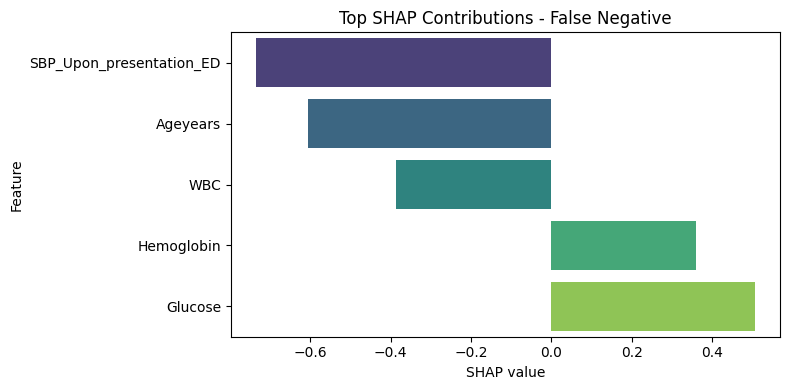

,condition,original_index,actual_label,predicted_label,probability_cancer
0,True Positive,228,1,1,0.924146
1,True Negative,55,0,0,0.135552
2,False Positive,116,0,1,0.784825
3,False Negative,137,1,1,0.352348


In [100]:
# Demo XGBoost pada test data berdasarkan kondisi TP / TN / FP / FN

condition_indices = {
    "True Positive": np.where(tp_condition.to_numpy())[0],
    "True Negative": np.where(tn_condition.to_numpy())[0],
    "False Positive": np.where(fp_condition.to_numpy())[0],
    "False Negative": np.where(fn_condition.to_numpy())[0],
}

def show_case_demo(pos_idx, condition_name, top_n=5):
    original_idx = X_test_slim.index[pos_idx]
    actual_label = int(y_test.iloc[pos_idx])
    predicted_label = int(final_prediction[pos_idx])
    prob_cancer = float(proba_prediction[pos_idx])

    row = X_test_slim.iloc[pos_idx]
    shap_row = shap_values_raw[pos_idx].values

    case_df = pd.DataFrame({
        "feature": X_test_slim.columns,
        "value": row.values,
        "shap": shap_row
    })
    case_df["abs_shap"] = case_df["shap"].abs()
    case_df = case_df.sort_values("abs_shap", ascending=False)

    print(f"\n=== {condition_name} ===")
    print(f"Original test index : {original_idx}")
    print(f"Actual label        : {actual_label}")
    print(f"Predicted label     : {predicted_label}")
    print(f"Probability cancer  : {prob_cancer:.4f}")

    print("\nTop positive contributors:")
    print(
        case_df[case_df["shap"] > 0][["feature", "value", "shap"]]
        .head(top_n)
        .to_string(index=False)
    )

    print("\nTop negative contributors:")
    print(
        case_df[case_df["shap"] < 0][["feature", "value", "shap"]]
        .head(top_n)
        .to_string(index=False)
    )

    plt.figure(figsize=(8, 4))
    plot_df = case_df.head(top_n).sort_values("shap")
    sns.barplot(data=plot_df, x="shap", y="feature", palette="viridis")
    plt.title(f"Top SHAP Contributions - {condition_name}")
    plt.xlabel("SHAP value")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    return {
        "condition": condition_name,
        "original_index": int(original_idx),
        "actual_label": actual_label,
        "predicted_label": predicted_label,
        "probability_cancer": prob_cancer
    }

demo_results = []

for condition_name, idxs in condition_indices.items():
    if len(idxs) == 0:
        print(f"\n=== {condition_name} ===")
        print("Tidak ada contoh pada kondisi ini.")
        continue

    demo_results.append(show_case_demo(idxs[0], condition_name))

demo_df = pd.DataFrame(demo_results)
demo_df